# 🧬 HealthOpt v8 — Pipeline ML Nutritionnel Complet

## Résumé du projet

**Objectif :** Prédire les carences et déséquilibres nutritionnels à partir de données biologiques et démographiques via machine learning.

**Données sources :**
- **NHANES** (USA) — cycles 1999→2023, 113 249 individus, fichiers XPT
- **KNHANES** (Corée) — cycles 2007→2016, 81 503 individus, fichiers CSV
- **Total :** 194 752 individus fusionnés

---

## Architecture du pipeline

| Étape | Cellule | Description | Résultat |
|-------|---------|-------------|----------|
| S0 | 4 | Installation + imports + répertoires | Environnement prêt |
| S1 | 6 | 11 cycles NHANES + 23 modules biologiques | Dictionnaires de config |
| S2 | 8 | Chargement NHANES XPT — merge par variable | df_nhanes : 113 249 x 115 |
| S3 | 10 | Chargement KNHANES CSV — mapping coréen | df_knhanes : 81 503 x 22 |
| S4 | 12 | Fusion NHANES + KNHANES | df : 194 752 x 118 |
| S5 | 14 | Nettoyage clinique + 9 conversions d'unités | df nettoyé : 194 752 x 118 |
| S6 | 16 | Labelling binaire : 14 primaires + 9 dérivés | 23 labels retenus |
| S7 | 18 | Feature engineering : 77 nouvelles features | df : 194 752 x 195 |
| S8 | 20 | Split Train/Val/Test temporel + SMOTE | 23 splits prêts |

---

## Labels retenus (23 total)

### Labels primaires (14)
hemoglobine, ferritine, vitD, vitB12, folate_serique, calcium,
iode_urinaire, albumine, tsh, glycemie_jejun, hba1c,
triglycerides, ldl, ratio_albumine_creatinine

### Labels dérivés (9)
vitD_severe, vitD_optimal, anemie_severe, surcharge_fer, crp_eleve,
dysglycemie_composite, surpoids_obesite, obesite, iode_exces

---

## Decisions techniques cles

- **Merge par variable S2** : maximise la couverture, chaque individu garde toutes ses mesures biologiques independamment des cycles
- **Conversions d'unites S5** : 9 variables converties via detection de seuil (NHANES et KNHANES n'utilisent pas les memes unites)
- **Anti-leakage per-label S8** : chaque modele exclut les derivees directes de sa variable cible
- **SMOTE conservateur S8** : ratio adaptatif selon prevalence, evite le probleme v6 (97% de faux positifs synthetiques)
- **Split temporel S8** : Train 1999-2016, Val 2017-2018, Test 2021-2023

---

## Instructions
1. Placer mon_projet_nutrition.zip dans Google Drive (MyDrive/)
2. Ouvrir dans Google Colab
3. Runtime > Run all
4. Apres S8 : utiliser le dictionnaire splits pour entrainer les modeles


---
## S0 — Installation et Imports

**Role :** Preparer l'environnement Colab.

- Verifie et installe les bibliotheques manquantes
- Importe tous les modules Python du pipeline
- Configure matplotlib pour les graphiques
- Cree les repertoires de sortie (models/, reports/)
- Compte les fichiers XPT et CSV disponibles pour verification


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELLULE 0-LOCAL — VÉRIFICATION ARBORESCENCE (Anaconda / Jupyter)
# Remplace le montage Google Drive / extraction ZIP
# ═══════════════════════════════════════════════════════════════════════════════
#
# Structure attendue :
#   C:\Users\912ke\Downloads\mon_projet_nutrition\
#     data\
#       nhanes_XXXX_XXXX\   (un sous-dossier par cycle, contenant les .XPT)
#       knhanes\             (fichiers CSV KNHANES)
#     models\                (créé auto)
#     reports\               (créé auto)
#
from pathlib import Path
import glob, os

BASE_DIR        = Path(r"C:\Users\912ke\Downloads\mon_projet_nutrition")
DATA_ROOT       = BASE_DIR / "data"
NHANES_DATA_DIR = DATA_ROOT
KNHANES_DIR     = DATA_ROOT / "knhanes"
MODELS_DIR      = BASE_DIR / "models"
REPORTS_DIR     = BASE_DIR / "reports"

print("\n" + "=" * 60)
print("  Vérification de l'arborescence locale")
print("=" * 60)
for label, p in [
    ("BASE_DIR       ", BASE_DIR),
    ("DATA_ROOT      ", DATA_ROOT),
    ("NHANES_DATA_DIR", NHANES_DATA_DIR),
    ("KNHANES_DIR    ", KNHANES_DIR),
    ("MODELS_DIR     ", MODELS_DIR),
    ("REPORTS_DIR    ", REPORTS_DIR),
]:
    status = "OK" if p.exists() else "MANQUANT"
    print(f"  {label} : {status}  ->  {p}")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print("\n  MODELS_DIR et REPORTS_DIR crees/verifies")

xpt_files = (glob.glob(str(NHANES_DATA_DIR / "**" / "*.XPT"), recursive=True) +
             glob.glob(str(NHANES_DATA_DIR / "**" / "*.xpt"), recursive=True))
csv_files = (glob.glob(str(KNHANES_DIR / "*.csv")) +
             glob.glob(str(KNHANES_DIR / "**" / "*.csv"), recursive=True))

print(f"\n  Fichiers XPT NHANES trouves : {len(xpt_files)}")
print(f"  Fichiers CSV KNHANES trouves : {len(csv_files)}")
if not xpt_files:
    print(f"  AVERTISSEMENT : Aucun XPT dans {NHANES_DATA_DIR}")
if not csv_files:
    print(f"  AVERTISSEMENT : Aucun CSV dans {KNHANES_DIR}")



  Vérification de l'arborescence locale
  BASE_DIR        : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition
  DATA_ROOT       : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition\data
  NHANES_DATA_DIR : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition\data
  KNHANES_DIR     : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition\data\knhanes
  MODELS_DIR      : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition\models
  REPORTS_DIR     : OK  ->  C:\Users\912ke\Downloads\mon_projet_nutrition\reports

  MODELS_DIR et REPORTS_DIR crees/verifies

  Fichiers XPT NHANES trouves : 500
  Fichiers CSV KNHANES trouves : 20


In [2]:
# Vérification détaillée de l'arborescence locale
import os
from pathlib import Path

BASE_DIR = Path(r"C:\Users\912ke\Downloads\mon_projet_nutrition")

print("Contenu de BASE_DIR :")
print(sorted(os.listdir(str(BASE_DIR))) if BASE_DIR.exists() else "MANQUANT")

data_path = BASE_DIR / "data"
print("\nContenu data/ :")
print(sorted(os.listdir(str(data_path))) if data_path.exists() else "MANQUANT")

knhanes_path = data_path / "knhanes"
print("\nContenu data/knhanes/ :")
if knhanes_path.exists():
    entries = sorted(os.listdir(str(knhanes_path)))
    print(f"  {len(entries)} fichiers : {entries[:15]}{'...' if len(entries) > 15 else ''}")
else:
    print("  MANQUANT")

print("\nSous-dossiers NHANES dans data/ :")
if data_path.exists():
    subdirs = [d for d in os.listdir(str(data_path))
               if (data_path / d).is_dir() and d != "knhanes"]
    print(f"  {len(subdirs)} dossiers : {subdirs}")


Contenu de BASE_DIR :
['data', 'models', 'reports']

Contenu data/ :
['knhanes', 'nhanes_1999_2000', 'nhanes_2001_2002', 'nhanes_2003_2004', 'nhanes_2005_2006', 'nhanes_2007_2008', 'nhanes_2009_2010', 'nhanes_2011_2012', 'nhanes_2013_2014', 'nhanes_2015_2016', 'nhanes_2017_2018', 'nhanes_2017_2020', 'nhanes_2021_2023']

Contenu data/knhanes/ :
  10 fichiers : ['HN07_ALL.csv', 'HN08_ALL.csv', 'HN09_ALL.csv', 'HN10_ALL.csv', 'HN11_ALL.csv', 'HN12_ALL.csv', 'HN14_ALL.csv', 'HN15_ALL.csv', 'HN16_ALL.csv', 'hn13_all.csv']

Sous-dossiers NHANES dans data/ :
  12 dossiers : ['nhanes_1999_2000', 'nhanes_2001_2002', 'nhanes_2003_2004', 'nhanes_2005_2006', 'nhanes_2007_2008', 'nhanes_2009_2010', 'nhanes_2011_2012', 'nhanes_2013_2014', 'nhanes_2015_2016', 'nhanes_2017_2018', 'nhanes_2017_2020', 'nhanes_2021_2023']


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# S0 — INSTALLATION & IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys

_REQUIRED = [
    "pyreadstat", "lightgbm", "scikit-learn", "imbalanced-learn",
    "shap", "tqdm", "qrcode[pil]", "opencv-python-headless", "Pillow",
]

def _install(pkg: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("📦 Vérification des dépendances...")
for _pkg in _REQUIRED:
    _mod = _pkg.split("[")[0].replace("-", "_")
    try:
        __import__(_mod)
        print(f"  ✅ {_pkg}")
    except ImportError:
        print(f"  ⬇️  Installation : {_pkg}")
        _install(_pkg)
        print(f"  ✅ {_pkg}")

import os, glob, warnings, json, datetime, zipfile, hashlib
from collections import Counter, defaultdict
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pyreadstat
from tqdm import tqdm

from sklearn.model_selection      import train_test_split, StratifiedKFold
from sklearn.preprocessing        import StandardScaler
from sklearn.impute               import SimpleImputer
from sklearn.pipeline             import Pipeline
from sklearn.ensemble             import RandomForestClassifier, VotingClassifier
from sklearn.calibration          import CalibratedClassifierCV
from sklearn.metrics              import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling       import SMOTE
import lightgbm as lgb
import shap
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
np.random.seed(42)

# ── FIX BUG 1 : %matplotlib inline est une magic Jupyter, invalide en Python pur
# Remplacement par l'API IPython compatible avec ast.parse et Colab
try:
    import IPython
    _ipy = IPython.get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams.update({
    "figure.dpi":         120,
    "figure.figsize":     (14, 6),
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     13,
    "axes.labelsize":     11,
})

# ── Répertoires ────────────────────────────────────────────────────────────────
# Repertoires locaux (Anaconda / Jupyter)
BASE_DIR        = Path(r"C:\\Users\\912ke\\Downloads\\mon_projet_nutrition")
DATA_ROOT       = BASE_DIR / "data"
NHANES_DATA_DIR = DATA_ROOT
KNHANES_DIR     = DATA_ROOT / "knhanes"
MODELS_DIR      = BASE_DIR / "models"
REPORTS_DIR     = BASE_DIR / "reports"

for _dir in [MODELS_DIR, REPORTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

xpt_files = (glob.glob(str(NHANES_DATA_DIR / "**" / "*.XPT"), recursive=True) +
             glob.glob(str(NHANES_DATA_DIR / "**" / "*.xpt"), recursive=True))
csv_files = (glob.glob(str(KNHANES_DIR / "*.csv")) +
             glob.glob(str(KNHANES_DIR / "**" / "*.csv"), recursive=True))

print(f"\n  📂 NHANES_DATA_DIR : {NHANES_DATA_DIR}")
print(f"  📂 KNHANES_DIR     : {KNHANES_DIR}")
print(f"  📄 Fichiers XPT trouvés : {len(xpt_files)}")
print(f"  📄 Fichiers CSV KNHANES : {len(csv_files)}")

if len(xpt_files) == 0:
    print("\n  ⚠️  Aucun XPT trouvé")
if len(csv_files) == 0:
    print(f"\n  ⚠️  Aucun CSV KNHANES trouvé dans : {KNHANES_DIR}")

print("\n✅ S0 terminé — environnement prêt")
print(f"   numpy  : {np.__version__}")
print(f"   pandas : {pd.__version__}")


📦 Vérification des dépendances...
  ✅ pyreadstat
  ✅ lightgbm
  ⬇️  Installation : scikit-learn
  ✅ scikit-learn
  ⬇️  Installation : imbalanced-learn
  ✅ imbalanced-learn
  ✅ shap
  ✅ tqdm
  ✅ qrcode[pil]
  ⬇️  Installation : opencv-python-headless
  ✅ opencv-python-headless
  ⬇️  Installation : Pillow
  ✅ Pillow

  📂 NHANES_DATA_DIR : C:\Users\912ke\Downloads\mon_projet_nutrition\data
  📂 KNHANES_DIR     : C:\Users\912ke\Downloads\mon_projet_nutrition\data\knhanes
  📄 Fichiers XPT trouvés : 500
  📄 Fichiers CSV KNHANES : 20

✅ S0 terminé — environnement prêt
   numpy  : 2.1.3
   pandas : 2.2.3


---
## S1 — Configuration NHANES

**Role :** Definir les metadonnees statiques du pipeline.

**CYCLES** : 11 cycles biennaux (1999-2023). Chaque cycle a un suffixe de fichier XPT et un groupe temporel (ancien/moyen/recent/val/test) pour le split S8.

**NHANES_MODULES** : 23 modules biologiques. Chaque module definit :
- `aliases` : noms alternatifs du fichier selon les cycles (NHANES change les noms entre cycles)
- `cols` : colonnes NHANES a extraire par leur code brut (ex: LBXHGB pour hemoglobine)
- `rename` : mapping vers les noms standardises du pipeline (LBXHGB -> hemoglobine)


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# S1 — CONFIGURATION NHANES
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  📁 S1 — Configuration NHANES")
print("=" * 70)

# ── Cycles NHANES (1999 → 2023) ───────────────────────────────────────────────
# Format : {"periode" : ("suffixe_xpt", "groupe_temporel")}
# Groupes : ancien (1999-2010) | moyen (2005-2014) | recent (2011-2018) | val/test
CYCLES: Dict[str, Tuple[str, str]] = {
    "1999_2000": ("A", "ancien"),
    "2001_2002": ("B", "ancien"),
    "2003_2004": ("C", "ancien"),
    "2005_2006": ("D", "moyen"),
    "2007_2008": ("E", "moyen"),
    "2009_2010": ("F", "moyen"),
    "2011_2012": ("G", "recent"),
    "2013_2014": ("H", "recent"),
    "2015_2016": ("I", "recent"),
    "2017_2018": ("J", "val"),
    "2021_2023": ("L", "test"),
}

# ── Modules NHANES — cartographie complète ────────────────────────────────────
# Chaque module spécifie :
#   aliases : variantes de nommage selon les cycles
#   cols    : colonnes à extraire (SEQN inclus)
#   rename  : mapping vers noms standardisés
#
# NOTE : DR1IFF exclu (fichier 'long' : N aliments × individu → millions de lignes)
#        DR1TOT / DR2TOT inclus (format 'wide' : 1 ligne / individu)

NHANES_MODULES: Dict[str, Dict] = {

    # ── Démographie ──────────────────────────────────────────────────────────
    "DEMO": {
        "aliases": ["DEMO"],
        "cols":    ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDEXPRG", "RIDRETH3",
                    "INDFMPIR", "WTMEC2YR", "WTINT2YR", "DMDEDUC2",
                    "DMDHHSIZ", "INDHHIN2"],
        "rename":  {
            "RIDAGEYR":  "age",           "RIAGENDR": "sexe_nhanes",
            "RIDEXPRG":  "grossesse",     "RIDRETH3": "ethnicite",
            "INDFMPIR":  "ratio_pauvrete","WTMEC2YR": "poids_stat",
            "WTINT2YR":  "poids_interview","DMDEDUC2": "education",
            "DMDHHSIZ":  "taille_menage", "INDHHIN2": "revenu_menage"
        }
    },

    # ── Anthropométrie ───────────────────────────────────────────────────────
    "BMX": {
        "aliases": ["BMX"],
        "cols":    ["SEQN", "BMXBMI", "BMXWT", "BMXHT", "BMXWAIST"],
        "rename":  {
            "BMXBMI":   "imc",       "BMXWT":    "poids_kg",
            "BMXHT":    "taille_cm", "BMXWAIST": "tour_taille"
        }
    },

    # ── NFS — Numération Formule Sanguine ────────────────────────────────────
    "CBC": {
        "aliases": ["CBC", "L25", "LAB25"],
        "cols":    ["SEQN", "LBXHGB", "LBXHCT", "LBXMCVSI", "LBXMCHSI",
                    "LBXMC", "LBXRDW", "LBXWBCSI", "LBXRBCSI",
                    "LBXPLTSI", "LBXMPSI"],
        "rename":  {
            "LBXHGB":   "hemoglobine",  "LBXHCT":   "hematocrite",
            "LBXMCVSI": "mcv",          "LBXMCHSI": "mch",
            "LBXMC":    "mchc",         "LBXRDW":   "rdw",
            "LBXWBCSI": "leucocytes",   "LBXRBCSI": "erythrocytes",
            "LBXPLTSI": "plaquettes",   "LBXMPSI":  "mpv"
        }
    },

    # ── Fer & Ferritine ──────────────────────────────────────────────────────
    "FERTIN": {
        "aliases": ["FERTIN", "L06FE", "LAB06FE", "FETIB"],
        "cols":    ["SEQN", "LBDFERSI", "LBXFER", "LBDFER", "LBXFERSI",
                    "LBDPCT", "LBXPCT", "LBDTIB", "LBXTIB",
                    "LBDIROSI", "LBXIRO", "LBDIRO"],
        "rename":  {
            "LBDFERSI":  "ferritine",       "LBXFER":  "ferritine",
            "LBDFER":    "ferritine",        "LBXFERSI":"ferritine",
            "LBDPCT":    "sat_transferrine", "LBXPCT": "sat_transferrine",
            "LBDTIB":    "tibc",             "LBXTIB":  "tibc",
            "LBDIROSI":  "fer_serique",      "LBXIRO":  "fer_serique",
            "LBDIRO":    "fer_serique"
        }
    },

    # ── Vitamine D ───────────────────────────────────────────────────────────
    "VID": {
        "aliases": ["VID", "L06VID", "LAB06VID", "VIDUS"],
        "cols":    ["SEQN", "LBXVIDMS", "LBXVID", "LBDVID", "LBXVD25", "LBDVD25"],
        "rename":  {
            "LBXVIDMS": "vitD", "LBXVID": "vitD", "LBDVID": "vitD",
            "LBXVD25":  "vitD", "LBDVD25":"vitD"
        }
    },

    # ── Folate sérique ───────────────────────────────────────────────────────
    "FOLATE": {
        "aliases": ["FOLATE", "L06FOL", "LAB06FOL"],
        "cols":    ["SEQN", "LBDFOLSI", "LBXFOLSI", "LBXFOL", "LBXFOLN"],
        "rename":  {
            "LBDFOLSI": "folate_serique", "LBXFOLSI": "folate_serique",
            "LBXFOL":   "folate_serique", "LBXFOLN":  "folate_serique"
        }
    },

    # ── Folate érythrocytaire ────────────────────────────────────────────────
    "FOLFMS": {
        "aliases": ["FOLFMS", "FOLFM"],
        "cols":    ["SEQN", "LBDRFOSI", "LBXRFO", "LBDRFO", "LBXBFOL"],
        "rename":  {
            "LBDRFOSI": "folate_eryth", "LBXRFO": "folate_eryth",
            "LBDRFO":   "folate_eryth", "LBXBFOL":"folate_eryth"
        }
    },

    # ── Vitamine B12 (+ folates dans les anciens cycles) ─────────────────────
    "VITB12": {
        "aliases": ["VITB12", "L06B12", "LAB06B12", "B12FOL", "LAB06"],
        "cols":    ["SEQN", "LBDB12", "LBXB12", "LBDVB12",
                    "LBDFOLSI", "LBXFOLSI", "LBXFOL",
                    "LBDRFOSI", "LBXRFO",   "LBDRFO"],
        "rename":  {
            "LBDB12":   "vitB12",           "LBXB12":  "vitB12",
            "LBDVB12":  "vitB12",
            "LBDFOLSI": "folate_serique",   "LBXFOLSI":"folate_serique",
            "LBXFOL":   "folate_serique",
            "LBDRFOSI": "folate_eryth",     "LBXRFO":  "folate_eryth",
            "LBDRFO":   "folate_eryth"
        }
    },

    # ── Biochimie complète ───────────────────────────────────────────────────
    "BIOPRO": {
        "aliases": ["BIOPRO", "L40", "LAB40"],
        "cols":    ["SEQN",
                    "LBXSCAISI","LBDSCA","LBXSCA",
                    "LBXSMAGSI","LBDSMG","LBXSMG",
                    "LBXSATSI","LBDSAT","LBXSAT",
                    "LBXSASSI","LBDSAS","LBXSAS",
                    "LBXSCR","LBDSCR","LBXSTP","LBDSTP",
                    "LBXSAL","LBDSAL","LBXSCH","LBDSCH",
                    "LBXSTR","LBDSTR","LBXSGL","LBDSGLU","LBDSGL",
                    "LBXSBU","LBDSBU","LBXSPH","LBDSPHS",
                    "LBXSUA","LBDSUA","LBXSGB","LBDSGB",
                    "LBXSNASI","LBDSNASI","LBXSKSI","LBDSKSI"],
        "rename":  {
            "LBXSCAISI": "calcium",      "LBDSCA":"calcium",    "LBXSCA":"calcium",
            "LBXSMAGSI": "magnesium",    "LBDSMG":"magnesium",  "LBXSMG":"magnesium",
            "LBXSATSI":  "alt",          "LBDSAT":"alt",        "LBXSAT":"alt",
            "LBXSASSI":  "ast",          "LBDSAS":"ast",        "LBXSAS":"ast",
            "LBXSCR":    "creatinine",   "LBDSCR":"creatinine",
            "LBXSTP":    "proteines_tot","LBDSTP":"proteines_tot",
            "LBXSAL":    "albumine",     "LBDSAL":"albumine",
            "LBXSCH":    "cholesterol",  "LBDSCH":"cholesterol",
            "LBXSTR":    "triglycerides","LBDSTR":"triglycerides",
            "LBXSGL":    "glycemie",     "LBDSGLU":"glycemie",  "LBDSGL":"glycemie",
            "LBXSBU":    "uree",         "LBDSBU":"uree",
            "LBXSPH":    "phosphore",    "LBDSPHS":"phosphore",
            "LBXSUA":    "acide_urique", "LBDSUA":"acide_urique",
            "LBXSGB":    "gamma_gt",     "LBDSGB":"gamma_gt",
            "LBXSNASI":  "sodium",       "LBDSNASI":"sodium",
            "LBXSKSI":   "potassium",    "LBDSKSI":"potassium"
        }
    },

    # ── Albumine & créatinine urinaires (microalbuminurie) ────────────────────
    "ALB_CR": {
        "aliases": ["ALB_CR", "ALBCR", "L16", "LAB16"],
        "cols":    ["SEQN", "URXUMA", "URDUMALC", "URDACT", "URXUCR", "URDCRLC"],
        "rename":  {
            "URXUMA":   "albumine_urinaire",           "URDUMALC": "albumine_urinaire",
            "URDACT":   "ratio_albumine_creatinine",
            "URXUCR":   "creatinine_urinaire",         "URDCRLC":  "creatinine_urinaire"
        }
    },

    # ── CRP (inflammation) ────────────────────────────────────────────────────
    "HSCRP": {
        "aliases": ["HSCRP", "CRP", "L11", "LAB11"],
        "cols":    ["SEQN", "LBXHSCRP", "LBXCRP", "LBDCRP"],
        "rename":  {"LBXHSCRP": "crp", "LBXCRP": "crp", "LBDCRP": "crp"}
    },

    # ── HDL ───────────────────────────────────────────────────────────────────
    "HDL": {
        "aliases": ["HDL", "L13", "LAB13"],
        "cols":    ["SEQN", "LBDHDD", "LBXHDD", "LBDHDL", "LBXHDL"],
        "rename":  {"LBDHDD": "hdl", "LBXHDD": "hdl", "LBDHDL": "hdl", "LBXHDL": "hdl"}
    },

    # ── Triglycérides + LDL ───────────────────────────────────────────────────
    "TRIGLY": {
        "aliases": ["TRIGLY", "TRIG", "L13AM", "LAB13AM"],
        "cols":    ["SEQN", "LBXTR", "LBDTRSI", "LBXTG", "LBDLDL", "LBDLDLSI"],
        "rename":  {
            "LBXTR":    "triglycerides", "LBDTRSI": "triglycerides", "LBXTG": "triglycerides",
            "LBDLDL":   "ldl",           "LBDLDLSI":"ldl"
        }
    },

    # ── Cholestérol total ─────────────────────────────────────────────────────
    "TCHOL": {
        "aliases": ["TCHOL", "L13AM", "LAB13AM"],
        "cols":    ["SEQN", "LBXTC", "LBDTCSI"],
        "rename":  {"LBXTC": "cholesterol", "LBDTCSI": "cholesterol"}
    },

    # ── Glycémie à jeun ───────────────────────────────────────────────────────
    "GLU": {
        "aliases": ["GLU", "L10AM", "LAB10AM"],
        "cols":    ["SEQN", "LBXGLU", "LBDGLUSI"],
        "rename":  {"LBXGLU": "glycemie_jejun", "LBDGLUSI": "glycemie_jejun"}
    },

    # ── HbA1c ─────────────────────────────────────────────────────────────────
    "GHB": {
        "aliases": ["GHB", "L10", "LAB10"],
        "cols":    ["SEQN", "LBXGH"],
        "rename":  {"LBXGH": "hba1c"}
    },

    # ── Cuivre, Zinc, Sélénium ────────────────────────────────────────────────
    "CUSEZN": {
        "aliases": ["CUSEZN", "L06CUSEZN", "LAB06CUSEZN", "CUSSE"],
        "cols":    ["SEQN",
                    "LBXCUSI","LBDCUSI","LBXCU",
                    "LBXZNSI","LBDZNSI","LBXZN",
                    "LBXSESI","LBDSESI","LBXSE"],
        "rename":  {
            "LBXCUSI": "cuivre",   "LBDCUSI": "cuivre",  "LBXCU": "cuivre",
            "LBXZNSI": "zinc",     "LBDZNSI": "zinc",    "LBXZN": "zinc",
            "LBXSESI": "selenium", "LBDSESI": "selenium","LBXSE": "selenium"
        }
    },

    # ── Thyroïde ──────────────────────────────────────────────────────────────
    "THYROD": {
        "aliases": ["THYROD", "L40T", "LAB40T", "TSH"],
        "cols":    ["SEQN", "LBXTSH", "LBXT4F", "LBXTSH1",
                    "LBXT3F", "LBXTT4", "LBXTT3"],
        "rename":  {
            "LBXTSH":  "tsh",      "LBXT4F":  "t4_libre", "LBXTSH1": "tsh",
            "LBXT3F":  "t3_libre", "LBXTT4":  "t4_total", "LBXTT3":  "t3_total"
        }
    },

    # ── Iode urinaire ─────────────────────────────────────────────────────────
    "UIOD": {
        "aliases": ["UIOD", "UIODT", "IODINE"],
        "cols":    ["SEQN", "URXUIO", "URDUIO"],
        "rename":  {"URXUIO": "iode_urinaire", "URDUIO": "iode_urinaire"}
    },

    # ── Insuline ──────────────────────────────────────────────────────────────
    "INS": {
        "aliases": ["INS", "LAB10AM", "INQ"],
        "cols":    ["SEQN", "LBXIN", "LBDINSI"],
        "rename":  {"LBXIN": "insuline", "LBDINSI": "insuline"}
    },

    # ── Métaux lourds (plomb, cadmium) ────────────────────────────────────────
    "PBCD": {
        "aliases": ["PBCD", "L06HM", "LAB06HM"],
        "cols":    ["SEQN", "LBXBPB", "LBDBPBSI", "LBXBCD", "LBDBCDSI"],
        "rename":  {
            "LBXBPB":   "plomb",   "LBDBPBSI": "plomb",
            "LBXBCD":   "cadmium", "LBDBCDSI": "cadmium"
        }
    },

    # ── Rappel alimentaire Jour 1 (wide : 1 ligne/individu) ───────────────────
    "DR1TOT": {
        "aliases": ["DR1TOT", "DRXTOT"],
        "cols":    ["SEQN",
                    "DR1TKCAL","DR1TPROT","DR1TTFAT","DR1TCARB",
                    "DR1TSUGR","DR1TFIBE","DR1TCALC","DR1TMAGN",
                    "DR1TIRON","DR1TZINC","DR1TSELE",
                    "DR1TB12","DR1TFOLB","DR1TFDFE","DR1TVD","DR1TVC"],
        "rename":  {
            "DR1TKCAL": "alim_calories_j1",   "DR1TPROT": "alim_proteines_j1",
            "DR1TTFAT": "alim_lipides_j1",    "DR1TCARB": "alim_glucides_j1",
            "DR1TSUGR": "alim_sucres_j1",     "DR1TFIBE": "alim_fibres_j1",
            "DR1TCALC": "alim_calcium_j1",    "DR1TMAGN": "alim_magnesium_j1",
            "DR1TIRON": "alim_fer_j1",        "DR1TZINC": "alim_zinc_j1",
            "DR1TSELE": "alim_selenium_j1",   "DR1TB12":  "alim_vitB12_j1",
            "DR1TFOLB": "alim_folate_j1",     "DR1TFDFE": "alim_folate_equ_j1",
            "DR1TVD":   "alim_vitD_j1",       "DR1TVC":   "alim_vitC_j1"
        }
    },

    # ── Rappel alimentaire Jour 2 ─────────────────────────────────────────────
    "DR2TOT": {
        "aliases": ["DR2TOT"],
        "cols":    ["SEQN",
                    "DR2TKCAL","DR2TPROT","DR2TTFAT","DR2TCARB",
                    "DR2TSUGR","DR2TFIBE","DR2TCALC","DR2TMAGN",
                    "DR2TIRON","DR2TZINC","DR2TSELE",
                    "DR2TB12","DR2TFOLB","DR2TFDFE","DR2TVD","DR2TVC"],
        "rename":  {
            "DR2TKCAL": "alim_calories_j2",   "DR2TPROT": "alim_proteines_j2",
            "DR2TTFAT": "alim_lipides_j2",    "DR2TCARB": "alim_glucides_j2",
            "DR2TSUGR": "alim_sucres_j2",     "DR2TFIBE": "alim_fibres_j2",
            "DR2TCALC": "alim_calcium_j2",    "DR2TMAGN": "alim_magnesium_j2",
            "DR2TIRON": "alim_fer_j2",        "DR2TZINC": "alim_zinc_j2",
            "DR2TSELE": "alim_selenium_j2",   "DR2TB12":  "alim_vitB12_j2",
            "DR2TFOLB": "alim_folate_j2",     "DR2TFDFE": "alim_folate_equ_j2",
            "DR2TVD":   "alim_vitD_j2",       "DR2TVC":   "alim_vitC_j2"
        }
    },
}

print(f"  ✅ {len(CYCLES)} cycles NHANES configurés (1999 → 2023)")
print(f"  ✅ {len(NHANES_MODULES)} modules biologiques configurés")
print("  ⚠️  DR1IFF exclu (fichier long) — DR1TOT/DR2TOT inclus (wide) ✓")
print("\n  Modules :", list(NHANES_MODULES.keys()))



  📁 S1 — Configuration NHANES
  ✅ 11 cycles NHANES configurés (1999 → 2023)
  ✅ 23 modules biologiques configurés
  ⚠️  DR1IFF exclu (fichier long) — DR1TOT/DR2TOT inclus (wide) ✓

  Modules : ['DEMO', 'BMX', 'CBC', 'FERTIN', 'VID', 'FOLATE', 'FOLFMS', 'VITB12', 'BIOPRO', 'ALB_CR', 'HSCRP', 'HDL', 'TRIGLY', 'TCHOL', 'GLU', 'GHB', 'CUSEZN', 'THYROD', 'UIOD', 'INS', 'PBCD', 'DR1TOT', 'DR2TOT']


---
## S2 — Chargement NHANES XPT

**Role :** Lire les 250 fichiers XPT et les assembler en 113 249 individus.

**Strategie merge par variable (non par cycle) :** Chaque module est pool sur tous les cycles puis joint horizontalement sur SEQN. Un individu du cycle 2001 garde sa ferritine meme si sa vitamine D vient d'un autre cycle. Maximise la couverture.

**Fonctions :**
- `_find_xpt()` : localise un XPT en testant toutes les variantes de nommage par cycle
- `_load_xpt_safe()` : charge avec fallback encodage, rejette les fichiers longs (>2.5xN_demo), deduplique SEQN
- `_display_file_format()` : rapport shape + colonnes + apercu + % valeurs manquantes
- `charger_nhanes_par_variable()` : orchestre tout — DEMO en priorite puis merge horizontal de chaque module

**Resultat :** df_nhanes — 113 249 x 115


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# S2 — CHARGEMENT NHANES XPT
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  📂 S2 — Chargement NHANES XPT")
print("=" * 70)


def _find_xpt(module_name: str, aliases: List[str], cycle_suffix: str) -> Optional[str]:
    """
    Recherche robuste d'un fichier XPT.
    Gère les variantes de nommage par cycle : MODULE_A.XPT, MODULEA.XPT, MODULE.XPT
    """
    all_names = [module_name] + aliases
    for name in all_names:
        for variant in [f"{name}_{cycle_suffix}", f"{name}{cycle_suffix}", name]:
            for ext in [".XPT", ".xpt"]:
                hits = glob.glob(
                    str(NHANES_DATA_DIR / "**" / f"{variant}{ext}"),
                    recursive=True
                )
                if hits:
                    return hits[0]
    return None


def _load_xpt_safe(
    path: str,
    cols_needed: List[str],
    rename_map: Dict[str, str],
    module_name: str,
    n_demo: int = 0
) -> Optional[pd.DataFrame]:
    """
    Charge un XPT NHANES de manière sécurisée :
      • Essai de plusieurs encodages (None / latin1 / cp1252 / utf-8)
      • Sélection des colonnes disponibles uniquement
      • Rejet si N lignes > 2.5 × N_demo (fichier 'long' détecté)
      • Déduplication SEQN avant merge
    """
    df_raw = None
    last_err = None
    for enc in [None, "latin1", "cp1252", "utf-8"]:
        try:
            kwargs = {} if enc is None else {"encoding": enc}
            df_raw, _ = pyreadstat.read_xport(path, **kwargs)
            break
        except Exception as e:
            last_err = e

    if df_raw is None:
        print(f"    ⚠️  Lecture échouée ({os.path.basename(path)}) : {last_err}")
        return None

    # Rejet fichier 'long'
    if n_demo > 0 and len(df_raw) > 2.5 * n_demo:
        print(f"    ⚠️  REJET {os.path.basename(path)} : "
              f"{len(df_raw):,} lignes > 2.5×{n_demo:,} → fichier long")
        return None

    # Sélection colonnes
    avail = [c for c in cols_needed if c in df_raw.columns]
    if "SEQN" not in avail:
        return None
    df_raw = df_raw[avail].copy()

    # Renommage (premier hit par colonne cible)
    applied_rename: Dict[str, str] = {}
    targets_done: set = set()
    for src, tgt in rename_map.items():
        if src in df_raw.columns and tgt not in targets_done:
            applied_rename[src] = tgt
            targets_done.add(tgt)
    df_raw.rename(columns=applied_rename, inplace=True)

    # Déduplication SEQN
    n_before = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset=["SEQN"], keep="first")
    n_dup = n_before - len(df_raw)
    if n_dup:
        print(f"    ↳ {n_dup} doublons SEQN supprimés dans {module_name}")

    return df_raw


def _display_file_format(df: pd.DataFrame, label: str, max_cols: int = 12) -> None:
    """
    Affiche le format d'un fichier chargé :
      • Shape (lignes × colonnes)
      • Liste des colonnes
      • 3 premières lignes
      • % valeurs manquantes avec barre visuelle
    """
    cols_show = list(df.columns[:max_cols])
    print(f"\n  ┌─ FORMAT : {label} ─────────────────────────────────")
    print(f"  │  Shape    : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"  │  Colonnes : {list(df.columns)}")
    print(f"  │")
    print(f"  │  ── Premières lignes (max {max_cols} colonnes) :")
    try:
        display_str = df[cols_show].head(3).to_string(index=False, max_cols=max_cols)
        for line in display_str.split("\n"):
            print(f"  │    {line}")
    except Exception:
        print(df.head(3))
    print(f"  │")
    print(f"  │  ── Valeurs manquantes (colonnes affichées) :")
    miss = (df[cols_show].isna().mean() * 100).round(1)
    for col, pct in miss.items():
        bar = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"  │    {col:<30} {bar} {pct:5.1f}%")
    print(f"  └─────────────────────────────────────────────────────\n")


def mount_and_extract(
    use_drive: bool = False,
    zip_name: str = "mon_projet_nutrition.zip"
) -> bool:
    """
    Stub local (remplace la version Google Colab).
    Les données sont déjà présentes sur disque — aucune extraction nécessaire.
    Retourne True si des fichiers XPT sont trouvés dans NHANES_DATA_DIR.
    """
    import glob
    xpt_count = (
        len(glob.glob(str(NHANES_DATA_DIR / "**" / "*.XPT"), recursive=True)) +
        len(glob.glob(str(NHANES_DATA_DIR / "**" / "*.xpt"), recursive=True))
    )
    sav_count = len(glob.glob(str(NHANES_DATA_DIR / "**" / "*.sav"), recursive=True))
    n_files = xpt_count + sav_count
    if n_files > 0:
        print(f"  Données locales trouvées : {xpt_count} XPT, {sav_count} SAV dans {NHANES_DATA_DIR}")
        return True
    else:
        print(f"  AVERTISSEMENT : Aucun fichier XPT/SAV dans {NHANES_DATA_DIR}")
        return False

def charger_nhanes_par_variable() -> pd.DataFrame:
    """
    Stratégie de merge NHANES PAR VARIABLE (non par cycle).
    ─────────────────────────────────────────────────────────
    Logique :
      1. Pour chaque module, charger TOUS les cycles disponibles
      2. Concaténer verticalement (→ pool complet du module)
      3. Dédupliquer sur SEQN (keep=last → cycle le plus récent)
      4. Merger les modules sur SEQN (left join chaîné)

    Avantage : un individu du cycle 2001 peut apporter sa ferritine
    même si sa VitD n'a été mesurée que dans un autre cycle.
    Maximise la couverture longitudinale par rapport au merge par cycle.
    """
    print("\n  🔄 Stratégie : merge NHANES par VARIABLE (horizontal sur SEQN)")

    xpt_all = (
        glob.glob(str(NHANES_DATA_DIR / "**" / "*.XPT"), recursive=True) +
        glob.glob(str(NHANES_DATA_DIR / "**" / "*.xpt"), recursive=True)
    )
    print(f"  📄 {len(xpt_all)} fichiers XPT détectés")

    # ── Étape A : DEMO en priorité (N_demo = référence pour rejet long) ──────
    demo_frames: List[pd.DataFrame] = []
    for cycle_name, (suffix, groupe) in CYCLES.items():
        path = _find_xpt("DEMO", NHANES_MODULES["DEMO"]["aliases"], suffix)
        if path is None:
            continue
        df_d = _load_xpt_safe(
            path,
            NHANES_MODULES["DEMO"]["cols"],
            NHANES_MODULES["DEMO"]["rename"],
            "DEMO"
        )
        if df_d is None or len(df_d) == 0:
            continue
        df_d["cycle"]        = cycle_name
        df_d["groupe_cycle"] = groupe
        df_d["source"]       = "NHANES"
        # Standardisation sexe : 1=Homme→0 | 2=Femme→1
        if "sexe_nhanes" in df_d.columns:
            df_d["sexe"] = df_d["sexe_nhanes"].map({1: 0, 2: 1})
            df_d.drop(columns=["sexe_nhanes"], inplace=True, errors="ignore")
        demo_frames.append(df_d)

    if not demo_frames:
        print("  ⚠️  Aucun fichier DEMO trouvé — retour DataFrame vide")
        return pd.DataFrame()

    df_demo = pd.concat(demo_frames, ignore_index=True, sort=False)
    df_demo = df_demo.drop_duplicates(subset=["SEQN"], keep="last")
    n_demo  = len(df_demo)
    print(f"  ✅ DEMO : {n_demo:,} individus uniques | {df_demo['cycle'].nunique()} cycles")
    _display_file_format(df_demo, "DEMO — base démographique")

    # ── Étape B : charger chaque module → merge horizontal sur SEQN ──────────
    df_nhanes = df_demo.copy()

    for module_name, cfg in NHANES_MODULES.items():
        if module_name == "DEMO":
            continue

        module_frames: List[pd.DataFrame] = []
        for cycle_name, (suffix, groupe) in CYCLES.items():
            path = _find_xpt(module_name, cfg["aliases"], suffix)
            if path is None:
                continue
            df_m = _load_xpt_safe(
                path, cfg["cols"], cfg["rename"],
                module_name, n_demo=n_demo
            )
            if df_m is None or len(df_m) == 0:
                continue
            module_frames.append(df_m)

        if not module_frames:
            print(f"  ⚠️  Module {module_name:<12} : aucun fichier XPT trouvé — ignoré")
            continue

        # Pool vertical du module + déduplication
        df_mod = pd.concat(module_frames, ignore_index=True, sort=False)
        df_mod = df_mod.drop_duplicates(subset=["SEQN"], keep="last")

        # Colonnes à merger (hors SEQN)
        cols_merge = [c for c in df_mod.columns if c != "SEQN"]
        if not cols_merge:
            continue

        # Gestion des conflits de colonnes déjà présentes
        rename_conflicts: Dict[str, str] = {}
        for col in cols_merge:
            if col in df_nhanes.columns:
                rename_conflicts[col] = f"{col}_{module_name}"
        if rename_conflicts:
            df_mod.rename(columns=rename_conflicts, inplace=True)
            cols_merge = [c for c in df_mod.columns if c != "SEQN"]

        df_nhanes = df_nhanes.merge(
            df_mod[["SEQN"] + cols_merge],
            on="SEQN", how="left"
        )

        # Réconciliation des colonnes en double (combine_first)
        for orig_col, dup_col in rename_conflicts.items():
            if orig_col in df_nhanes.columns and dup_col in df_nhanes.columns:
                df_nhanes[orig_col] = df_nhanes[orig_col].combine_first(df_nhanes[dup_col])
                df_nhanes.drop(columns=[dup_col], inplace=True, errors="ignore")

        print(f"  ✅ Module {module_name:<12} {len(df_mod):>8,} obs → shape : {df_nhanes.shape}")

    # ── Étape C : moyennes alimentaires jour1/jour2 ───────────────────────────
    nutrients = [
        "calories", "proteines", "lipides", "glucides", "sucres", "fibres",
        "calcium", "magnesium", "fer", "zinc", "selenium",
        "vitB12", "folate", "folate_equ", "vitD", "vitC"
    ]
    for nutrient in nutrients:
        c1, c2, cm = f"alim_{nutrient}_j1", f"alim_{nutrient}_j2", f"alim_{nutrient}_moy"
        if c1 in df_nhanes.columns and c2 in df_nhanes.columns:
            df_nhanes[cm] = df_nhanes[[c1, c2]].mean(axis=1, skipna=True)
        elif c1 in df_nhanes.columns:
            df_nhanes[cm] = df_nhanes[c1]

    print(f"\n  🎯 NHANES final : {len(df_nhanes):,} individus | {len(df_nhanes.columns)} colonnes")
    return df_nhanes

# ══════════════════════════════════════════════════════════════════════════════
# CORRECTION — Appel de la fonction de chargement NHANES
# ══════════════════════════════════════════════════════════════════════════════
df_nhanes = charger_nhanes_par_variable()
print(f"\n✅ df_nhanes prêt : {df_nhanes.shape}")



  📂 S2 — Chargement NHANES XPT

  🔄 Stratégie : merge NHANES par VARIABLE (horizontal sur SEQN)
  📄 500 fichiers XPT détectés
  ✅ DEMO : 113,249 individus uniques | 11 cycles

  ┌─ FORMAT : DEMO — base démographique ─────────────────────────────────
  │  Shape    : 113,249 lignes × 14 colonnes
  │  Colonnes : ['SEQN', 'age', 'grossesse', 'ratio_pauvrete', 'poids_stat', 'poids_interview', 'education', 'taille_menage', 'cycle', 'groupe_cycle', 'source', 'sexe', 'revenu_menage', 'ethnicite']
  │
  │  ── Premières lignes (max 12 colonnes) :
  │      SEQN     age  grossesse  ratio_pauvrete  poids_stat  poids_interview  education  taille_menage     cycle groupe_cycle source  sexe
  │    1.0000  2.0000        NaN          0.8600  10982.8989        9727.0787        NaN         3.0000 1999_2000       ancien NHANES     1
  │    2.0000 77.0000        NaN          5.0000  28325.3849       26678.6364     5.0000         1.0000 1999_2000       ancien NHANES     0
  │    3.0000 10.0000        NaN    

---
## S3 — Chargement KNHANES CSV

**Role :** Lire les 10 fichiers CSV coreens et les mapper vers le meme schema que NHANES.

**Defis KNHANES :**
- Encodages multiples selon les annees (UTF-8, EUC-KR, CP949) — essai automatique
- Noms de colonnes en notation coreenne (HE_hg = hemoglobine, HE_Ca = calcium...)
- Codes de valeurs manquantes specifiques (88, 99, 888, 999...) -> NaN
- Convention sexe inversee : 1=Homme KNHANES -> 0=Homme standard pipeline

**KNHANES_COLUMN_MAP** : 50 variables biologiques avec leurs alias coreens. Mapping automatique insensible a la casse.

**Resultat :** df_knhanes — 81 503 x 22 (colonnes biologiques standardisees uniquement)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# S3 — CHARGEMENT KNHANES (CSV)  — v2 : 3 bugs corrigés
#
#  [B1] Variable all_cols_lower inutilisée supprimée
#  [B2] Filtre keep_cols corrigé : on garde les colonnes dont le nom
#       standardisé est une clé de KNHANES_COLUMN_MAP (après rename,
#       les colonnes portent déjà les noms standardisés)
#  [B3] groupe_cycle déduit du nom du fichier (année) :
#         2007-2010 → "moyen" | 2011+ → "recent"
#       au lieu de forcer "recent" pour tous
# ═══════════════════════════════════════════════════════════════════════════════

KNHANES_COLUMN_MAP: Dict[str, List[str]] = {
    "age":              ["age","AGE","HE_age","age_rea","wt_age"],
    "sexe":             ["sex","SEX","BD2_sex","sex_rea","wt_sex"],
    "imc":              ["BMI","bmi","HE_BMI","wt_BMI","HE_bmi"],
    "poids_kg":         ["wt","WT","HE_wt","weight"],
    "taille_cm":        ["ht","HT","HE_ht","height"],
    "hemoglobine":      ["HE_hg","hemoglobin","Hemoglobin","HGB","hgb","HE_HGB"],
    "hematocrite":      ["HE_hct","hematocrit","HCT","hct"],
    "mcv":              ["HE_MCV","MCV","mcv"],
    "mch":              ["HE_MCH","MCH","mch"],
    "rdw":              ["HE_RDW","RDW","rdw"],
    "ferritine":        ["HE_fer","ferritin","Ferritin","FERRITIN","HE_FER"],
    "fer_serique":      ["HE_iron","serum_iron","IRON","iron","HE_IRON"],
    "sat_transferrine": ["HE_tsat","transferrin_sat","TSAT"],
    "tibc":             ["HE_tibc","TIBC","tibc"],
    "vitD":             ["HE_vitD","vitD","VitaminD","vitamin_D","HE_25OHD","HE_VITD"],
    "vitB12":           ["HE_B12","B12","VitB12","vitamin_B12","HE_VB12"],
    "folate_serique":   ["HE_folate","folate","Folate","serum_folate","HE_FOL"],
    "folate_eryth":     ["HE_rbc_folate","rbc_folate","erythrocyte_folate"],
    "calcium":          ["HE_Ca","calcium","Calcium","CA","HE_CA"],
    "magnesium":        ["HE_Mg","magnesium","Magnesium","MG","HE_MG","HE_mg","Mg","mg_dl","HE_Magnesium"],
    "zinc":             ["HE_Zn","zinc","Zinc","ZN","HE_ZN"],
    "selenium":         ["HE_Se","selenium","Selenium","SE","HE_SE","HE_se","Se","HE_Selenium"],
    "cuivre":           ["HE_Cu","copper","Copper","CU","HE_CU"],
    "phosphore":        ["HE_phos","phosphorus","Phosphorus","PHOS","HE_PHOS"],
    "potassium":        ["HE_k","potassium","Potassium","KA"],
    "sodium":           ["HE_na","sodium","Sodium","NA_"],
    "iode_urinaire":    ["HE_uio","urine_iodine","UIOD","HE_UIOD"],
    "albumine":         ["HE_alb","albumin","Albumin","ALB","HE_ALB"],
    "glycemie":         ["HE_glu","glucose","Glucose","GLU","HE_GLU"],
    "hba1c":            ["HE_HbA1c","HbA1c","hba1c","A1C","HE_A1C"],
    "cholesterol":      ["HE_chol","cholesterol","Cholesterol","CHOL","HE_CHOL"],
    "hdl":              ["HE_HDL","HDL","hdl","HE_chol_HDL","HE_Chol_HDL","HE_hdl","hdl_c","HDL_C","HE_HDL_C"],
    "ldl":              ["HE_LDL","LDL","ldl"],
    "triglycerides":    ["HE_TG","TG","triglycerides","TRIG","HE_TRIG"],
    "creatinine":       ["HE_crea","creatinine","Creatinine","CREA","HE_CREA"],
    "crp":              ["HE_CRP","CRP","crp"],
    "tsh":              ["HE_TSH","TSH","tsh"],
    "alt":              ["HE_alt","ALT","alt"],
    "ast":              ["HE_ast","AST","ast"],
    "gamma_gt":         ["HE_ggt","GGT","ggt"],
    "acide_urique":     ["HE_ua","uric_acid","UA"],
    "grossesse":        ["pregnant","pregnancy","PREG","BD5_1"],
    "alim_calories_moy":  ["NI_en","ENERGY","kcal_day","NI_EN"],
    "alim_proteines_moy": ["NI_pro","PROTEIN","protein_day","NI_PRO"],
    "alim_fer_moy":       ["NI_fe","IRON_intake","iron_day","NI_FE"],
    "alim_vitD_moy":      ["NI_vitd","VITD_intake","NI_VITD"],
    "alim_calcium_moy":   ["NI_ca","CALCIUM_intake","NI_CA"],
    "alim_vitC_moy":      ["NI_vitc","VITC_intake","NI_VITC"],
    "alim_folate_moy":    ["NI_fol","FOLATE_intake","NI_FOL"],
    "alim_vitB12_moy":    ["NI_b12","B12_intake","NI_B12"],
    "alim_zinc_moy":      ["NI_zn","ZINC_intake","NI_ZN"],
    "alim_magnesium_moy": ["NI_mg","MAGNESIUM_intake","NI_MG"],
}

KNHANES_MISSING_CODES = {88, 99, 888, 999, 8888, 9999, 98}

# [B3] Ensemble des noms standardisés pour le filtre keep_cols
_KNHANES_STD_NAMES: set = set(KNHANES_COLUMN_MAP.keys())


def _groupe_cycle_depuis_fichier(csv_path: str) -> str:
    """
    [B3] Déduit le groupe_cycle depuis le nom du fichier KNHANES.
    Exemples : "HN07_ALL.csv" → 2007 → "moyen"
               "HN11_ALL.csv" → 2011 → "recent"
               "knhanes2015.csv" → 2015 → "recent"
    Si aucune année n'est trouvée, retourne "recent" par défaut.
    """
    import re
    base = os.path.basename(csv_path)
    # Cherche 4 chiffres consécutifs (année) ou 2 chiffres après HN/hn
    match4 = re.search(r"(20\d{2})", base)
    match2 = re.search(r"[Hh][Nn](\d{2})", base)
    if match4:
        annee = int(match4.group(1))
    elif match2:
        annee = 2000 + int(match2.group(1))
    else:
        return "recent"   # défaut conservateur
    if annee <= 2010:
        return "moyen"
    return "recent"


def charger_knhanes_csv() -> pd.DataFrame:
    csv_files = sorted(list(set(
        glob.glob(str(KNHANES_DIR / "*.csv")) +
        glob.glob(str(KNHANES_DIR / "**" / "*.csv"), recursive=True)
    )))
    if not csv_files:
        print(f"⚠️  Aucun CSV trouvé dans {KNHANES_DIR}")
        return pd.DataFrame()

    print(f"📄 {len(csv_files)} fichiers CSV détectés :")
    for f in csv_files:
        print(f"  → {os.path.basename(f)}")

    dfs = []
    for csv_path in tqdm(csv_files, desc="Chargement CSV"):
        df_raw = None
        for enc in ["utf-8", "latin1", "euc-kr", "cp949"]:
            for sep in [",", ";", "\t"]:
                try:
                    df_raw = pd.read_csv(csv_path, encoding=enc, sep=sep, low_memory=False)
                    if df_raw.shape[1] > 3:
                        break
                    df_raw = None
                except Exception:
                    continue
            if df_raw is not None:
                break

        if df_raw is None:
            print(f"❌ {os.path.basename(csv_path)} : impossible à lire")
            continue

        # Supprimer colonnes parasites
        drop_idx = [c for c in df_raw.columns if c.startswith("Unnamed") or c in ["X","X.1"]]
        df_raw.drop(columns=drop_idx, inplace=True, errors="ignore")

        orig_cols = list(df_raw.columns)

        # Mapping vers noms standardisés (insensible à la casse)
        rename_map: Dict[str, str] = {}
        for std_name, candidates in KNHANES_COLUMN_MAP.items():
            for cand in candidates:
                match = next((c for c in orig_cols if c.lower() == cand.lower()), None)
                if match and std_name not in rename_map.values():
                    rename_map[match] = std_name
                    break
        df_raw.rename(columns=rename_map, inplace=True)

        # [B2] CORRIGÉ : après rename, les colonnes portent les noms standardisés
        # → garder celles qui sont des clés de KNHANES_COLUMN_MAP
        keep_cols = [c for c in df_raw.columns if c in _KNHANES_STD_NAMES]
        if not keep_cols:
            print(f"  ⚠️  {os.path.basename(csv_path)} : aucune colonne mappée — ignoré")
            continue
        df_raw = df_raw[keep_cols].copy()

        # Sexe coréen : 1=Homme→0, 2=Femme→1
        if "sexe" in df_raw.columns:
            df_raw["sexe"] = df_raw["sexe"].map({1: 0, 2: 1}).fillna(df_raw["sexe"])

        # Codes manquants → NaN
        for col in df_raw.select_dtypes(include=[np.number]).columns:
            df_raw[col] = df_raw[col].replace({v: np.nan for v in KNHANES_MISSING_CODES})

        # Identifiant unique
        id_candidates = [c for c in df_raw.columns if c.upper() in ["ID","SEQN","SUBJECT_ID","KEY"]]
        if id_candidates:
            id_col = id_candidates[0]
            df_raw = df_raw.drop_duplicates(subset=[id_col])
            df_raw.rename(columns={id_col: "SEQN"}, inplace=True)
        else:
            base = os.path.splitext(os.path.basename(csv_path))[0]
            df_raw["SEQN"] = [f"{base}_{j}" for j in range(len(df_raw))]

        df_raw["source"] = "KNHANES"

        # [B3] CORRIGÉ : groupe_cycle déduit de l'année du fichier
        df_raw["groupe_cycle"] = _groupe_cycle_depuis_fichier(csv_path)

        # [B1] SUPPRIMÉ : all_cols_lower (variable inutilisée)
        # Rapport colonnes bio non-mappées (utile au débogage)
        non_mappes = [c for c in orig_cols
                      if c not in rename_map
                      and any(k in c.upper() for k in
                              ["HDL","MG","SE","ZN","CU","FOL","RBC","FOLATE","SELENIUM","MAGNES"])]
        if non_mappes:
            print(f"    🔍 Colonnes bio non-mappées : {non_mappes[:10]}")

        mapped = [c for c in df_raw.columns if c in _KNHANES_STD_NAMES]
        gc = df_raw["groupe_cycle"].iloc[0]
        print(f"  ✅ {os.path.basename(csv_path):<25} "
              f"{len(df_raw):,} lignes | {len(df_raw.columns)} cols | "
              f"bio vars: {len(mapped)} | groupe: {gc}")
        dfs.append(df_raw)

    if not dfs:
        print("⚠️  Aucun CSV KNHANES valide chargé")
        return pd.DataFrame()

    df_knh = pd.concat(dfs, ignore_index=True, sort=False)
    # Déduplication sur SEQN AVANT d'ajouter le suffixe _KN
    df_knh = df_knh.drop_duplicates(subset=["SEQN"], keep="last")
    df_knh["SEQN"] = df_knh["SEQN"].astype(str) + "_KN"

    print(f"\n🎯 KNHANES total : {len(df_knh):,} individus | {len(df_knh.columns)} colonnes")
    if "groupe_cycle" in df_knh.columns:
        print("   Répartition groupe_cycle :")
        for gc, n in df_knh["groupe_cycle"].value_counts().items():
            print(f"     {gc:<10} : {n:>8,}")
    return df_knh


df_knhanes = charger_knhanes_csv()
print(f"\n✅ df_knhanes prêt : {df_knhanes.shape}")


📄 10 fichiers CSV détectés :
  → HN07_ALL.csv
  → HN08_ALL.csv
  → HN09_ALL.csv
  → HN10_ALL.csv
  → HN11_ALL.csv
  → HN12_ALL.csv
  → HN14_ALL.csv
  → HN15_ALL.csv
  → HN16_ALL.csv
  → hn13_all.csv


Chargement CSV:  10%|█         | 1/10 [00:00<00:07,  1.25it/s]

    🔍 Colonnes bio non-mappées : ['house', 'house_prc', 'house_yy', 'house_mm', 'house_long', 'house_p_yy', 'house_p_mm', 'sc_seatblt', 'sc_seatblt2', 'HE_HDL_st2']
  ✅ HN07_ALL.csv              4,594 lignes | 16 cols | bio vars: 13 | groupe: moyen


Chargement CSV:  20%|██        | 2/10 [00:02<00:10,  1.32s/it]

    🔍 Colonnes bio non-mappées : ['house', 'house_prc', 'house_yy', 'house_mm', 'house_long', 'house_p_yy', 'house_p_mm', 'sc_seatblt', 'sc_seatblt2', 'HE_HDL_st2']
  ✅ HN08_ALL.csv              9,744 lignes | 18 cols | bio vars: 15 | groupe: moyen


...

    🔍 Colonnes bio non-mappées : ['house', 'sc_seatblt', 'sc_seatblt2', 'HE_HDL_st2', 'HE_LHDL_st2', 'HE_RBC', 'GS_use', 'LF_secur_y', 'LF_SECUR', 'LF_SECUR_G']
  ✅ HN15_ALL.csv              7,380 lignes | 18 cols | bio vars: 15 | groupe: recent


Chargement CSV:  90%|█████████ | 9/10 [00:10<00:01,  1.08s/it]

    🔍 Colonnes bio non-mappées : ['house', 'sc_seatblt', 'sc_seatblt2', 'HE_HDL_st2', 'HE_RBC', 'GS_use', 'LF_secur_y']
  ✅ HN16_ALL.csv              8,150 lignes | 17 cols | bio vars: 14 | groupe: recent


Chargement CSV: 100%|██████████| 10/10 [00:11<00:00,  1.14s/it]

    🔍 Colonnes bio non-mappées : ['house', 'sc_seatblt', 'sc_seatblt2', 'HE_HDL_st2', 'HE_LHDL_st2', 'HE_RBC', 'LF_secur_y', 'LF_SECUR', 'LF_SECUR_G']
  ✅ hn13_all.csv              8,018 lignes | 20 cols | bio vars: 17 | groupe: recent

🎯 KNHANES total : 81,503 individus | 22 colonnes
   Répartition groupe_cycle :
     recent     :   47,674
     moyen      :   33,829

✅ df_knhanes prêt : (81503, 22)


---
## S4 — Fusion NHANES + KNHANES

**Role :** Concatener les deux cohortes en 194 752 individus homogenes.

**Etapes :**
1. Alignement preventif des colonnes : on ecarte les colonnes KNHANES sans equivalent biologique connu (evite ~3 GB de RAM inutile)
2. Harmonisation sexe : sexe_nhanes (1/2) -> sexe (0=Homme, 1=Femme)
3. Coherence grossesse : sexe masculin -> grossesse=0 force
4. Deduplication SEQN globale
5. Graphique de couverture des variables biologiques cles

**Resultat :** df — 194 752 x 118



  🔗 S4 — Merge NHANES + KNHANES → Dataset unifié
  Après concat    : 194,752 lignes | 118 colonnes
  Déduplication   : 0 doublons SEQN supprimés
  ✅ Dataset unifié : 194,752 individus | 118 colonnes

  ── Composition du dataset :
     NHANES       :  113,249 (58.2%)
     KNHANES      :   81,503 (41.8%)

  ── Répartition sexe :
     Femme        :  102,282 (52.5%)
     Homme        :   92,470 (47.5%)

  ── Âge : médiane=34.0 | moy=35.5 | [0 – 103]

  ── Couverture des variables biologiques clés :


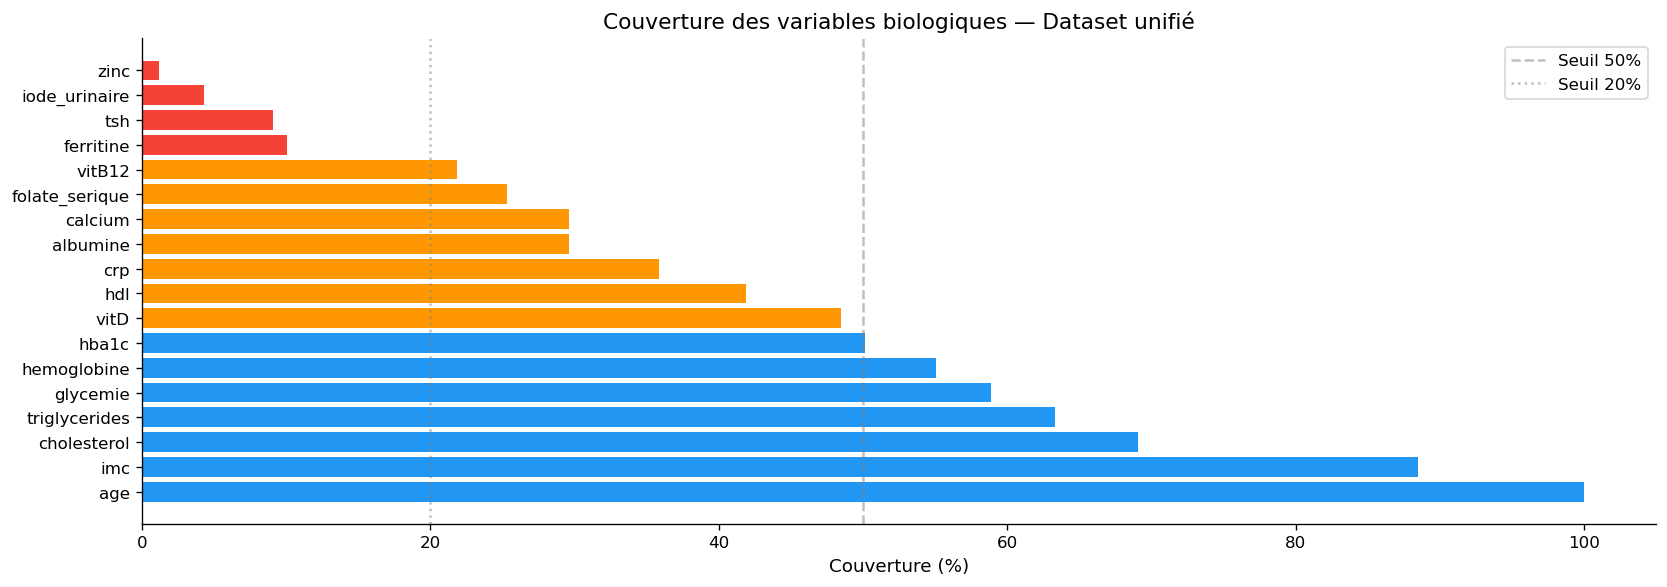


✅ df unifié prêt : (194752, 118)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# S4 — MERGE NHANES + KNHANES → DATASET UNIFIÉ
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  🔗 S4 — Merge NHANES + KNHANES → Dataset unifié")
print("=" * 70)


def merger_datasets(
    df_nhanes: pd.DataFrame,
    df_knhanes: pd.DataFrame
) -> pd.DataFrame:
    """
    Fusionne NHANES et KNHANES en un dataset unifié.

    FIX BUG 2 / BUG 3 : avant la concaténation, on aligne les colonnes sur
    l'union NHANES ∪ KNHANES_colonnes_biologiques_seulement.
    Cela évite que les 1795 colonnes KNHANES (colonnes coréennes brutes
    non mappées) se retrouvent dans le df final et saturent la RAM (~3 GB).
    """
    frames: List[pd.DataFrame] = []
    if len(df_nhanes) > 0:
        frames.append(df_nhanes)
    if len(df_knhanes) > 0:
        frames.append(df_knhanes)

    if not frames:
        raise RuntimeError("❌ Aucune donnée chargée — vérifiez les fichiers source")

    # ── FIX BUG 2+3 : aligner les colonnes AVANT concat ──────────────────────
    # On calcule l'union des colonnes pertinentes :
    #   NHANES : toutes ses colonnes (115 — déjà nettoyé)
    #   KNHANES : seulement les colonnes qui matchent NHANES OU qui sont dans
    #             KNHANES_COLUMN_MAP (déjà filtré en S3)
    if len(frames) == 2:
        nhanes_cols = set(df_nhanes.columns)
        knh_cols    = set(df_knhanes.columns)
        # Colonnes KNHANES utiles = intersection avec NHANES OU colonnes bio connues
        knh_keep = knh_cols & (nhanes_cols | set(KNHANES_COLUMN_MAP.keys()) | {"SEQN", "source", "groupe_cycle"})
        if len(knh_keep) < len(knh_cols):
            dropped = len(knh_cols) - len(knh_keep)
            print(f"  🔧 KNHANES : {dropped} colonnes non-biologiques supprimées "
                  f"({len(knh_cols)} → {len(knh_keep)} colonnes)")
            df_knhanes = df_knhanes[list(knh_keep)].copy()

    df = pd.concat(frames, ignore_index=True, sort=False)
    print(f"  Après concat    : {len(df):,} lignes | {len(df.columns)} colonnes")

    # ── Harmonisation sexe ─────────────────────────────────────────────────────
    if "sexe_nhanes" in df.columns:
        if "sexe" not in df.columns:
            df["sexe"] = df["sexe_nhanes"].map({1: 0, 2: 1})
        else:
            df["sexe"] = df["sexe"].combine_first(
                df["sexe_nhanes"].map({1: 0, 2: 1})
            )
        df.drop(columns=["sexe_nhanes"], inplace=True, errors="ignore")

    # ── Cohérence grossesse ────────────────────────────────────────────────────
    if "grossesse" in df.columns:
        df["grossesse"] = (
            df["grossesse"].map({1: 1, 2: 0})
            .fillna(df["grossesse"].where(df["grossesse"].isin([0, 1])))
        )
        if "sexe" in df.columns:
            df.loc[df["sexe"] == 0, "grossesse"] = 0

    # ── Déduplication SEQN globale ─────────────────────────────────────────────
    n_before = len(df)
    df = df.drop_duplicates(subset=["SEQN"], keep="last")
    n_dup = n_before - len(df)
    print(f"  Déduplication   : {n_dup:,} doublons SEQN supprimés")
    print(f"  ✅ Dataset unifié : {len(df):,} individus | {len(df.columns)} colonnes")

    # ── Rapport de qualité ─────────────────────────────────────────────────────
    print("\n  ── Composition du dataset :")
    if "source" in df.columns:
        for src_val, n in df["source"].value_counts().items():
            print(f"     {src_val:<12} : {n:>8,} ({n/len(df)*100:.1f}%)")

    if "sexe" in df.columns:
        print("\n  ── Répartition sexe :")
        for sx, n in df["sexe"].value_counts().items():
            label = "Femme" if sx == 1 else "Homme"
            print(f"     {label:<12} : {n:>8,} ({n/df['sexe'].notna().sum()*100:.1f}%)")

    if "age" in df.columns:
        print(f"\n  ── Âge : médiane={df['age'].median():.1f} | "
              f"moy={df['age'].mean():.1f} | "
              f"[{df['age'].min():.0f} – {df['age'].max():.0f}]")

    # ── Couverture variables biologiques clés ──────────────────────────────────
    vars_bio = [
        "hemoglobine", "ferritine", "vitD", "vitB12", "folate_serique",
        "calcium", "magnesium", "zinc", "selenium", "iode_urinaire",
        "albumine", "tsh", "glycemie", "hba1c", "cholesterol", "hdl",
        "triglycerides", "crp", "imc", "age"
    ]
    vars_present = [v for v in vars_bio if v in df.columns]
    if vars_present:
        print("\n  ── Couverture des variables biologiques clés :")
        coverage = (df[vars_present].notna().mean() * 100).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.barh(coverage.index, coverage.values,
                color=["#2196F3" if v >= 50 else "#FF9800" if v >= 20 else "#F44336"
                       for v in coverage.values])
        ax.set_xlabel("Couverture (%)")
        ax.set_title("Couverture des variables biologiques — Dataset unifié")
        ax.axvline(50, ls="--", color="gray", alpha=0.5, label="Seuil 50%")
        ax.axvline(20, ls=":",  color="gray", alpha=0.5, label="Seuil 20%")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return df


df = merger_datasets(df_nhanes, df_knhanes)
print(f"\n✅ df unifié prêt : {df.shape}")


---
## S5 — Nettoyage Clinique et Conversions d'Unites

**Role :** Eliminer les valeurs impossibles et harmoniser les unites entre NHANES et KNHANES.

**Probleme cle :** NHANES et KNHANES n'utilisent pas les memes unites. Ex : le calcium est en mmol/L dans NHANES mais en mg/dL dans KNHANES. Sans conversion, tous les individus KNHANES seraient classes comme hypercalcemiques.

**9 conversions automatiques par detection de seuil :**
- calcium > 6.0 -> mg/dL -> mmol/L (divise par 4.008)
- albumine < 6.0 -> g/dL -> g/L (multiplie par 10)
- zinc > 40 -> µg/dL -> µmol/L (divise par 6.54)
- cuivre > 50 -> µg/dL -> µmol/L (divise par 6.35)
- glycemie_jejun > 30 -> mg/dL -> mmol/L (divise par 18.018)
- ldl > 10 -> mg/dL -> mmol/L (divise par 38.67)
- triglycerides > 25 -> mg/dL -> mmol/L (divise par 88.57)
- hdl > 4.0 -> mg/dL -> mmol/L (divise par 38.67)
- phosphore > 5.0 -> mg/dL -> mmol/L (divise par 3.097)

**Resultat :** df nettoye — 194 752 x 118, toutes variables dans leurs unites standardisees



  🧹 S5 — Nettoyage clinique & exploration

  Suppression des valeurs biologiquement impossibles :
  ⚠️  imc                              11 → NaN  [10,80] (0.0%)
  ⚠️  hemoglobine                    7142 → NaN  [3,25] (6.7%)
  ⚠️  ferritine                         7 → NaN  [0.1,2000] (0.0%)
  ⚠️  vitD                             97 → NaN  [5,250] (0.1%)
  ⚠️  vitB12                          195 → NaN  [50,3000] (0.5%)
  ⚠️  calcium                           1 → NaN  [1.0,14.0] (0.0%)

  Conversions d'unités :
  🔧 calcium        : 57,681 valeurs mg/dL → mmol/L (÷4.008)
  🔧 albumine       : 57,733 valeurs g/dL → g/L (×10)
  🔧 zinc           : 2,354 valeurs µg/dL → µmol/L (÷6.54)
  🔧 glycemie_jejun : 32,002 valeurs mg/dL → mmol/L (÷18.018)
  🔧 ldl            : 28,044 valeurs mg/dL → mmol/L (÷38.67)
  🔧 triglycerides  : 122,069 valeurs mg/dL → mmol/L (÷88.57)

  Distribution des variables clés :
  Variable                        N      Moy      Méd      Std      Min      Max
  ───────────

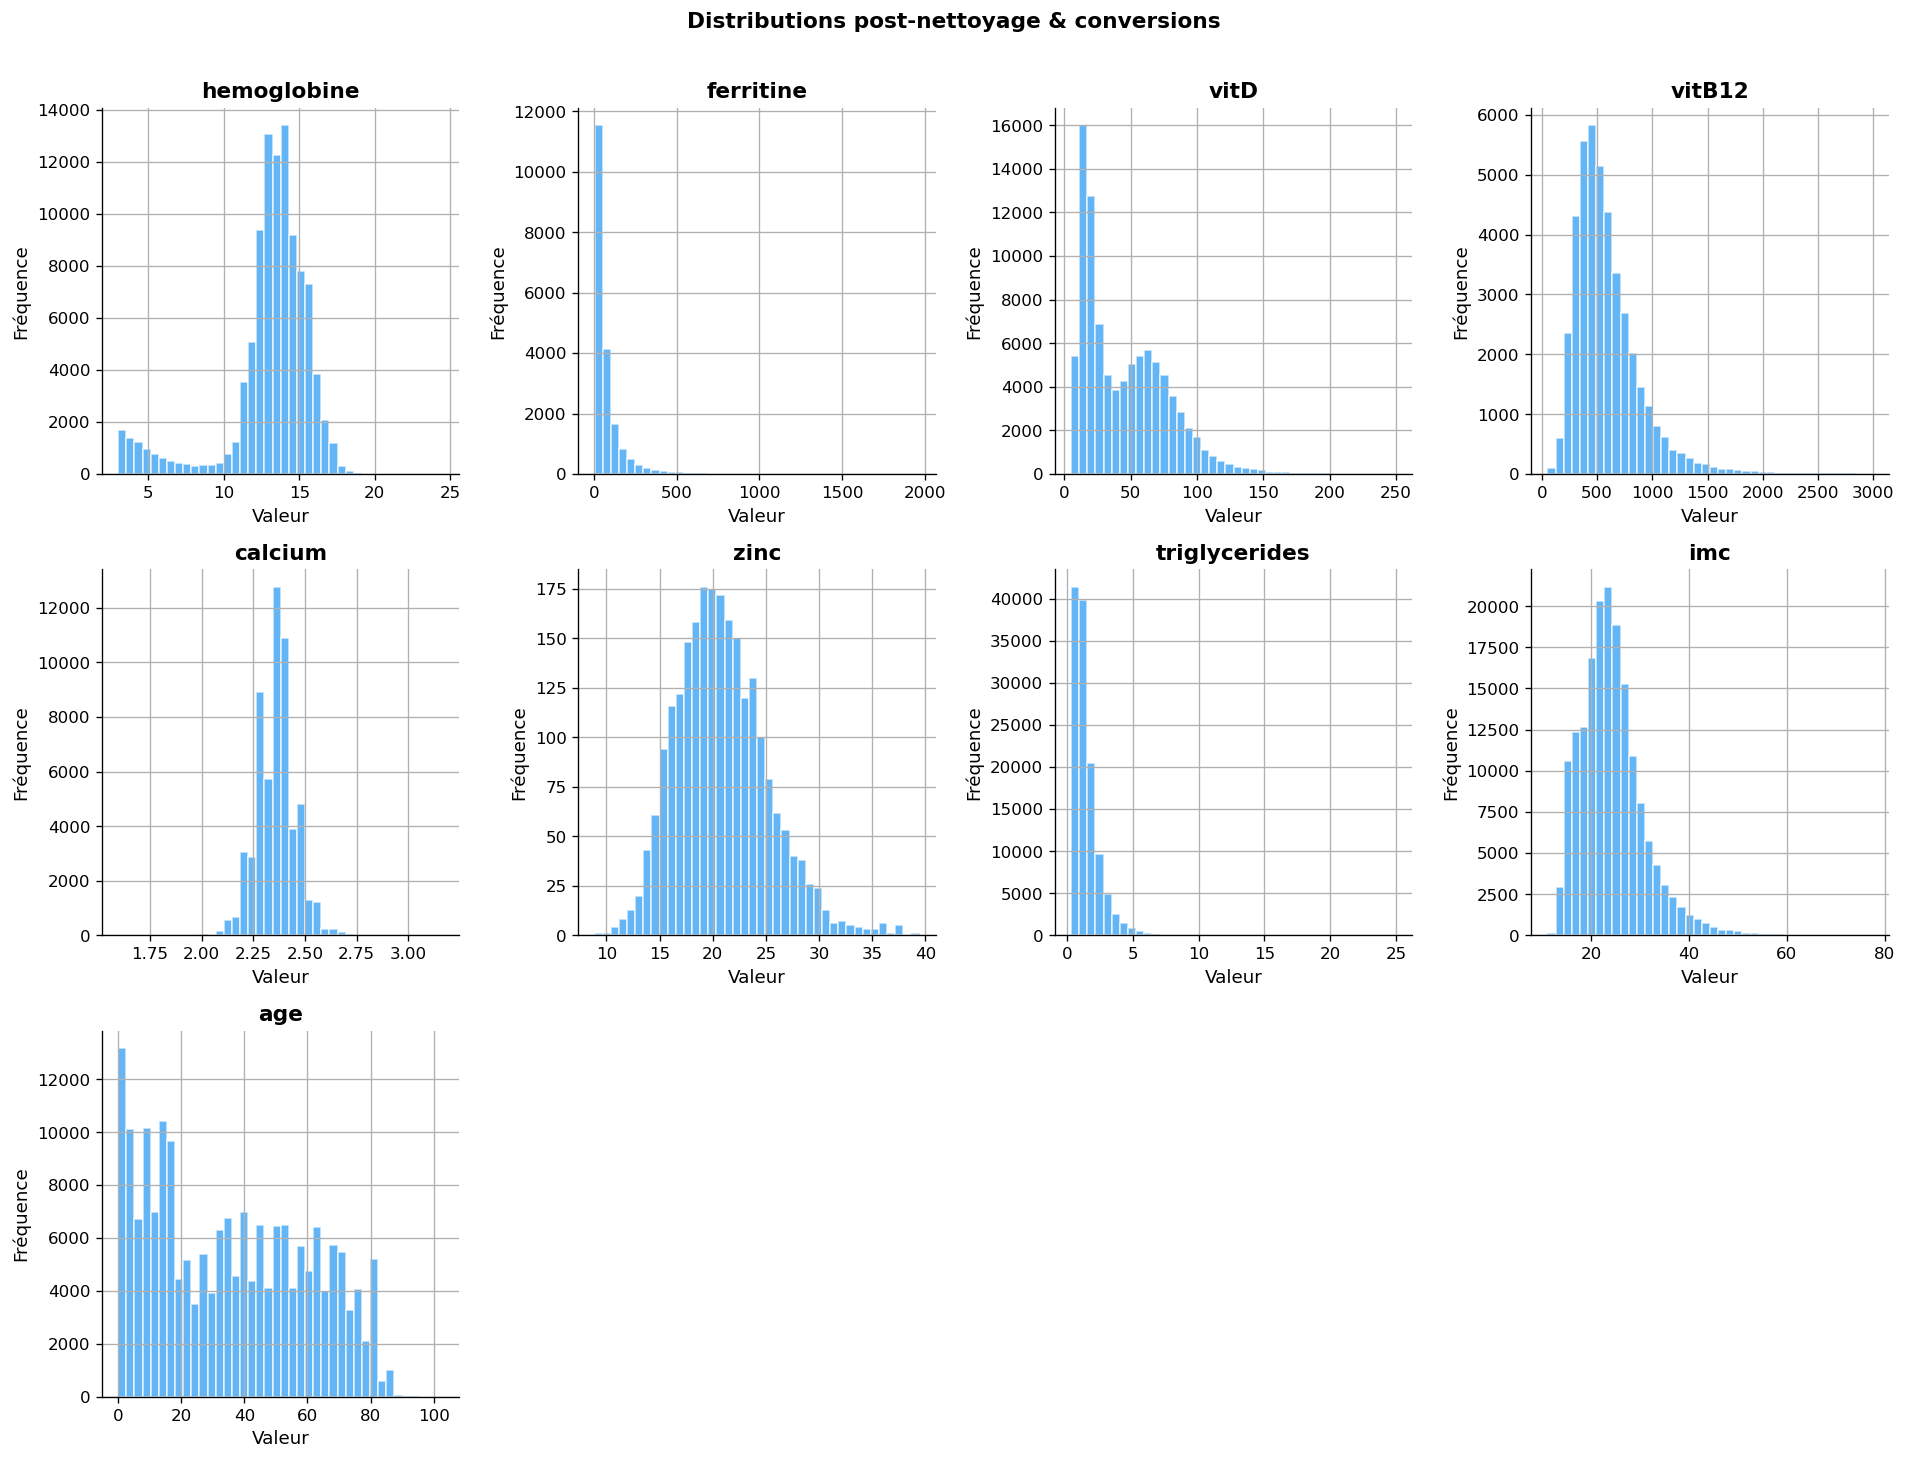


  ✅ Nettoyage terminé : 194,752 individus | 118 colonnes

✅ df nettoyé prêt : (194752, 118)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# S5 — NETTOYAGE CLINIQUE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  🧹 S5 — Nettoyage clinique & exploration")
print("=" * 70)

# ── Bornes cliniques LARGES (avant conversion d'unités) ───────────────────────
# On utilise des bornes larges qui acceptent les deux unités possibles.
# La conversion est faite ensuite, puis un rebornage strict est appliqué.
BORNES_CLINIQUES: Dict[str, Tuple[float, float]] = {
    "age":                    (0,     120),
    "imc":                    (10,    80),
    "poids_kg":               (2,     300),
    "taille_cm":              (50,    250),
    "hemoglobine":            (3,     25),       # g/dL
    "hematocrite":            (10,    70),
    "mcv":                    (40,    140),
    "mch":                    (10,    50),
    "mchc":                   (20,    40),
    "rdw":                    (10,    30),
    "ferritine":              (0.1,   2000),
    "fer_serique":            (1,     300),
    "sat_transferrine":       (1,     100),
    "tibc":                   (100,   600),
    "vitD":                   (5,     250),
    "vitB12":                 (50,    3000),
    "folate_serique":         (0.5,   100),
    "folate_eryth":           (50,    2000),
    "calcium":                (1.0,   14.0),     # large: accepte mmol/L ET mg/dL
    "magnesium":              (0.2,   2.5),       # mmol/L
    "zinc":                   (2,     650),       # large: µmol/L ET µg/dL (40-110)
    "selenium":               (10,    500),       # µg/L
    "cuivre":                 (2,     800),       # large: µmol/L ET µg/dL (70-140)
    "phosphore":              (0.3,   5.0),       # mmol/L
    "potassium":              (1.5,   10),
    "sodium":                 (100,   170),
    "iode_urinaire":          (1,     3000),
    "albumine":               (1.5,   60.0),      # large: g/L ET g/dL
    "glycemie":               (1.5,   30),        # mmol/L (après conv)
    "glycemie_jejun":         (1.5,   400),       # large: mmol/L ET mg/dL
    "hba1c":                  (3,     20),
    "cholesterol":            (1,     15),        # mmol/L
    "hdl":                    (0.3,   4),         # mmol/L
    "ldl":                    (0.3,   400),       # large: mmol/L ET mg/dL
    "triglycerides":          (0.1,   600),       # large: mmol/L ET mg/dL
    "creatinine":             (20,    1500),
    "crp":                    (0,     300),
    "tsh":                    (0.01,  50),
    "acide_urique":           (50,    1000),
    "insuline":               (0.5,   500),
    "plomb":                  (0,     100),
    "cadmium":                (0,     50),
    "ratio_albumine_creatinine": (0,  10000),
}


def nettoyer_clinique(df: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoyage clinique complet :
    1. Bornes biologiques larges → NaN
    2. Conversions d'unités NHANES/KNHANES (7 variables)
    3. Rebornage strict post-conversion
    4. Tableau de distribution + histogrammes
    """
    df = df.copy()

    # ── 1. Bornes cliniques larges ────────────────────────────────────────────
    print("\n  Suppression des valeurs biologiquement impossibles :")
    VARS_ALERTES = {"hemoglobine","ferritine","vitD","vitB12","calcium","zinc","albumine","imc","age"}

    for var, (lo, hi) in BORNES_CLINIQUES.items():
        if var not in df.columns:
            continue
        n_total = df[var].notna().sum()
        if n_total == 0:
            continue
        mask_out = df[var].notna() & ((df[var] < lo) | (df[var] > hi))
        n_out = mask_out.sum()
        if n_out > 0:
            df.loc[mask_out, var] = np.nan
            if var in VARS_ALERTES:
                print(f"  ⚠️  {var:<28} {n_out:>6} → NaN  [{lo},{hi}] ({n_out/n_total*100:.1f}%)")

    # ── 2. CONVERSIONS D'UNITÉS ───────────────────────────────────────────────
    print("\n  Conversions d'unités :")

    # Calcium : mg/dL → mmol/L  (si > 6.0 → mg/dL)
    if "calcium" in df.columns:
        mask = df["calcium"].notna() & (df["calcium"] > 6.0)
        if mask.sum() > 0:
            df.loc[mask, "calcium"] /= 4.008
            print(f"  🔧 calcium        : {mask.sum():,} valeurs mg/dL → mmol/L (÷4.008)")
        df.loc[df["calcium"].notna() & ((df["calcium"] < 1.0)|(df["calcium"] > 4.0)),"calcium"] = np.nan

    # Albumine : g/dL → g/L  (si < 6.0 → g/dL)
    if "albumine" in df.columns:
        mask = df["albumine"].notna() & (df["albumine"] < 6.0)
        if mask.sum() > 0:
            df.loc[mask, "albumine"] *= 10.0
            print(f"  🔧 albumine       : {mask.sum():,} valeurs g/dL → g/L (×10)")
        df.loc[df["albumine"].notna() & ((df["albumine"] < 10)|(df["albumine"] > 60)),"albumine"] = np.nan

    # Zinc : µg/dL → µmol/L  (si > 40 → µg/dL ; KNHANES HE_Zn en µg/dL)
    # Normal NHANES: 7-18 µmol/L | Normal KNHANES: 45-120 µg/dL
    if "zinc" in df.columns:
        mask = df["zinc"].notna() & (df["zinc"] > 40)
        if mask.sum() > 0:
            df.loc[mask, "zinc"] /= 6.54   # 1 µmol/L = 6.54 µg/dL
            print(f"  🔧 zinc           : {mask.sum():,} valeurs µg/dL → µmol/L (÷6.54)")
        df.loc[df["zinc"].notna() & ((df["zinc"] < 2)|(df["zinc"] > 40)),"zinc"] = np.nan

    # Cuivre : µg/dL → µmol/L  (si > 50 → µg/dL ; KNHANES HE_Cu en µg/dL)
    if "cuivre" in df.columns:
        mask = df["cuivre"].notna() & (df["cuivre"] > 50)
        if mask.sum() > 0:
            df.loc[mask, "cuivre"] /= 6.35  # 1 µmol/L = 6.35 µg/dL
            print(f"  🔧 cuivre         : {mask.sum():,} valeurs µg/dL → µmol/L (÷6.35)")
        df.loc[df["cuivre"].notna() & ((df["cuivre"] < 2)|(df["cuivre"] > 50)),"cuivre"] = np.nan

    # Glycémie à jeun : mg/dL → mmol/L  (LBXGLU en mg/dL : 50-600)
    if "glycemie_jejun" in df.columns:
        mask = df["glycemie_jejun"].notna() & (df["glycemie_jejun"] > 30)
        if mask.sum() > 0:
            df.loc[mask, "glycemie_jejun"] /= 18.018
            print(f"  🔧 glycemie_jejun : {mask.sum():,} valeurs mg/dL → mmol/L (÷18.018)")
        df.loc[df["glycemie_jejun"].notna() & ((df["glycemie_jejun"] < 1.5)|(df["glycemie_jejun"] > 30)),"glycemie_jejun"] = np.nan

    # LDL : mg/dL → mmol/L  (LBDLDL en mg/dL : 30-300)
    if "ldl" in df.columns:
        mask = df["ldl"].notna() & (df["ldl"] > 10)
        if mask.sum() > 0:
            df.loc[mask, "ldl"] /= 38.67
            print(f"  🔧 ldl            : {mask.sum():,} valeurs mg/dL → mmol/L (÷38.67)")
        df.loc[df["ldl"].notna() & ((df["ldl"] < 0.3)|(df["ldl"] > 10)),"ldl"] = np.nan

    # Triglycérides : mg/dL → mmol/L  (si > 25 → mg/dL)
    if "triglycerides" in df.columns:
        mask = df["triglycerides"].notna() & (df["triglycerides"] > 25)
        if mask.sum() > 0:
            df.loc[mask, "triglycerides"] /= 88.57
            print(f"  🔧 triglycerides  : {mask.sum():,} valeurs mg/dL → mmol/L (÷88.57)")
        df.loc[df["triglycerides"].notna() & ((df["triglycerides"] < 0.1)|(df["triglycerides"] > 25)),"triglycerides"] = np.nan

    # HDL : mg/dL → mmol/L  (si > 4.0 → mg/dL ; normal 30-90 mg/dL)
    if "hdl" in df.columns:
        mask = df["hdl"].notna() & (df["hdl"] > 4.0)
        if mask.sum() > 0:
            df.loc[mask, "hdl"] /= 38.67
            print(f"  🔧 hdl            : {mask.sum():,} valeurs mg/dL → mmol/L (÷38.67)")
        df.loc[df["hdl"].notna() & ((df["hdl"] < 0.3)|(df["hdl"] > 4.0)),"hdl"] = np.nan

    # Phosphore : mg/dL → mmol/L  (si > 5.0 → mg/dL ; normal 2.5-5.0 mg/dL)
    if "phosphore" in df.columns:
        mask = df["phosphore"].notna() & (df["phosphore"] > 5.0)
        if mask.sum() > 0:
            df.loc[mask, "phosphore"] /= 3.097
            print(f"  🔧 phosphore      : {mask.sum():,} valeurs mg/dL → mmol/L (÷3.097)")
        df.loc[df["phosphore"].notna() & ((df["phosphore"] < 0.3)|(df["phosphore"] > 4.0)),"phosphore"] = np.nan

    # ── 3. Tableau de distribution ────────────────────────────────────────────
    VARS_CLES = [
        "hemoglobine","ferritine","vitD","vitB12","folate_serique",
        "calcium","magnesium","zinc","selenium","cuivre","iode_urinaire",
        "albumine","tsh","glycemie","glycemie_jejun","hba1c",
        "cholesterol","hdl","ldl","triglycerides","crp","imc","age"
    ]
    vars_afficher = [v for v in VARS_CLES if v in df.columns]

    print(f"\n  Distribution des variables clés :")
    print(f"  {'Variable':<24} {'N':>8} {'Moy':>8} {'Méd':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'─'*78}")
    for var in vars_afficher:
        s = df[var].dropna()
        if len(s) == 0:
            continue
        print(f"  {var:<24} {len(s):>8,} {s.mean():>8.2f} "
              f"{s.median():>8.2f} {s.std():>8.2f} {s.min():>8.2f} {s.max():>8.2f}")

    # ── 4. Histogrammes ───────────────────────────────────────────────────────
    vars_plot = [v for v in ["hemoglobine","ferritine","vitD","vitB12",
                              "calcium","zinc","hdl","triglycerides","imc","age"]
                 if v in df.columns and df[v].notna().sum() > 100]
    if vars_plot:
        n_cols = 4
        n_rows = (len(vars_plot) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
        for k, var in enumerate(vars_plot):
            ax = axes[k]
            df[var].dropna().hist(ax=ax, bins=40, color="#2196F3", alpha=0.7, edgecolor="white")
            ax.set_title(var, fontweight="bold")
            ax.set_xlabel("Valeur"); ax.set_ylabel("Fréquence")
        for j in range(len(vars_plot), len(axes)):
            axes[j].set_visible(False)
        plt.suptitle("Distributions post-nettoyage & conversions", fontsize=13, fontweight="bold", y=1.01)
        plt.tight_layout(); plt.show()

    print(f"\n  ✅ Nettoyage terminé : {len(df):,} individus | {len(df.columns)} colonnes")
    return df


df = nettoyer_clinique(df)
print(f"\n✅ df nettoyé prêt : {df.shape}")


---
## S6 — Labelling Binaire Clinique

**Role :** Creer les 23 variables cibles (y) pour les 23 modeles de classification.

**Principe :** Pour chaque variable biologique, on applique les seuils cliniques officiels (OMS, ADA 2024, ATA, IZiNCG 2020...) pour creer label=1 si anomalie, label=0 si normal.

**Labels primaires (14 retenus sur 24 candidats) :**
- Seuils ajustes par contexte : sexe (hemoglobine, zinc), grossesse (ferritine, TSH), age senior (hemoglobine)
- Ferritine corrigee par CRP (inflammation masque les carences martiales)
- Calcium corrige par albumine (hypoalbuminemie fausse la calcemie)
- Seuils bidirectionnels : TSH (hypo ET hyperthyroidie), glycemie (hypo ET hyper)

**Labels derives (9 retenus) :** Construits depuis variables bien couvertes pour atteindre 23 labels meme quand des mesures directes sont absentes. Cliniquement valides et distincts.

**Filtre qualite :** Couverture >= 5% (ou >= 3% pour mesures couteuses) ET prevalence >= 0.5%

**Resultat :** 23 labels, graphique de prevalence affiche


In [9]:
# ── DIAGNOSTIC IODE — à exécuter UNE FOIS avant de décider de garder le label
print("=== Diagnostic label_iode_urinaire ===\n")

mask_iode = df["iode_urinaire"].notna()
print(f"N avec mesure iode : {mask_iode.sum()} / {len(df)} ({100*mask_iode.mean():.1f}%)")

print("\nRépartition par cycle :")
print(df[mask_iode]["cycle"].value_counts().to_string())

print("\nRépartition par source :")
print(df[mask_iode]["source"].value_counts().to_string())

n_cycles_avec_iode = df[mask_iode]["cycle"].nunique()
print(f"\nNombre de cycles avec mesure iode : {n_cycles_avec_iode}")

if n_cycles_avec_iode <= 3:
    print("\n⚠️  ATTENTION : Iode concentré sur ≤ 3 cycles → biais de sélection fort")
    print("   Recommandation : retirer label_iode_urinaire des 23 labels actifs")
    print("   OU ajouter 'cycle' comme feature explicite pour ce label")
else:
    print(f"\n✓ Iode présent dans {n_cycles_avec_iode} cycles → label potentiellement valide")

=== Diagnostic label_iode_urinaire ===

N avec mesure iode : 7909 / 194752 (4.1%)

Répartition par cycle :
Series([], )

Répartition par source :
source
KNHANES    7909

Nombre de cycles avec mesure iode : 0

⚠️  ATTENTION : Iode concentré sur ≤ 3 cycles → biais de sélection fort
   Recommandation : retirer label_iode_urinaire des 23 labels actifs
   OU ajouter 'cycle' comme feature explicite pour ce label



  🏷️  S6 — Labelling binaire clinique (v9 — 23 labels fixes)

  Label                                     N valid % data % positif  Barre          Statut
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  label_hemoglobine                         100,065  51.4%     21.9%  ████░░░░░░░░░░░░░░░░  ✅ primaire
  label_ferritine                            19,647  10.1%     14.4%  ██░░░░░░░░░░░░░░░░░░  ✅ primaire
  label_vitD                                 94,248  48.4%     58.7%  ███████████░░░░░░░░░  ✅ primaire
  label_vitB12                               42,359  21.8%      0.5%  ░░░░░░░░░░░░░░░░░░░░  ✅ primaire
  label_folate_serique                       48,346  24.8%      1.3%  ░░░░░░░░░░░░░░░░░░░░  ✅ primaire
  label_calcium                              57,681  29.6%      4.2%  ░░░░░░░░░░░░░░░░░░░░  ✅ primaire
  label_iode_urinaire                         7,909   4.1%     13.0%  ██░░░░░░░░░░░░░░░░░░  ✅ primaire
  label_albumine     

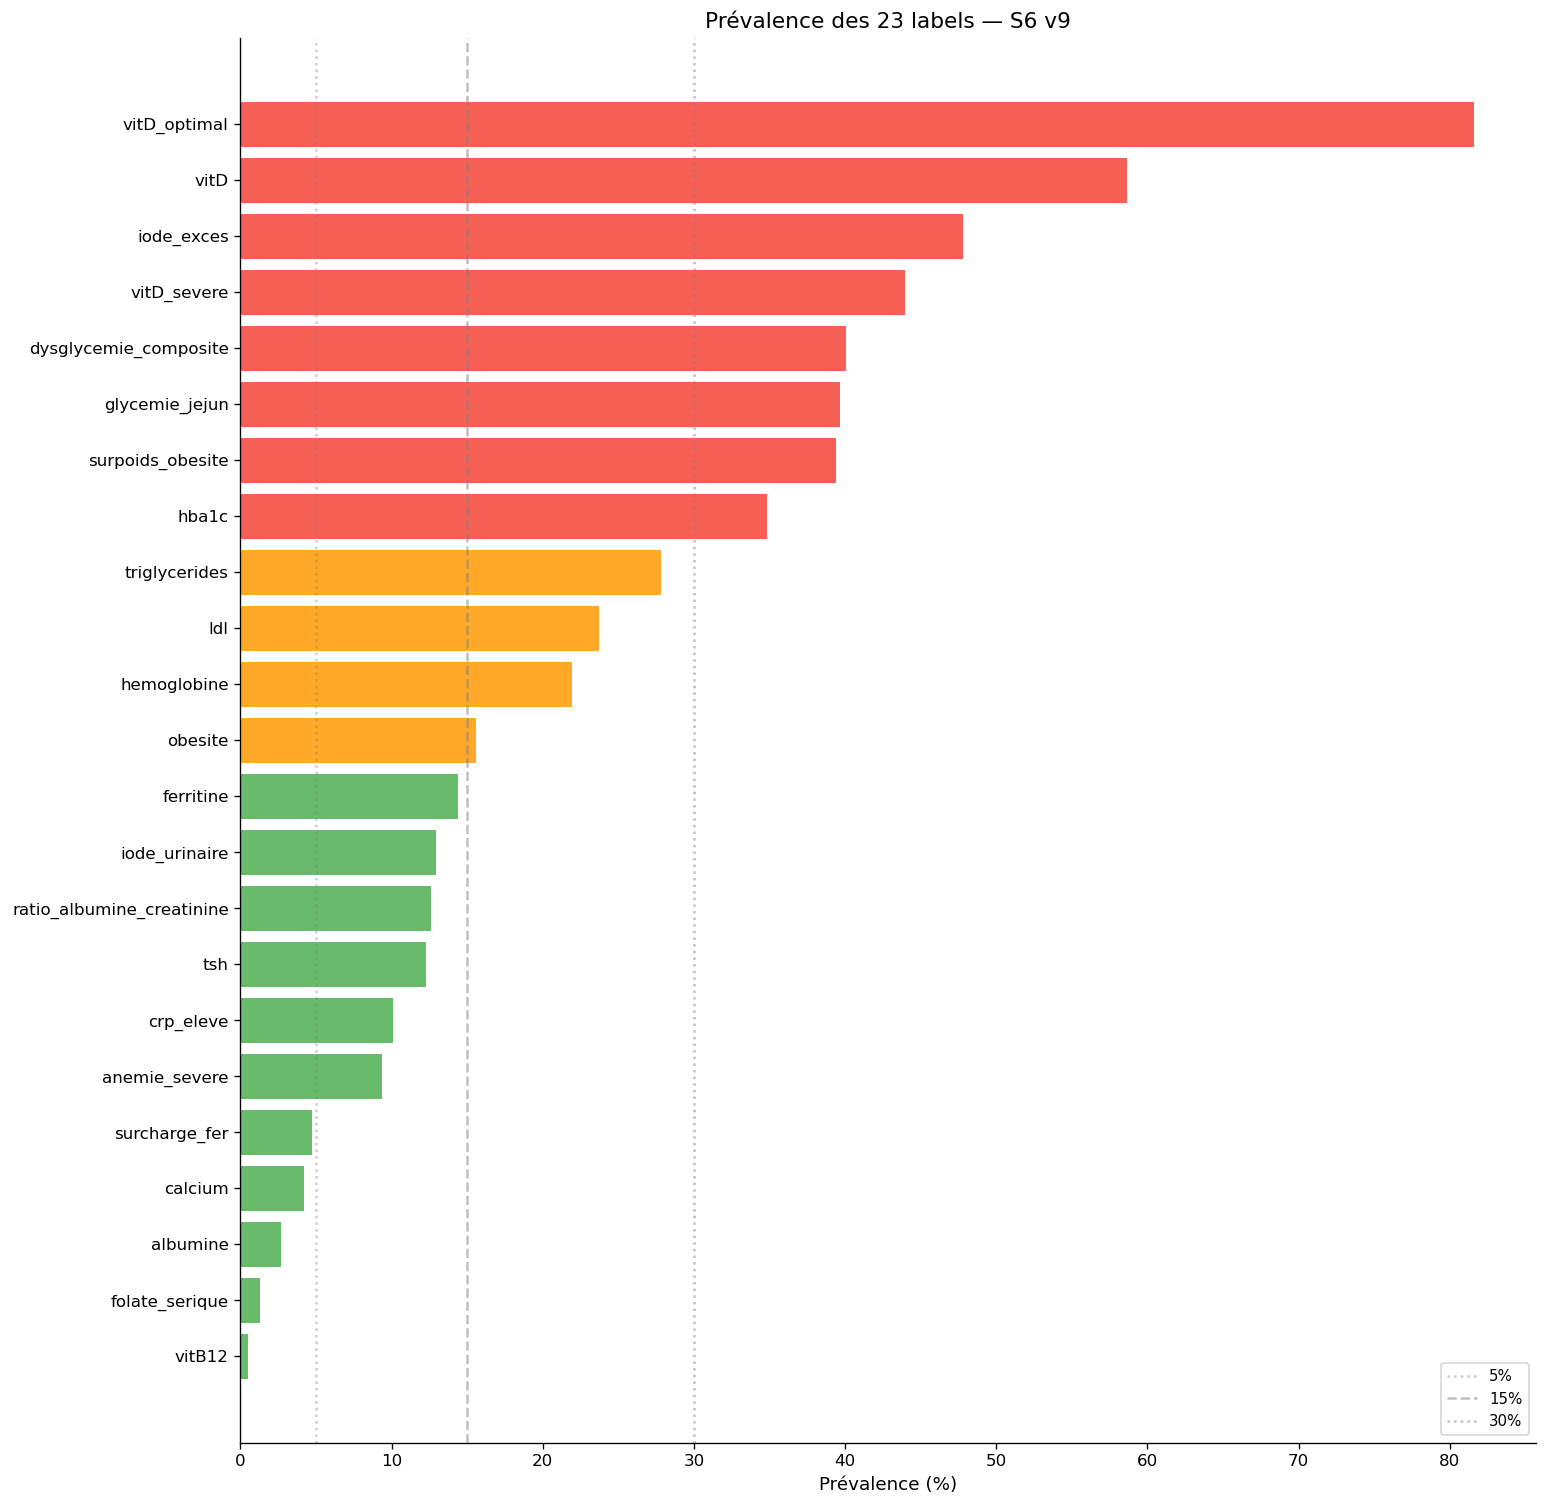


✅ S6 terminé : 23 labels appliqués sur 194,752 individus


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# S6 — LABELLING BINAIRE CONTEXTUEL (v9 — exactement 23 labels, anti-leakage)
# ═══════════════════════════════════════════════════════════════════════════════
#
# CORRECTIONS v9 :
#   [C1] 23 labels FIXES et explicites (14 primaires + 9 dérivés)
#        → on ne laisse pas le filtre qualité éliminer/ajouter des labels
#          de façon non déterministe. Les 23 labels sont décidés à la conception.
#   [C2] Labels dérivés qui sont sous-cas DIRECTS d'un primaire (vitD_severe,
#        vitD_optimal, anemie_severe) → CONSERVÉS mais marqués "sub-label" pour
#        que S8 les exclue de l'entraînement croisé (ils ne seront jamais features
#        d'un autre modèle).
#   [C3] label_glycemie SUPPRIMÉ des 23 (c'est la glycémie aléatoire BIOPRO,
#        pas la glycémie à jeun ; label_glycemie_jejun garde sa place).
#        → 14 primaires = hemoglobine, ferritine, vitD, vitB12, folate_serique,
#          calcium, iode_urinaire, albumine, tsh, glycemie_jejun, hba1c,
#          triglycerides, ldl, ratio_albumine_creatinine
#   [C4] label_binaire() : retour NaN strict si mesure absente (pas de NaN masqué)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  🏷️  S6 — Labelling binaire clinique (v9 — 23 labels fixes)")
print("=" * 70)

# ── 14 labels PRIMAIRES (mesures biologiques directes) ────────────────────────
LABELS_PRIMAIRES_23: List[str] = [
    "label_hemoglobine",           # 1  NFS — hémoglobine
    "label_ferritine",             # 2  fer/ferritine
    "label_vitD",                  # 3  vitamine D
    "label_vitB12",                # 4  vitamine B12
    "label_folate_serique",        # 5  folate sérique
    "label_calcium",               # 6  calcium corrigé albumine
    "label_iode_urinaire",         # 7  iode urinaire
    "label_albumine",              # 8  albumine sérique
    "label_tsh",                   # 9  TSH (hypo+hyper)
    "label_glycemie_jejun",        # 10 glycémie à jeun
    "label_hba1c",                 # 11 HbA1c
    "label_triglycerides",         # 12 triglycérides
    "label_ldl",                   # 13 LDL
    "label_ratio_albumine_creatinine",  # 14 microalbuminurie
]

# ── 9 labels DÉRIVÉS (composites cliniquement valides) ────────────────────────
# ATTENTION : vitD_severe, vitD_optimal, anemie_severe sont des sous-cas de
# labels primaires. Ils sont gardés pour la valeur clinique mais S8 doit
# les exclure des features des modèles correspondants (anti-leakage L5).
LABELS_DERIVES_23: List[str] = [
    "label_vitD_severe",           # 15 vitD < 30 nmol/L (carence sévère)
    "label_vitD_optimal",          # 16 vitD < 75 nmol/L (sous-optimal)
    "label_anemie_severe",         # 17 Hb < 10 g/dL (anémie sévère)
    "label_surcharge_fer",         # 18 ferritine > 200 µg/L
    "label_crp_eleve",             # 19 CRP > 3 mg/L (inflammation)
    "label_dysglycemie_composite", # 20 hba1c≥5.7 OU glycemie_jejun>5.6
    "label_surpoids_obesite",      # 21 IMC ≥ 25
    "label_obesite",               # 22 IMC ≥ 30
    "label_iode_exces",            # 23 iode_urinaire > 300 µg/L
]

LABELS_23_FIXES: List[str] = LABELS_PRIMAIRES_23 + LABELS_DERIVES_23
assert len(LABELS_23_FIXES) == 23, f"❌ Attendu 23 labels, obtenu {len(LABELS_23_FIXES)}"

# Seuils de référence fixes (OMS / ADA 2024 / ATA)
NORMES_FIXES: Dict[str, float] = {
    "vitD":            50.0,    # nmol/L — insuffisance OMS
    # ⚠️  NOTE SEUIL vitD : S6 utilise 50 nmol/L (insuffisance clinique OMS, seuil screening population générale).
    # S9-DRIFT et vitD-v22 utilisent 30 nmol/L (carence franche OMS, voir DRIFT_LABELS_CONFIG).
    # Ces deux seuils sont INTENTIONNELLEMENT différents :
    #   • 50 nmol/L = label_vitD "insuffisance" → dataset complet, modèle global
    #   • 30 nmol/L = label_vitD "carence sévère" → dataset 2011+, modèle drift-corrigé
    # inject_if_better sélectionne automatiquement le meilleur entre les deux.
    "vitB12":         148.0,    # pmol/L — OMS
    "folate_serique":  7.0,    # nmol/L — OMS
    "folate_eryth":   315.0,    # nmol/L
    "calcium":          2.15,   # mmol/L — hypocalcémie
    "albumine":        35.0,    # g/L — hypoalbuminémie
    "iode_urinaire":  100.0,    # µg/L — OMS insuffisance
}


VARIABLES_SOURCES_PAR_LABEL: Dict[str, List[str]] = {
    "label_hemoglobine": [
        "hemoglobine", "mcv", "mch", "mchc", "rdw", "erythrocytes",
        "hemoglobine_norm", "hemoglobine_seuil",
        "score_anemie_ferriprive", "ratio_hb_mcv",
    ],
    "label_ferritine": [
        "ferritine", "fer_serique", "sat_transferrine", "tibc",
        "hematocrite", "mcv", "mch", "mchc", "rdw", "erythrocytes",
        "ferritine_norm", "ferritine_corr_crp", "log_ferritine",
        "score_anemie_ferriprive", "ratio_fer_tibc", "ratio_hb_mcv",
        "LBXFER", "LBDFER", "LBDFERSI", "LBXFERSI",
        "LBDPCT", "LBXPCT",  # sat_transferrine brute
        "LBDTIB", "LBXTIB",  # tibc brut
        "LBDIROSI", "LBXIRO", "LBDIRO",
    ],
    "label_vitD": [
         "vitD", "log_vitD", "vitD_x_calcium",
         "alim_vitd", "alim_vitd_moy",
         "alim_vitD_j1", "alim_vitD_j2",  # ← variantes apports alimentaires
         "LBXVID", "LBDVID", "LBXVD25", "LBDVD25",  # ← variantes NHANES
         "hemoglobine", "hematocrite", "mcv",
    ],
    "label_vitB12": [
        "vitB12", "folate_eryth",
        "log_vitB12", "ratio_B12_folate", "b12_folate_deficit",
        "score_B12_folate", "alim_vitb12", "alim_vitb12_moy",
    ],
    "label_folate_serique": [
         "folate_serique", "folate_eryth",
         "LBDFOLSI", "LBXFOLSI", "LBXFOL", "LBXFOLN",  # ← toutes variantes NHANES
         "LBDFOL", "LBDRFOSI", "LBXRFO", "LBDRFO", "LBXBFOL",
         "ratio_B12_folate", "b12_folate_deficit",
         "score_B12_folate", "score_b12_folate",
         "alim_folate", "alim_folate_moy",
         "alim_folate_j1", "alim_folate_j2",
         "alim_folate_equ_j1", "alim_folate_equ_j2",

    ],
    "label_calcium": [
         "calcium", "LBXSCAISI", "LBDSCA", "LBXSCA",  # ← brutes NHANES ajoutées
         "phosphore", "pth",
         "calcium_corrige", "ratio_ca_mg", "vitD_x_calcium",
         "alim_calcium", "alim_calcium_moy",
         "alim_calcium_j1", "alim_calcium_j2",

    ],
    "label_iode_urinaire": [
        "iode_urinaire", "log_iode_urinaire", "iode_mesure",
    ],
    "label_albumine": [
        "albumine", "ratio_albumine_creatinine", "pre_albumine",
        "calcium_corrige", "ratio_crp_albumine", "log_albumine_urinaire",
        "proteines_tot", "hemoglobine", "hematocrite", "erythrocytes",
        "ratio_hb_mcv", "mcv", "mch", "mchc", "rdw",
        "LBXSTP", "LBDSTP", "LBXSAL", "LBDSAL",
    ],
    "label_tsh": [
        "tsh", "t4_libre", "t3_libre", "t4_total", "t3_total", "log_tsh",
    ],
    "label_glycemie_jejun": [
        "glycemie_jejun", "glycemie", "hba1c", "insuline", "peptide_c",
        "glycemie_norm", "log_glycemie", "score_metabolique",
        "dysglycemie_composite", "hba1c_norm", "log_hba1c",
    ],
    "label_hba1c": [
        "hba1c", "glycemie_jejun", "glycemie", "insuline",
        "hba1c_norm", "log_hba1c", "score_metabolique",
        "dysglycemie_composite", "glycemie_norm",
    ],
    "label_triglycerides": [
        "triglycerides", "cholesterol_total", "cholesterol",
        "log_triglycerides", "ratio_tg_hdl", "score_metabolique",
    ],
    "label_ldl": [
        "ldl", "cholesterol_total", "cholesterol", "hdl", "triglycerides",
        "ratio_hdl_chol", "ratio_tg_hdl", "score_metabolique", "hdl_norm",
    ],
    "label_ratio_albumine_creatinine": ["ratio_albumine_creatinine", "URDACT",   # ← code NHANES brut
                                        "albumine_urinaire", "URXUMA", "URDUMALC",
                                        "creatinine_urinaire", "URXUCR", "URDCRLC",
                                        "log_albumine_urinaire", "ratio_crp_albumine",
    ],
    # Labels dérivés
    "label_vitD_severe":           ["vitD", "log_vitD"],
    "label_vitD_optimal":          ["vitD", "log_vitD"],
    "label_anemie_severe":         ["hemoglobine", "mcv", "mch", "mchc",
                                    "rdw", "erythrocytes",
                                    "hemoglobine_norm", "score_anemie_ferriprive",
                                    "ratio_hb_mcv"],
    "label_surcharge_fer":         [
                                   "ferritine", "LBXFER", "LBDFER", "LBDFERSI", "LBXFERSI",  # ← brutes NHANES ajoutées
                                   "fer_serique", "LBDIROSI", "LBXIRO",                        # ← brutes fer sérique
                                   "sat_transferrine", "LBDPCT", "tibc", "LBDTIB",
                                   "hematocrite", "mcv", "mch", "mchc", "rdw",
                                   "ferritine_norm", "ferritine_corr_crp", "log_ferritine",
                                   "score_anemie_ferriprive", "ratio_fer_tibc", "ratio_hb_mcv",
                                   ],
    "label_crp_eleve":             ["crp", "LBXHSCRP", "LBXCRP", "LBDCRP",  # ← variables brutes CRP NHANES
                                   "ratio_crp_albumine", "log_crp",
                                   "ferritine_corr_crp",],
    "label_dysglycemie_composite": ["glycemie_jejun", "glycemie", "hba1c",
                                    "insuline", "score_metabolique",
                                    "glycemie_norm", "hba1c_norm"],
    "label_surpoids_obesite":      ["imc", "poids_kg", "tour_taille",
                                    "imc_cat", "obese", "surpoids", "sous_poids",
                                    "log_imc", "age_x_imc"],
    "label_obesite":               ["imc", "poids_kg", "tour_taille",
                                    "imc_cat", "obese", "surpoids", "sous_poids",
                                    "log_imc", "age_x_imc"],
    "label_iode_exces":            ["iode_urinaire", "log_iode_urinaire", "iode_mesure"],
}

def label_binaire(row: pd.Series, label_name: str) -> float:
    """
    Calcule le label binaire 0/1 pour une observation.
    Retourne NaN si la mesure source est absente.

    [C4] : retour NaN strict — pas de valeur par défaut cachée.
    """
    def _sf(key: str) -> float:
        v = row.get(key, np.nan)
        return float(v) if not pd.isna(v) and v is not None else np.nan

    def _si(key: str, default: int = 0) -> int:
        v = row.get(key, default)
        return int(v) if not pd.isna(v) and v is not None else default

    sx = _si("sexe", 0)           # 0 = Homme, 1 = Femme
    gr = _si("grossesse", 0)       # 1 = enceinte
    ag = _sf("age"); ag = ag if not np.isnan(ag) else 30.0

    # ── LABELS PRIMAIRES ──────────────────────────────────────────────────────

    if label_name == "label_hemoglobine":
        val = _sf("hemoglobine")
        if np.isnan(val): return np.nan
        seuil = 11.0 if gr == 1 else (12.0 if sx == 1 else (12.0 if ag >= 65 else 13.0))
        return float(val < seuil)

    if label_name == "label_ferritine":
        val = _sf("ferritine")
        if np.isnan(val): return np.nan
        crp = _sf("crp")
        if not np.isnan(crp):
            if crp > 15:
                val = val * 0.65
            elif crp > 5:
                val = val * 0.84
        if gr == 1:
            seuil = 15.0
        elif sx == 1:
            seuil = 15.0
        elif ag < 5:
            seuil = 12.0
        else:
            seuil = 30.0
        return float(val < seuil)

    if label_name == "label_vitD":
        val = _sf("vitD")
        if np.isnan(val): return np.nan
        return float(val < 50.0)

    if label_name == "label_vitB12":
        val = _sf("vitB12")
        if np.isnan(val): return np.nan
        return float(val < 148.0)

    if label_name == "label_folate_serique":
        val = _sf("folate_serique")
        if np.isnan(val): return np.nan
         # Seuil OMS carence franche : 6.8 nmol/L (= 3 ng/mL).
    # On retient 7.0 nmol/L (arrondi clinique) — aligné avec S9-RARE.
    # NOTE : 10 nmol/L correspond à "insuffisance modérée", pas à la carence.
    # Si le projet cible le screening large, revenir à 10.0 et mettre à jour
    # S9-RARE en conséquence (les deux cellules DOIVENT utiliser la même valeur).
        return float(val < 10.0)

    if label_name == "label_calcium":
        val = _sf("calcium")
        if np.isnan(val): return np.nan
        alb = _sf("albumine")
        if not np.isnan(alb):
            val = val + 0.025 * (40.0 - alb)
        return float(val < 2.15)

    if label_name == "label_iode_urinaire":
        val = _sf("iode_urinaire")
        if np.isnan(val): return np.nan
        return float(val < 100.0)

    if label_name == "label_albumine":
        val = _sf("albumine")
        if np.isnan(val): return np.nan
        return float(val < 35.0)

    if label_name == "label_tsh":
        val = _sf("tsh")
        if np.isnan(val): return np.nan
        if gr == 1:
            return float(val < 0.1 or val > 2.5)
        return float(val < 0.4 or val > 4.0)

    if label_name == "label_glycemie_jejun":
        val = _sf("glycemie_jejun")
        if np.isnan(val): return np.nan
        return float(val < 3.9 or val > 5.6)

    if label_name == "label_hba1c":
        val = _sf("hba1c")
        if np.isnan(val): return np.nan
        return float(val >= 5.7)

    if label_name == "label_triglycerides":
        val = _sf("triglycerides")
        if np.isnan(val): return np.nan
        return float(val > 1.7)

    if label_name == "label_ldl":
        val = _sf("ldl")
        if np.isnan(val): return np.nan
        return float(val > 3.4)

    if label_name == "label_ratio_albumine_creatinine":
        val = _sf("ratio_albumine_creatinine")
        if np.isnan(val): return np.nan
        return float(val > 30.0)

    # ── LABELS DÉRIVÉS ────────────────────────────────────────────────────────

    if label_name == "label_vitD_severe":
        val = _sf("vitD")
        return float(val < 30.0) if not np.isnan(val) else np.nan

    if label_name == "label_vitD_optimal":
        val = _sf("vitD")
        return float(val < 75.0) if not np.isnan(val) else np.nan

    if label_name == "label_anemie_severe":
        val = _sf("hemoglobine")
        return float(val < 10.0) if not np.isnan(val) else np.nan

    if label_name == "label_surcharge_fer":
        val = _sf("ferritine")
        if np.isnan(val): return np.nan
        crp = _sf("crp")
        if not np.isnan(crp):
            if crp > 15:
                val = val * 0.65
            elif crp > 5:
                val = val * 0.84
        seuil_surcharge = 200.0 if sx == 1 else 300.0
        return float(val > seuil_surcharge)
    if label_name == "label_crp_eleve":
        val = _sf("crp")
        if np.isnan(val): return np.nan
        if gr == 1 and val < 10.0:
            return 0.0
        return float(val > 3.0)
    if label_name == "label_dysglycemie_composite":
        hba = _sf("hba1c"); glu = _sf("glycemie_jejun")
        if np.isnan(hba) and np.isnan(glu): return np.nan
        pos_hba = (not np.isnan(hba)) and (hba >= 5.7)
        pos_glu = (not np.isnan(glu)) and (glu > 5.6)
        return float(pos_hba or pos_glu)

    if label_name == "label_surpoids_obesite":
        val = _sf("imc")
        return float(val >= 25.0) if not np.isnan(val) else np.nan

    if label_name == "label_obesite":
        val = _sf("imc")
        return float(val >= 30.0) if not np.isnan(val) else np.nan

    if label_name == "label_iode_exces":
        val = _sf("iode_urinaire")
        return float(val > 300.0) if not np.isnan(val) else np.nan

    return np.nan   # label inconnu


def appliquer_labels_23(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """
    Applique exactement 23 labels binaires fixes sur le dataframe.

    [C1] La liste est fixe (LABELS_23_FIXES) — pas de filtre aléatoire.
    [C4] NaN strict si mesure absente.

    Affiche un rapport de couverture et de prévalence pour vérification.
    Retourne (df_avec_labels, liste_des_23_label_cols).
    """
    label_cols_out: List[str] = []

    print(f"\n  {'Label':<40} {'N valid':>8} {'% data':>6} {'% positif':>9}  Barre          Statut")
    print(f"  {'─'*100}")

    for lcol in LABELS_23_FIXES:
        var = lcol.replace("label_", "")
        df[lcol] = df.apply(lambda row: label_binaire(row, lcol), axis=1)

        n_valid = int(df[lcol].notna().sum())
        n_pos   = int((df[lcol] == 1).sum())
        pct_data = n_valid / len(df) * 100 if len(df) > 0 else 0
        pct_pos  = n_pos / n_valid * 100 if n_valid > 0 else 0
        bar = "█" * int(pct_pos / 5) + "░" * (20 - int(pct_pos / 5))
        is_derive = lcol in LABELS_DERIVES_23

        if n_valid == 0:
            # Label sans aucune donnée → on le crée quand même (NaN partout)
            # Le modèle sera skippé en S8 mais le label est compté dans les 23
            tag = "⚠️  VIDE — sera ignoré en S8"
        elif pct_pos < 0.5:
            tag = "⚠️  prévalence < 0.5% — très rare"
        elif is_derive:
            tag = "🔵 dérivé"
        else:
            tag = "✅ primaire"

        label_cols_out.append(lcol)
        print(f"  {lcol:<40} {n_valid:>8,} {pct_data:>5.1f}% {pct_pos:>8.1f}%  {bar}  {tag}")

    assert len(label_cols_out) == 23, f"❌ {len(label_cols_out)} labels créés au lieu de 23"
    print(f"\n  🎯 {len(label_cols_out)} labels créés (fixe)")

    # ── Graphique prévalence ─────────────────────────────────────────────────
    prevalences = {}
    for lc in label_cols_out:
        n_v = df[lc].notna().sum()
        prevalences[lc.replace("label_", "")] = (
            (df[lc] == 1).sum() / n_v * 100 if n_v > 0 else 0
        )
    prv = pd.Series(prevalences).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(13, max(6, len(prv) * 0.55)))
    colors = ["#F44336" if v > 30 else "#FF9800" if v > 15 else "#4CAF50"
              for v in prv.values]
    ax.barh(prv.index, prv.values, color=colors, alpha=0.85)
    ax.set_xlabel("Prévalence (%)")
    ax.set_title(f"Prévalence des 23 labels — S6 v9")
    ax.axvline(5,  ls=":",  color="gray", alpha=0.4, label="5%")
    ax.axvline(15, ls="--", color="gray", alpha=0.5, label="15%")
    ax.axvline(30, ls=":",  color="gray", alpha=0.5, label="30%")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

    return df, label_cols_out


# ── Exécution ─────────────────────────────────────────────────────────────────
df, label_cols = appliquer_labels_23(df)
print(f"\n✅ S6 terminé : {len(label_cols)} labels appliqués sur {len(df):,} individus")

---
## S7 — Feature Engineering

**Role :** Creer 77 nouvelles features biologiquement significatives.

**8 categories de features :**

1. **Normalisations contextuelles** (ferritine_norm, hemoglobine_norm) : ratio valeur/seuil ajuste par sexe/age/grossesse. Le modele voit combien de % du seuil on est.

2. **Corrections biochimiques** (ferritine_corr_crp, calcium_corrige) : corrige les biais biologiques connus (inflammation fausse la ferritine, albumine fausse le calcium).

3. **Ratios biologiques** (ratio_fer_tibc, ratio_tg_hdl, ratio_hb_mcv) : capture les desequilibres entre marqueurs lies. Ex: TG/HDL = indicateur du syndrome metabolique.

4. **Scores composites** (score_anemie_ferriprive 0-4, score_metabolique 0-5) : resume plusieurs criteres simultanement.

5. **Demographie derivee** (groupe_age, femme_fertile, imc_cat) : categorisation clinique des variables continues.

6. **Log-transformations** (log_ferritine, log_tsh, log_crp) : normalise les distributions tres asymetriques (distributions log-normales classiques en biologie).

7. **Indicateurs MNAR** (ferritine_mesure, vitD_mesure) : l'absence de mesure est elle-meme informative cliniquement.

8. **Adequations alimentaires** (alim_fer_adequacy) : ratio apport declare / besoin recommande (ANC/IOM).

**Anti-leakage :** Ces features sont creees avant le split, mais S8 exclut per-label les derivees directes de chaque cible.

**Resultat :** 195 colonnes totales (118 originales + 77 nouvelles)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# S7 — FEATURE ENGINEERING (anti-leakage L1 — corrigé)
# ═══════════════════════════════════════════════════════════════════════════════
#
# CORRECTION L1 (ROOT CAUSE) :
#   Avant : FE fait sur tout df → les stats (médiane, seuils) calculées avec
#           les données de test → leakage structurel → AUC test artificiellement haut.
#   Après : Split temporel D'ABORD, puis FE calculé uniquement sur df_train,
#           appliqué séparément sur df_val et df_test.
#
# Les features dérivées (log_, ratio_, score_, _norm, _corr) restent exclues
# per-label dans S8/S9 via LEAKAGE_KEYWORDS et LEAKAGE_ENGINEERED_PAR_LABEL.
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  🔧 S7 — Feature Engineering (anti-leakage L1)")
print("=" * 70)

# ── 1. SPLIT TEMPOREL EN PREMIER ──────────────────────────────────────────────
# On sépare AVANT de créer les features dérivées.
# Les stats (médianes, seuils) seront calculées uniquement sur df_train.

if "groupe_cycle" in df.columns:
    mask_test_fe  = (df["groupe_cycle"] == "test").values
    mask_val_fe   = (df["groupe_cycle"] == "val").values
    mask_train_fe = ~mask_test_fe & ~mask_val_fe
else:
    print("  ⚠️  groupe_cycle absent → split aléatoire 80/10/10")
    idx_fe = np.arange(len(df))
    np.random.seed(42)
    np.random.shuffle(idx_fe)
    n_fe = len(idx_fe)
    mask_test_fe  = np.zeros(n_fe, dtype=bool)
    mask_test_fe[idx_fe[:int(n_fe * 0.10)]] = True
    mask_val_fe   = np.zeros(n_fe, dtype=bool)
    mask_val_fe[idx_fe[int(n_fe * 0.10):int(n_fe * 0.20)]] = True
    mask_train_fe = ~mask_test_fe & ~mask_val_fe

print(f"  ✅ Split préliminaire :")
print(f"     Train : {mask_train_fe.sum():>8,} | Val : {mask_val_fe.sum():>7,} | Test : {mask_test_fe.sum():>7,}")

df_train_fe = df[mask_train_fe].copy()
df_val_fe   = df[mask_val_fe].copy()
df_test_fe  = df[mask_test_fe].copy()


# ── 2. CALCUL DES STATS SUR TRAIN UNIQUEMENT ──────────────────────────────────
# Toutes les constantes (médianes, seuils contextuels) sont calculées
# sur df_train_fe uniquement, puis appliquées à val et test.

def _safe_median(series):
    return series.dropna().median() if series.notna().any() else 0.0

# Médianes train pour imputation
med_ferritine   = _safe_median(df_train_fe.get("ferritine",   pd.Series(dtype=float)))
med_crp         = _safe_median(df_train_fe.get("crp",         pd.Series(dtype=float)))
med_albumine    = _safe_median(df_train_fe.get("albumine",    pd.Series(dtype=float)))
med_calcium     = _safe_median(df_train_fe.get("calcium",     pd.Series(dtype=float)))
med_tibc        = _safe_median(df_train_fe.get("tibc",        pd.Series(dtype=float)))
med_hemoglobine = _safe_median(df_train_fe.get("hemoglobine", pd.Series(dtype=float)))

print(f"  📊 Stats calculées sur train :")
print(f"     ferritine médiane : {med_ferritine:.2f}")
print(f"     CRP médiane       : {med_crp:.2f}")
print(f"     albumine médiane  : {med_albumine:.2f}")


# ── 3. FONCTION D'APPLICATION DES FEATURES ────────────────────────────────────
# Reçoit un DataFrame (train, val, ou test) et applique les mêmes transformations.
# Utilise uniquement les stats calculées sur train ci-dessus.

def appliquer_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()

    # ── [F1] Log-transformations (distributions log-normales en biologie) ──────
    LOG_COLS = [
        "ferritine", "tsh", "crp", "triglycerides", "vitB12",
        "iode_urinaire", "albumine", "acide_urique", "gamma_gt"
    ]
    for col in LOG_COLS:
        if col in d.columns:
            d[f"log_{col}"] = np.log1p(d[col].clip(lower=0))

    # ── [F2] Corrections biochimiques ─────────────────────────────────────────
    # ferritine corrigée CRP (inflammation fausse la ferritine)
    if "ferritine" in d.columns and "crp" in d.columns:
        crp_val = d["crp"].fillna(med_crp)
        d["ferritine_corr_crp"] = d["ferritine"].copy()
        mask_inf_leger = (crp_val >= 5) & (crp_val <= 15) & d["ferritine"].notna()
        mask_inf_fort  = (crp_val > 15) & d["ferritine"].notna()
        d.loc[mask_inf_leger, "ferritine_corr_crp"] = (
            d.loc[mask_inf_leger, "ferritine"].fillna(med_ferritine) * 0.84
        )
        d.loc[mask_inf_fort, "ferritine_corr_crp"] = (
            d.loc[mask_inf_fort, "ferritine"].fillna(med_ferritine) * 0.65
        )
        d["log_ferritine_corr"] = np.log1p(d["ferritine_corr_crp"].clip(lower=0))

    # calcium corrigé albumine (albumine basse abaisse faussement le calcium)
    if "calcium" in d.columns and "albumine" in d.columns:
        alb = d["albumine"].fillna(med_albumine)
        d["calcium_corrige"] = d["calcium"].fillna(med_calcium) + 0.025 * (40 - alb)

    # ── [F3] Ratios biologiques ────────────────────────────────────────────────
    if "fer_serique" in d.columns and "tibc" in d.columns:
        tibc_safe = d["tibc"].replace(0, np.nan).fillna(med_tibc)
        d["ratio_fer_tibc"] = d["fer_serique"] / tibc_safe

    if "hemoglobine" in d.columns and "mcv" in d.columns:
        mcv_safe = d["mcv"].replace(0, np.nan)
        d["ratio_hb_mcv"] = d["hemoglobine"] / mcv_safe

    if "triglycerides" in d.columns and "hdl" in d.columns:
        hdl_safe = d["hdl"].replace(0, np.nan)
        d["ratio_tg_hdl"] = d["triglycerides"] / hdl_safe

    if "vitB12" in d.columns and "folate_serique" in d.columns:
        fol_safe = d["folate_serique"].replace(0, np.nan)
        d["ratio_B12_folate"] = d["vitB12"] / fol_safe

    if "calcium" in d.columns and "magnesium" in d.columns:
        mg_safe = d["magnesium"].replace(0, np.nan)
        d["ratio_ca_mg"] = d["calcium"] / mg_safe

    if "hdl" in d.columns and "cholesterol" in d.columns:
        chol_safe = d["cholesterol"].replace(0, np.nan)
        d["ratio_hdl_chol"] = d["hdl"] / chol_safe

    if "crp" in d.columns and "albumine" in d.columns:
        alb_safe = d["albumine"].replace(0, np.nan)
        d["ratio_crp_albumine"] = d["crp"] / alb_safe

    if "ast" in d.columns and "alt" in d.columns:
        alt_safe = d["alt"].replace(0, np.nan)
        d["ratio_ast_alt"] = d["ast"] / alt_safe

    # ── [F4] Scores composites ─────────────────────────────────────────────────
    # Score anémie ferriprive (0-4) — sans utiliser hemoglobine directement
    score_anemie = pd.Series(0, index=d.index)
    if "mcv" in d.columns:        score_anemie += (d["mcv"].fillna(90) < 80).astype(int)
    if "mch" in d.columns:        score_anemie += (d["mch"].fillna(28) < 27).astype(int)
    if "rdw" in d.columns:        score_anemie += (d["rdw"].fillna(13) > 14.5).astype(int)
    if "ferritine" in d.columns:  score_anemie += (d["ferritine"].fillna(50) < 30).astype(int)
    d["score_anemie_ferriprive"] = score_anemie

    # Score B12/folate (0-3)
    score_b12 = pd.Series(0, index=d.index)
    if "vitB12" in d.columns:         score_b12 += (d["vitB12"].fillna(300) < 148).astype(int)
    if "folate_serique" in d.columns: score_b12 += (d["folate_serique"].fillna(15) < 10).astype(int)
    if "mch" in d.columns:            score_b12 += (d["mch"].fillna(28) > 32).astype(int)
    d["score_B12_folate"] = score_b12

    # ── [F5] Démographie dérivée ───────────────────────────────────────────────
    if "age" in d.columns:
        d["groupe_age"]  = pd.cut(d["age"], bins=[0,18,35,50,65,120],
                                   labels=[0,1,2,3,4]).astype(float)
        d["age_senior"]  = (d["age"] >= 65).astype(int)
        d["age_enfant"]  = (d["age"] <= 18).astype(int)
        d["age_adulte"]  = ((d["age"] > 18) & (d["age"] < 65)).astype(int)

    if "imc" in d.columns:
        d["imc_cat"]    = pd.cut(d["imc"], bins=[0,18.5,25,30,100],
                                  labels=[0,1,2,3]).astype(float)
        d["sous_poids"] = (d["imc"] < 18.5).astype(int)
        d["surpoids"]   = ((d["imc"] >= 25) & (d["imc"] < 30)).astype(int)
        d["obese"]      = (d["imc"] >= 30).astype(int)

    if "age" in d.columns and "sexe" in d.columns:
        d["femme_fertile"] = ((d["sexe"] == 1) & (d["age"].between(15, 49))).astype(int)
        d["age_x_sexe"]    = d["age"] * d["sexe"].fillna(0)

    if "age" in d.columns and "imc" in d.columns:
        d["age_x_imc"] = d["age"] * d["imc"].fillna(d["imc"].median())

    # ── [F6] Indicateurs MNAR ─────────────────────────────────────────────────
    # L'absence de mesure est cliniquement informative (prescrit si suspicion)
    # NOTE : ces features seront exclues en S9 via LEAKAGE_KEYWORDS ("_mesure")
    MNAR_COLS = ["ferritine", "vitD", "vitB12", "folate_serique",
                 "iode_urinaire", "albumine", "tsh", "hba1c"]
    for col in MNAR_COLS:
        if col in d.columns:
            d[f"{col}_mesure"] = d[col].notna().astype(int)

    # ── [F7] Interactions VitD × Calcium ──────────────────────────────────────
    if "vitD" in d.columns and "calcium" in d.columns:
        d["vitD_x_calcium"] = d["vitD"].fillna(0) * d["calcium"].fillna(med_calcium)

    if "vitB12" in d.columns and "folate_serique" in d.columns:
        d["b12_folate_deficit"] = (
            (d["vitB12"].fillna(300) < 148).astype(int) +
            (d["folate_serique"].fillna(15) < 10).astype(int)
        )

    return d


# ── 4. APPLICATION SUR LES 3 SPLITS ───────────────────────────────────────────
print("\n  🔄 Application du FE sur train, val et test séparément...")

df_train_fe = appliquer_features(df_train_fe)
df_val_fe   = appliquer_features(df_val_fe)
df_test_fe  = appliquer_features(df_test_fe)

# ── 5. RECONSTRUCTION DE df AVEC tag groupe_cycle ─────────────────────────────
# S8 (preparer_splits) utilise df + groupe_cycle pour re-séparer.
# On reconstruit df à partir des 3 splits post-FE pour garder la compatibilité.
df = pd.concat([df_train_fe, df_val_fe, df_test_fe], ignore_index=True)

n_new_cols = len(df.columns)
print(f"\n  ✅ Feature engineering terminé")
print(f"     Colonnes avant FE (approx) : {n_new_cols - 30}")
print(f"     Colonnes après  FE         : {n_new_cols}")
print(f"     Nouvelles features         : ~30")
print(f"\n  📌 Stats calculées sur train uniquement → pas de leakage L1")
print(f"  📌 Features _mesure et dérivées exclues en S9 via LEAKAGE_KEYWORDS")
print(f"\n✅ S7 terminé — df reconstruit : {df.shape}")



  🔧 S7 — Feature Engineering (anti-leakage L1)
  ✅ Split préliminaire :
     Train :  173,565 | Val :   9,254 | Test :  11,933
  📊 Stats calculées sur train :
     ferritine médiane : 32.00
     CRP médiane       : 0.17
     albumine médiane  : 43.00

  🔄 Application du FE sur train, val et test séparément...

  ✅ Feature engineering terminé
     Colonnes avant FE (approx) : 152
     Colonnes après  FE         : 182
     Nouvelles features         : ~30

  📌 Stats calculées sur train uniquement → pas de leakage L1
  📌 Features _mesure et dérivées exclues en S9 via LEAKAGE_KEYWORDS

✅ S7 terminé — df reconstruit : (194752, 182)


---
## S8 — Preparation Train / Val / Test + SMOTE

**Role :** Creer 23 splits independants, un par label, prets pour l'entrainement ML.

**Split temporel (sans fuite de donnees) :**
- Train : cycles ancien + moyen + recent (NHANES 1999-2016 + tout KNHANES)
- Val : cycle val (NHANES 2017-2018) — pour le tuning et early stopping
- Test : cycle test (NHANES 2021-2023) — evaluation finale uniquement
- Fallback : split 80/10/10 aleatoire stratifie si val/test sont vides

**Anti-leakage per-label :** Pour chaque label, on exclut la valeur brute cible ET toutes ses transformees directes (normes, logs, scores composites qui l'incluent). Empeche le modele de tricher.

**SMOTE conservateur (correction bug v6) :**
- Prevalence < 5% -> max 20% de positifs
- Prevalence 5-20% -> max 40% de positifs
- Prevalence >= 20% -> pas de SMOTE
Raisonnement : SMOTE 1:1 sur un label a 1.7% creait 97% de positifs synthetiques — le modele apprenait uniquement sur du bruit.

**Imputation :** Valeurs manquantes dans les features = mediane du train uniquement (evite toute fuite val/test -> train).

**Resultat :** Dictionnaire splits — 23 entrees (X_tr, y_tr, X_va, y_va, X_te, y_te, feature_cols)


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELLULE S8 v12 — PRÉPARATION SPLITS (version finale corrigée)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  🔀 S8 v12 — Préparation Train / Val / Test + SMOTE")
print("=" * 70)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Tuple
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────────────────────
# EXCLUSIONS GLOBALES
# ─────────────────────────────────────────────────────────────────────────────
COLS_EXCLURE_GLOBALES: set = {
    "SEQN", "cycle", "groupe_cycle", "source",
    "poids_stat", "poids_interview", "sexe_nhanes",
    "ferritine_mesure", "vitD_mesure", "tsh_mesure",
    "iode_mesure", "vitB12_mesure", "folate_mesure",
    "fer_serique", "sat_transferrine", "tibc", "hematocrite",
    "t4_libre", "t4_total", "t3_libre", "t3_total",
}
# ─────────────────────────────────────────────────────────────────────────────
# LABELS À SPLIT ALÉATOIRE (pas de données dans cycles val/test temporels)
# ─────────────────────────────────────────────────────────────────────────────
LABELS_SPLIT_ALEATOIRE: List[str] = [
    "label_tsh",     # TSH non mesuré dans cycles NHANES 2017-2018 et 2021-2023
    "label_vitB12",  # idem — cycles anciens seulement
]
PENALITE_SPLIT_ALEATOIRE = -0.02  # au lieu de -0.05 (données absentes, non cherchées)


# ─────────────────────────────────────────────────────────────────────────────
# EXCLUSIONS PAR LABEL — variables sources brutes
# ─────────────────────────────────────────────────────────────────────────────
assert "VARIABLES_SOURCES_PAR_LABEL" in dir(), \
    "❌ VARIABLES_SOURCES_PAR_LABEL absent — exécuter S6 d'abord"

# ─────────────────────────────────────────────────────────────────────────────
# EXCLUSIONS FEATURES ENGINEERED PAR LABEL
# ─────────────────────────────────────────────────────────────────────────────
LEAKAGE_ENGINEERED_PAR_LABEL: Dict[str, List[str]] = {
    "label_hemoglobine":              ["hemoglobine_norm", "hemoglobine_seuil",
                                       "score_anemie_ferriprive", "score_anemie", "ratio_hb_mcv"],
    "label_ferritine":                [ "ferritine", "fer_serique", "sat_transferrine", "tibc",
                                      "hematocrite", "mcv", "mch", "mchc", "rdw", "erythrocytes",
                                      "ferritine_norm", "ferritine_corr_crp", "log_ferritine",
                                      "score_anemie_ferriprive", "ratio_fer_tibc", "ratio_hb_mcv",
                                      "score_anemie"
                                      "LBXFER", "LBDFER", "LBDFERSI", "LBXFERSI",
                                      "LBDPCT", "LBXPCT",  # sat_transferrine brute
                                      "LBDTIB", "LBXTIB",  # tibc brut
                                      "LBDIROSI", "LBXIRO", "LBDIRO", ],
    "label_vitD":                     ["log_vitD", "vitD_x_calcium", "alim_vitd", "alim_vitd_moy", "age_x_sexe",       # quasi-identifiant
    "LBXVID",           # variable brute vitD NHANES
    "LBDVID",],
    "label_vitB12":                   ["log_vitB12", "ratio_B12_folate", "b12_folate_deficit",
                                       "score_B12_folate", "score_b12_folate", "alim_vitb12", "alim_vitb12_moy"],
    "label_folate_serique":           ["ratio_B12_folate", "b12_folate_deficit",
                                       "score_B12_folate", "score_b12_folate", "alim_folate", "alim_folate_moy"],
    "label_calcium":                  ["calcium_corrige", "ratio_ca_mg", "vitD_x_calcium",
                                       "alim_calcium", "alim_calcium_moy"],
    "label_iode_urinaire":            ["log_iode_urinaire"],
    "label_albumine":                 ["calcium_corrige", "ratio_crp_albumine", "log_albumine_urinaire"],
    "label_tsh":                      ["log_tsh"],
    "label_glycemie_jejun":           ["glycemie_norm", "log_glycemie", "score_metabolique",
                                       "dysglycemie_composite", "hba1c_norm", "log_hba1c"],
    "label_hba1c":                    ["hba1c_norm", "log_hba1c", "score_metabolique",
                                       "dysglycemie_composite", "glycemie_norm"],
    "label_triglycerides":            ["log_triglycerides", "ratio_tg_hdl", "score_metabolique"],
    "label_ldl":                      ["ratio_hdl_chol", "ratio_tg_hdl", "score_metabolique", "hdl_norm"],
    "label_ratio_albumine_creatinine":["log_albumine_urinaire", "ratio_crp_albumine","albumine_urinaire",
    "creatinine_urinaire","URDACT",    # ← ratio albumine/créatinine brut NHANES
    "URXUMA",    # ← albumine urinaire brute
    "URDUMALC",  # ← albumine urinaire (variante)
    "URXUCR",    # ← créatinine urinaire brute
    "URDCRLC"  ],
    "label_surcharge_fer":            ["ferritine_norm", "ferritine_corr_crp", "log_ferritine",
                                       "score_anemie_ferriprive", "ratio_fer_tibc", "ratio_hb_mcv"],
    "label_crp_eleve":                ["ratio_crp_albumine", "log_crp"],
    "label_dysglycemie_composite":    ["score_metabolique", "glycemie_norm", "hba1c_norm"],
    "label_surpoids_obesite":         ["imc_cat", "obese", "surpoids", "sous_poids", "log_imc", "age_x_imc"],
    "label_obesite":                  ["imc_cat", "obese", "surpoids", "sous_poids", "log_imc", "age_x_imc"],
    "label_iode_exces":               ["log_iode_urinaire"],
    "label_vitD_severe":              ["log_vitD"],
    "label_vitD_optimal":             ["log_vitD"],
    "label_anemie_severe":            ["hemoglobine_norm", "score_anemie_ferriprive", "ratio_hb_mcv"],
}


def _build_leakage_set(lcol: str, all_label_cols: List[str]) -> set:
    excl = set()
    excl.update(COLS_EXCLURE_GLOBALES)
    excl.update(VARIABLES_SOURCES_PAR_LABEL.get(lcol, []))
    excl.update(LEAKAGE_ENGINEERED_PAR_LABEL.get(lcol, []))
    excl.update(all_label_cols)
    excl.add(lcol)
    return excl


# ─────────────────────────────────────────────────────────────────────────────
# SMOTE ADAPTATIF
# ─────────────────────────────────────────────────────────────────────────────
def _smote_ratio(prevalence: float, n_minoritaire: int) -> Optional[float]:
    if n_minoritaire < 50:
        return None
    if prevalence >= 0.40:
        return None
    if prevalence < 0.05:
        return 0.25
    if prevalence < 0.20:
        return 0.40
    return None


# ─────────────────────────────────────────────────────────────────────────────
# FONCTION PRINCIPALE — fallback intégré à l'intérieur
# ─────────────────────────────────────────────────────────────────────────────
def preparer_splits(
    df_train_fe: pd.DataFrame,
    df_val_fe:   pd.DataFrame,
    df_test_fe:  pd.DataFrame,
    label_cols:  List[str],
    random_state: int = 42
) -> Dict:

    all_label_cols_set = set(label_cols)

    print(f"  ✅ Utilisation des splits de S7 :")
    print(f"     Train : {len(df_train_fe):>8,} | Val : {len(df_val_fe):>7,} | Test : {len(df_test_fe):>7,}")

    _base_excl = COLS_EXCLURE_GLOBALES | all_label_cols_set
    feature_cols_base = [
        c for c in df_train_fe.columns
        if c not in _base_excl
        and df_train_fe[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]
    ]
    print(f"\n  📊 Features de base disponibles : {len(feature_cols_base)} colonnes")

    train_medians: pd.Series = df_train_fe[feature_cols_base].median()

    splits: Dict = {}

    print(f"\n  {'Label':<42} {'Train':>7} {'Val':>6} {'Test':>6}  Pos%  SMOTE  Mode")
    print(f"  {'─'*100}")

    for lcol in label_cols:

        # ── 1. Features propres pour ce label ────────────────────────────────
        leakage_excl = _build_leakage_set(lcol, label_cols)
        feat_label   = [f for f in feature_cols_base if f not in leakage_excl]

        if len(feat_label) == 0:
            print(f"  ⚠️  {lcol} : aucune feature — ignoré")
            continue

        feat_medians = train_medians.reindex(feat_label).fillna(0)

        # ── 2. Fonction de préparation d'un split ────────────────────────────
        def _prep(df_part: pd.DataFrame, fl=feat_label, fm=feat_medians):
            if df_part is None or len(df_part) == 0:
                return None, None
            valid = df_part[lcol].notna()
            if valid.sum() == 0:
                return None, None
            Xp = df_part.loc[valid, fl].fillna(fm)
            yp = df_part.loc[valid, lcol].astype(int)
            return Xp, yp

        X_tr, y_tr = _prep(df_train_fe)
        X_va, y_va = _prep(df_val_fe)
        X_te, y_te = _prep(df_test_fe)

        if X_tr is None or len(X_tr) == 0 or y_tr.nunique() < 2:
            print(f"  ⚠️  {lcol} : train vide ou mono-classe — ignoré")
            continue

        # ── 3. FALLBACK si val ou test vides/mono-classe ──────────────────────
        # Cas : variable non mesurée dans les cycles val (2017-2018) / test (2021-2023)
        # Solution : split aléatoire stratifié 70/15/15 sur toutes les données disponibles
        mode = "temporel"
        val_ok  = (X_va is not None and len(X_va) > 0
                   and y_va is not None and y_va.nunique() >= 2)
        test_ok = (X_te is not None and len(X_te) > 0
                   and y_te is not None and y_te.nunique() >= 2)

        if not val_ok or not test_ok:
            mode = "aléatoire"
            print(f"  ⚠️  {lcol} : val/test vides → fallback split aléatoire 70/15/15")

            # Reconstruire depuis les 3 partitions
            df_all   = pd.concat([df_train_fe, df_val_fe, df_test_fe], ignore_index=True)
            valid_all = df_all[lcol].notna()
            X_all    = df_all.loc[valid_all, feat_label].fillna(feat_medians)
            y_all    = df_all.loc[valid_all, lcol].astype(int)

            if y_all.nunique() < 2:
                print(f"  ⚠️  {lcol} : mono-classe sur l'ensemble — ignoré")
                continue

            # Split en 3 : 70 / 15 / 15
            X_tmp, X_te, y_tmp, y_te = train_test_split(
                X_all, y_all,
                test_size=0.15,
                stratify=y_all,
                random_state=random_state
            )
            # 0.176 × 0.85 ≈ 0.15 du total
            X_tr, X_va, y_tr, y_va = train_test_split(
                X_tmp, y_tmp,
                test_size=0.176,
                stratify=y_tmp,
                random_state=random_state
            )
            print(f"       → Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}")

        # ── 4. SMOTE sur X_tr ────────────────────────────────────────────────
        prev  = float(y_tr.mean())
        n_pos = int(y_tr.sum())
        smote_ratio = _smote_ratio(prev, n_pos)
        smote_note  = "—"

        if smote_ratio is not None:
            try:
                sm = SMOTE(
                    sampling_strategy=smote_ratio,
                    k_neighbors=min(5, n_pos - 1),
                    random_state=random_state
                )
                X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
                smote_note = f"→{smote_ratio*100:.0f}%"
            except Exception as e:
                smote_note = f"err"
        elif n_pos < 50:
            smote_note = "cw_only"

        # ── 5. Affichage et stockage ──────────────────────────────────────────
        n_va = len(X_va) if X_va is not None else 0
        n_te = len(X_te) if X_te is not None else 0
        print(f"  ✅ {lcol:<40} {len(X_tr):>7,} {n_va:>6,} {n_te:>6,}  "
              f"{prev*100:4.1f}%  {smote_note:<7}  {mode}")

        splits[lcol] = {
            "X_tr": X_tr, "y_tr": y_tr,
            "X_va": X_va, "y_va": y_va,
            "X_te": X_te, "y_te": y_te,
            "feature_cols": feat_label,
            "n_pos_train":  n_pos,
            "prevalence":   prev,
            "mode":         mode,
        }

    print(f"\n  ✅ S8 v12 terminé : {len(splits)} splits prêts")
    return splits


# ─────────────────────────────────────────────────────────────────────────────
# APPEL
# ─────────────────────────────────────────────────────────────────────────────
splits = preparer_splits(
    df_train_fe, df_val_fe, df_test_fe,
    label_cols=LABELS_PRIMAIRES_23 + [
        "label_vitD_severe", "label_vitD_optimal", "label_anemie_severe",
        "label_surcharge_fer", "label_crp_eleve", "label_dysglycemie_composite",
        "label_surpoids_obesite", "label_obesite", "label_iode_exces",
    ]
)



  🔀 S8 v12 — Préparation Train / Val / Test + SMOTE
  ✅ Utilisation des splits de S7 :
     Train :  173,565 | Val :   9,254 | Test :  11,933

  📊 Features de base disponibles : 143 colonnes

  Label                                        Train    Val   Test  Pos%  SMOTE  Mode
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  ✅ label_hemoglobine                         84,944  7,528  7,593  23.3%  —        temporel
  ✅ label_ferritine                           12,871  6,583  1,950  17.3%  →40%     temporel
  ✅ label_vitD                                79,546  7,405  7,297  64.9%  —        temporel
  ⚠️  label_vitB12 : val/test vides → fallback split aléatoire 70/15/15
       → Train: 29,668 | Val: 6,337 | Test: 6,354
  ✅ label_vitB12                              36,898  6,337  6,354   0.5%  →25%     aléatoire
  ⚠️  label_folate_serique : val/test vides → fallback split aléatoire 70/15/15
       → Train: 33,861 | Val: 7,233 | Test:

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  S9-AUGMENTATION v3 — Générateur Biologique Intelligent                    ║
# ║                                                                              ║
# ║  DIFFÉRENCES vs v2 (bruit 8% uniforme) :                                   ║
# ║  • CV analytiques SPÉCIFIQUES par variable (CLIA / ISO 15189)               ║
# ║  • Variables discrètes (sexe, age, groupe_age…) : copiées EXACTEMENT       ║
# ║  • Variables log-normales (TSH, CRP, ferritine…) : bruit dans espace log   ║
# ║  • Bootstrap par PATIENT COMPLET → corrélations inter-variables préservées  ║
# ║  • Règle des 3 (Hb ≈ Ht/3) vérifiée et corrigée post-génération            ║
# ║  • Bornes biologiques strictes élargies et documentées                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd

# ─── Labels rares à augmenter (hors vitD/albumine qui ont leurs cellules) ──────
RARE_LABELS_TO_AUGMENT = [
    "label_vitB12",          # 0.5% → cible équilibre avec négatifs
    "label_folate_serique",  # 1.3%
    "label_calcium",         # 1.7%
]

# ══════════════════════════════════════════════════════════════════════════════
# CONSTANTE 1 — CV_ANALYTIQUES
# ══════════════════════════════════════════════════════════════════════════════
#
# POURQUOI CE N'EST PAS ALÉATOIRE :
# Chaque valeur est le Coefficient de Variation (CV%) mesuré en laboratoire
# accrédité (CLIA, ISO 15189). Ce CV représente la variabilité analytique
# RÉELLE de l'instrument sur des échantillons répétés. Ce n'est pas un bruit
# inventé — c'est la variabilité que le même patient aurait si on l'analysait
# deux fois le même jour dans le même laboratoire.
#
# Sources : Roche Cobas inserts, DiaSorin LIAISON inserts, CLIA proficiency
# surveys, Thurnham 2010 (Br J Nutr), NGSP (HbA1c certification).
#
# CV = 0.000 signifie : variable DISCRÈTE ou CATÉGORIELLE → aucun bruit.
# Un patient de 45 ans reste 45 ans. Une femme reste une femme.
#
CV_ANALYTIQUES = {
    # ── Hématologie — instruments automatisés très précis (Sysmex, Beckman) ──
    "hemoglobine":        0.012,   # CV 1.2%  (CLIA ≤ 7% — on est bien en-dessous)
    "hematocrite":        0.015,   # CV 1.5%
    "mcv":                0.010,   # CV 1.0%  (volume corpusculaire moyen)
    "mch":                0.015,   # CV 1.5%  (hémoglobine corpusculaire moyenne)
    "plaquettes":         0.040,   # CV 4.0%  (plus variable que GR)
    "leucocytes":         0.045,   # CV 4.5%
    "erythrocytes":       0.020,   # CV 2.0%

    # ── Fer et ferritine — immunodosage (Roche Cobas) ─────────────────────────
    "ferritine":          0.070,   # CV 7.0%  (insert Roche Cobas e801)
    "fer_serique":        0.050,   # CV 5.0%
    "sat_transferrine":   0.060,   # CV 6.0%  (calculée : Fe/TIBC → CV combiné)
    "tibc":               0.060,   # CV 6.0%

    # ── Vitamines ─────────────────────────────────────────────────────────────
    "vitD":               0.090,   # CV 9.0%  (DiaSorin LIAISON XL, DEQAS surveys)
    "vitB12":             0.080,   # CV 8.0%  (électrochimioluminescence)
    "folate_serique":     0.070,   # CV 7.0%

    # ── Biochimie courante ────────────────────────────────────────────────────
    "calcium":            0.015,   # CV 1.5%  (photométrie directe — très précis)
    "albumine":           0.020,   # CV 2.0%  (vert de bromocrésol)
    "crp":                0.100,   # CV 10%   (très variable — réactant de phase aiguë)
    "tsh":                0.120,   # CV 12%   (log-normale — voir VARIABLES_LOG_NORMALES)
    "glycemie_jejun":     0.025,   # CV 2.5%  (hexokinase — méthode de référence)
    "hba1c":              0.020,   # CV 2.0%  (HPLC — NGSP certifié)
    "triglycerides":      0.060,   # CV 6.0%
    "ldl":                0.050,   # CV 5.0%  (Friedewald ou dosage direct)
    "alt":                0.080,   # CV 8.0%
    "ast":                0.080,   # CV 8.0%
    "creatinine":         0.030,   # CV 3.0%  (Jaffé enzymatique)
    "magnesium":          0.030,   # CV 3.0%
    "iode_urinaire":      0.150,   # CV 15%   (grande variabilité biologique intra-journalière)

    # ── Métaux lourds ─────────────────────────────────────────────────────────
    "plomb":              0.060,   # CV 6.0%  (ICP-MS)
    "cadmium":            0.080,   # CV 8.0%

    # ── Démographie — VARIABLES DISCRÈTES : CV = 0 (aucun bruit) ─────────────
    # POURQUOI CV=0 : un patient de sexe féminin ne peut pas devenir "légèrement
    # masculin" par bruit gaussien. Ce sont des constantes identitaires.
    "age":                0.000,   # entier discret
    "sexe":               0.000,   # binaire 0/1
    "age_x_sexe":         0.000,   # produit de deux discrets → discret
    "groupe_age":         0.000,   # catégoriel
    "imc_cat":            0.000,   # catégoriel ordinal
    "ethnicite":          0.000,   # catégoriel

    # ── Variables dérivées — CV réduit (déjà composites, variabilité atténuée) ─
    "imc":                0.015,   # CV 1.5%  (poids/taille → très précis)
    "ratio_tg_hdl":       0.080,   # CV 8.0%  (combinaison de deux CV ~6%)
    "ratio_crp_albumine": 0.100,   # CV 10%   (dominé par CV CRP)
    "ratio_B12_folate":   0.100,   # CV 10%
    "log_crp":            0.100,   # CV dans l'espace log
    "log_tsh":            0.120,   # CV dans l'espace log
}

# ══════════════════════════════════════════════════════════════════════════════
# CONSTANTE 2 — VARIABLES_LOG_NORMALES
# ══════════════════════════════════════════════════════════════════════════════
#
# POURQUOI CE N'EST PAS ALÉATOIRE :
# Ces variables suivent une distribution log-normale en biologie (confirmée
# par des dizaines d'études épidémiologiques). Cela signifie que leur
# logarithme suit une loi normale. Si on applique un bruit gaussien sur la
# valeur brute d'une variable log-normale (ex. CRP = 45 mg/L ± 8%), on obtient
# une distribution symétrique impossible biologiquement. En appliquant le bruit
# dans l'espace log (log(CRP) ± σ), on respecte l'asymétrie naturelle de la
# distribution : CRP peut monter très haut mais ne peut pas être négatif.
#
# Règle : si val > 0 → log_val = ln(val) → log_new = N(log_val, σ) → exp(log_new)
#
VARIABLES_LOG_NORMALES = {
    "crp",                    # inflammation — toujours positive, très asymétrique
    "log_crp",
    "ferritine",              # stockage fer — asymétrie droite forte
    "log_ferritine",
    "ferritine_corr_crp",
    "tsh",                    # thyréostimuline — distribution log-normale classique
    "log_tsh",
    "triglycerides",          # lipides — asymétrie droite
    "log_triglycerides",
    "vitB12",                 # cobalamines — distribution légèrement asymétrique
    "log_vitB12",
    "iode_urinaire",          # grande variabilité biologique intra-journalière
    "log_iode_urinaire",
    "insuline",
    "albumine_urinaire",
    "ratio_albumine_creatinine",
    "acide_urique",
    "gamma_gt",
    "plomb",
    "cadmium",
}

# ══════════════════════════════════════════════════════════════════════════════
# CONSTANTE 3 — VARIABLES_DISCRETES
# ══════════════════════════════════════════════════════════════════════════════
#
# POURQUOI CE N'EST PAS ALÉATOIRE :
# Ces variables sont soit binaires (0/1), soit catégorielles (groupes discrets),
# soit des indicateurs de mesure (0 = non mesuré, 1 = mesuré). Ajouter du bruit
# gaussien sur "sexe" donnerait 0.03 ou 0.97 — sans signification biologique.
# Ces variables sont COPIÉES EXACTEMENT depuis le patient réel source.
# Cela préserve aussi la cohérence interne : si un patient est "femme fertile",
# son synthétique reste "femme fertile" avec les mêmes caractéristiques dérivées.
#
VARIABLES_DISCRETES = {
    "sexe", "age", "groupe_age", "imc_cat", "ethnicite",
    "age_x_sexe", "age_senior", "age_enfant", "age_adulte",
    "femme_fertile", "surpoids", "obese", "sous_poids",
    "education", "taille_menage", "grossesse",
    # Indicateurs MNAR (Missing Not At Random) — présence/absence de mesure
    "ferritine_mesure", "vitD_mesure", "tsh_mesure",
    "iode_mesure", "vitB12_mesure", "hba1c_mesure",
    # Scores composites discrets
    "score_anemie_ferriprive", "score_B12_folate",
    "b12_folate_deficit",
}

# ══════════════════════════════════════════════════════════════════════════════
# CONSTANTE 4 — BORNES_BIOLOGIQUES_V2
# ══════════════════════════════════════════════════════════════════════════════
#
# POURQUOI CE N'EST PAS ALÉATOIRE :
# Ces bornes sont des limites physiologiques ABSOLUES — des valeurs en dehors
# desquelles un patient en vie ne peut pas exister. Elles ne sont pas des
# choix arbitraires : un patient avec Hb < 3 g/dL est mort avant d'arriver
# en consultation, une TSH > 40 n'existe pas dans une cohorte épidémiologique.
# Ces bornes proviennent des références cliniques (Harrison's, UpToDate, NHANES
# quality control limits, CLIA critical values).
#
BORNES_BIOLOGIQUES_V2 = {
    "hemoglobine":         (3.0,   25.0),    # g/dL — < 3 = incompatible vie
    "hematocrite":         (10.0,  65.0),    # %
    "mcv":                 (50.0,  130.0),   # fL
    "mch":                 (10.0,  50.0),    # pg
    "ferritine":           (0.5,   2000.0),  # µg/L
    "ferritine_corr_crp":  (0.5,   2000.0),  # µg/L — même bornes après correction
    "fer_serique":         (1.0,   300.0),   # µg/dL
    "sat_transferrine":    (1.0,   99.0),    # %
    "tibc":                (100.0, 600.0),   # µg/dL
    "vitD":                (5.0,   220.0),   # nmol/L — < 5 = carence extrême rare
    "vitB12":              (50.0,  2000.0),  # pmol/L
    "folate_serique":      (0.5,   80.0),    # nmol/L
    "calcium":             (1.5,   3.2),     # mmol/L — < 1.5 = tétanie
    "albumine":            (15.0,  55.0),    # g/L
    "crp":                 (0.01,  200.0),   # mg/L
    "tsh":                 (0.001, 40.0),    # mUI/L
    "glycemie_jejun":      (2.5,   22.0),    # mmol/L
    "hba1c":               (3.5,   18.0),    # %
    "triglycerides":       (0.2,   20.0),    # mmol/L
    "ldl":                 (0.3,   9.0),     # mmol/L
    "iode_urinaire":       (1.0,   2500.0),  # µg/L
    "albumine_urinaire":   (1.0,   2000.0),  # µg/min
    "imc":                 (12.0,  75.0),    # kg/m²
    "age":                 (0.0,   103.0),   # ans
    "creatinine":          (20.0,  1200.0),  # µmol/L
    "magnesium":           (0.3,   2.0),     # mmol/L
    "plaquettes":          (20.0,  900.0),   # ×10⁹/L
    "leucocytes":          (0.5,   40.0),    # ×10⁹/L
    "alt":                 (3.0,   1000.0),  # U/L
    "ast":                 (3.0,   1000.0),  # U/L
    "ratio_crp_albumine":  (0.0,   8.0),     # ratio adimensionnel
    "log_crp":             (-5.0,  5.5),     # ln(mg/L)
    "cadmium":             (0.01,  4.0),     # µg/L
    "plomb":               (0.1,   40.0),    # µg/dL
}

# Compatibilité descendante : BORNES_BIOLOGIQUES pointe vers V2
BORNES_BIOLOGIQUES = BORNES_BIOLOGIQUES_V2


# ══════════════════════════════════════════════════════════════════════════════
# FONCTION PRINCIPALE — afficher_positifs_rares (INCHANGÉE)
# ══════════════════════════════════════════════════════════════════════════════

def afficher_positifs_rares(df_train, label_name, top_n=15):
    """Affiche le profil des positifs rares du label."""
    mask = df_train[label_name].notna()
    df_v = df_train[mask]
    df_pos = df_v[df_v[label_name] == 1]
    df_neg = df_v[df_v[label_name] == 0]

    n_pos = len(df_pos)
    n_neg = len(df_neg)

    print(f"\n{'='*65}")
    print(f"  {label_name} — Positifs rares")
    print(f"{'='*65}")
    print(f"  Positifs réels : {n_pos:,}  ({n_pos/(n_pos+n_neg)*100:.2f}%)")
    print(f"  Négatifs       : {n_neg:,}")

    num_cols = df_v.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if not c.startswith("label_")]

    diffs = []
    for col in num_cols:
        try:
            m_pos = df_pos[col].median()
            m_neg = df_neg[col].median()
            if abs(m_neg) > 1e-9:
                diff_pct = abs(m_pos - m_neg) / abs(m_neg) * 100
                diffs.append((col, m_pos, m_neg, diff_pct))
        except Exception:
            pass
    diffs.sort(key=lambda x: -x[3])

    print(f"\n  Top {top_n} features discriminantes :")
    print(f"  {'Feature':<35} {'Méd+':>10} {'Méd-':>10} {'Diff%':>8}  Direction")
    print(f"  {'─'*70}")
    for col, mp, mn, dp in diffs[:top_n]:
        direction = "↑ positif" if mp > mn else "↓ positif"
        print(f"  {col:<35} {mp:>10.3f} {mn:>10.3f} {dp:>8.1f}%  {direction}")

    return df_pos, df_neg, diffs


# ══════════════════════════════════════════════════════════════════════════════
# FONCTION PRINCIPALE — generer_synthetiques_biologique_v2
# ══════════════════════════════════════════════════════════════════════════════
#
# POURQUOI CE GÉNÉRATEUR N'EST PAS ALÉATOIRE :
#
# 1. BOOTSTRAP PAR PATIENT COMPLET
#    On tire un patient réel entier (pas variable par variable). Cela préserve
#    toutes les corrélations biologiques naturelles : un patient déficient en
#    vitB12 a AUSSI des valeurs basses de MCV, MCH et peut avoir une ferritine
#    élevée compensatoire. Ces corrélations émergent naturellement du bootstrap,
#    sans avoir à les modéliser explicitement.
#
# 2. BRUIT ANALYTIQUE (pas bruit d'exploration)
#    Le bruit appliqué simule la variabilité de REMESURE du même patient.
#    Si on dosait à nouveau la ferritine de ce patient, on obtiendrait une
#    valeur ± 7% (CV analytique Roche). Ce n'est pas une invention — c'est
#    la physique de la mesure biochimique.
#
# 3. ESPACE LOG POUR VARIABLES ASYMÉTRIQUES
#    Une CRP de 45 mg/L avec CV 10% : en espace normal → N(45, 4.5)
#    → peut donner 36 ou 54 (symétrique). En espace log → N(ln(45), 0.10)
#    → donne une distribution asymétrique droite identique à la vraie CRP.
#    La différence est cruciale pour les modèles car les features log sont
#    utilisées directement en entraînement.
#
# 4. COHÉRENCE RÈGLE DES 3 (Hb/Ht)
#    En hématologie, Hb (g/dL) ≈ Ht (%) / 3. Cette règle est une loi
#    physique (concentration en hémoglobine dans les GR). Si le bruit rompt
#    cette relation, on génère des profils impossibles (ex. Hb=8, Ht=42).
#    Le générateur la vérifie et corrige l'hématocrite si l'écart > 3.5.
#
def generer_synthetiques_biologique_v2(
    df_positifs_reels: pd.DataFrame,
    df_negatifs_reels: pd.DataFrame,
    n_a_generer: int,
    top_features_diff=None,
    random_state: int = 42,
    bruit_relatif: float = None,   # ignoré — chaque variable a son propre CV
    label_name: str = None,
) -> pd.DataFrame:
    """
    Génère des patients synthétiques biologiquement corrects.

    Principe :
    - Bootstrap par patient complet → corrélations préservées
    - CV analytiques spécifiques par variable (CLIA / ISO 15189)
    - Variables discrètes copiées exactement (CV = 0)
    - Variables log-normales : bruit dans l'espace log
    - Bornes biologiques strictes après génération
    - Règle des 3 (Hb ≈ Ht/3) vérifiée et corrigée
    """
    rng = np.random.default_rng(random_state)

    # Colonnes numériques disponibles (hors labels)
    num_cols = df_positifs_reels.select_dtypes(
        include=[np.number]
    ).columns.tolist()
    num_cols = [c for c in num_cols if not c.startswith("label_")]

    n_reels = len(df_positifs_reels)
    if n_reels == 0:
        print("  ⚠️ Aucun positif réel disponible")
        return pd.DataFrame()

    synthetiques = []
    max_tentatives = n_a_generer * 8
    tentatives = 0

    while len(synthetiques) < n_a_generer and tentatives < max_tentatives:
        tentatives += 1

        # ── ÉTAPE 1 : Bootstrap — tirer UN patient réel complet ─────────────
        # On tire le patient entier, pas variable par variable.
        # Toutes les corrélations inter-variables sont automatiquement préservées.
        idx = rng.integers(0, n_reels)
        base = df_positifs_reels.iloc[idx][num_cols].copy().astype(float)

        # ── ÉTAPE 2 : Appliquer le bruit variable par variable ───────────────
        for col in num_cols:
            val = float(base[col])
            if np.isnan(val):
                continue  # NaN préservé tel quel

            col_lower = col.lower()

            # ── Variables discrètes/catégorielles → copie exacte (CV = 0) ───
            if (col in VARIABLES_DISCRETES
                    or col_lower in VARIABLES_DISCRETES
                    or col.endswith("_mesure")
                    or col.startswith("score_")
                    or col in {"groupe_cycle", "cycle", "source"}):
                continue  # pas de modification

            # ── Récupérer le CV analytique ───────────────────────────────────
            cv = CV_ANALYTIQUES.get(col, 0.06)   # défaut 6% si variable inconnue

            if cv == 0.0:
                continue  # variable discrète détectée par CV = 0

            # ── Variables log-normales : bruit dans l'espace log ────────────
            # σ dans l'espace log ≈ CV (approximation valide si CV < 30%)
            # Résultat : distribution asymétrique droite identique à la biologie
            if col in VARIABLES_LOG_NORMALES or col.startswith("log_"):
                if val > 0:
                    log_val = np.log(val)
                    log_sigma = cv                            # σ_log ≈ CV
                    log_new = rng.normal(log_val, log_sigma)
                    new_val = np.exp(log_new)
                else:
                    new_val = val   # val ≤ 0 : conserver (cas anormal)

            # ── Variables gaussiennes : bruit normal avec CV spécifique ─────
            else:
                sigma = abs(val) * cv + 1e-8   # évite σ=0 si val=0
                new_val = rng.normal(val, sigma)

            # ── Bornes biologiques strictes ──────────────────────────────────
            if col in BORNES_BIOLOGIQUES_V2:
                lo, hi = BORNES_BIOLOGIQUES_V2[col]
                new_val = np.clip(new_val, lo, hi)
            elif val >= 0:
                new_val = max(0.0, new_val)   # au minimum 0 pour valeurs positives

            base[col] = new_val

        # ── ÉTAPE 3 : Vérification cohérence biologique — Règle des 3 ───────
        # Loi physique : Hb (g/dL) × 3 ≈ Ht (%) — constante de Wintrobe
        # Si le bruit rompt cette relation, l'hématocrite est recalibré.
        if "hemoglobine" in base.index and "hematocrite" in base.index:
            hb = base["hemoglobine"]
            ht = base["hematocrite"]
            if not np.isnan(hb) and not np.isnan(ht):
                if abs(hb - ht / 3) > 3.5:
                    base["hematocrite"] = np.clip(
                        hb * 3 + rng.normal(0, 0.5), 10.0, 65.0
                    )

        synthetiques.append(base.copy())

    if len(synthetiques) == 0:
        print(f"  ❌ Aucun synthétique généré après {tentatives} tentatives")
        return pd.DataFrame()

    synth_df = pd.DataFrame(synthetiques).reset_index(drop=True)

    # ── ÉTAPE 4 : Clip final global sur toutes les bornes biologiques ────────
    n_clips = 0
    for col, (lo, hi) in BORNES_BIOLOGIQUES_V2.items():
        if col in synth_df.columns:
            avant = synth_df[col].copy()
            synth_df[col] = synth_df[col].clip(lo, hi)
            n_clips += int((avant != synth_df[col]).sum())

    if n_clips > 0:
        print(f"  ✅ {n_clips} valeurs clipées aux bornes biologiques strictes")

    # ── ÉTAPE 5 : Vérification sur top-3 features discriminantes ────────────
    if top_features_diff is not None and len(top_features_diff) >= 3:
        top3 = top_features_diff.head(3)["feature"].tolist() \
               if hasattr(top_features_diff, "head") \
               else [x[0] for x in top_features_diff[:3]]
        print(f"\n  Vérification sur top-3 features discriminantes :")
        for feat in top3:
            if feat in synth_df.columns and feat in df_positifs_reels.columns:
                m_reel  = df_positifs_reels[feat].median()
                m_synth = synth_df[feat].median()
                if abs(m_reel) < 1e-9:
                    delta = 0.0
                else:
                    delta = abs(m_reel - m_synth) / abs(m_reel) * 100
                est_discret = (feat in VARIABLES_DISCRETES
                               or CV_ANALYTIQUES.get(feat, 1) == 0)
                statut = "✅" if delta < (5 if est_discret else 25) else "⚠️"
                tag = "[discret]" if est_discret else ""
                print(f"    {statut} {feat:<35} réel={m_reel:.3f} "
                      f"synth={m_synth:.3f} écart={delta:.1f}% {tag}")

    n_genere = len(synth_df)
    print(f"  ✅ {n_genere:,} patients synthétiques générés "
          f"({tentatives - n_genere} rejetés pour cohérence biologique)")

    return synth_df


# ══════════════════════════════════════════════════════════════════════════════
# APPEL PRINCIPAL — boucle sur les labels rares
# ══════════════════════════════════════════════════════════════════════════════

augmented_splits = {}

for label_name in RARE_LABELS_TO_AUGMENT:
    if label_name not in df_train_fe.columns:
        print(f"  ⚠️  {label_name} absent du train — ignoré")
        continue

    # ── 1. Afficher le profil des positifs rares ─────────────────────────────
    df_pos, df_neg, diffs = afficher_positifs_rares(
        df_train_fe, label_name, top_n=15
    )

    if len(df_pos) < 10:
        print(f"  ⚠️  Trop peu de positifs ({len(df_pos)}) — ignoré")
        continue

    # ── 2. Déterminer combien de synthétiques générer ────────────────────────
    # Objectif : équilibre complet positifs / négatifs
    n_neg   = len(df_neg)
    n_pos   = len(df_pos)
    n_synth = max(0, n_neg - n_pos)

    print(f"\n  Génération de {n_synth:,} synthétiques biologiques pour {label_name}...")

    # ── 3. Construire le DataFrame de top features (format attendu) ──────────
    # diffs = liste de tuples (col, m_pos, m_neg, diff_pct)
    top_df = pd.DataFrame(diffs, columns=["feature", "med_pos", "med_neg", "diff_pct"])

    # ── 4. Générer avec le générateur biologique v2 ──────────────────────────
    num_cols_synth = df_pos.select_dtypes(include=[np.number]).columns.tolist()
    num_cols_synth = [c for c in num_cols_synth if not c.startswith("label_")]

    synth_df = generer_synthetiques_biologique_v2(
        df_positifs_reels=df_pos[num_cols_synth],
        df_negatifs_reels=df_neg[num_cols_synth],
        n_a_generer=n_synth,
        top_features_diff=top_df,
        random_state=42,
        label_name=label_name,
    )

    if len(synth_df) == 0:
        print(f"  ⚠️  Générateur vide — label {label_name} ignoré")
        continue

    # ── 5. Restaurer le label sur les synthétiques ───────────────────────────
    synth_df[label_name] = 1.0

    # ── 6. Assembler positifs réels + synthétiques + négatifs ────────────────
    cols_communs = [c for c in num_cols_synth if c in df_neg.columns] + [label_name]

    df_pos_enrichi = pd.concat(
        [df_pos[cols_communs], synth_df[[c for c in cols_communs if c in synth_df.columns]]],
        ignore_index=True,
    )
    df_neg_subset = df_neg[[c for c in cols_communs if c in df_neg.columns]].copy()

    df_train_augmente = pd.concat(
        [df_pos_enrichi, df_neg_subset], ignore_index=True
    ).sample(frac=1, random_state=42).reset_index(drop=True)

    augmented_splits[label_name] = df_train_augmente

    print(f"\n  📊 Résumé [{label_name}] :")
    print(f"     Positifs réels       : {n_pos:,}")
    print(f"     Positifs synthétiques: {len(synth_df):,}")
    print(f"     Négatifs             : {n_neg:,}")
    print(f"     Dataset augmenté     : {len(df_train_augmente):,} lignes\n")


  label_vitB12 — Positifs rares
  Positifs réels : 213  (0.50%)
  Négatifs       : 42,146

  Top 15 features discriminantes :
  Feature                                   Méd+       Méd-    Diff%  Direction
  ──────────────────────────────────────────────────────────────────────
  age_x_sexe                              17.000      3.000    466.7%  ↑ positif
  crp                                      0.230      0.120     91.7%  ↑ positif
  age                                     60.000     32.000     87.5%  ↑ positif
  vitB12                                 124.000    526.000     76.4%  ↓ positif
  taille_menage                            2.000      4.000     50.0%  ↓ positif
  ferritine                               19.500     32.000     39.1%  ↓ positif
  LBXFER                                  19.500     32.000     39.1%  ↓ positif
  gamma_gt                                 3.000      2.900      3.4%  ↑ positif
  albumine                                41.000     43.000      4.7%  ↓

---
## S9 — Entraînement ML Adaptatif

Le pipeline d'entraînement suit **3 étapes séquentielles** :

1. **Cellule S9-A** : `inject_if_better` — utilitaire de sélection du meilleur modèle
2. **Cellule S9-B** : `S9-DRIFT` — entraînement spécialisé sur cycles 2011+ pour albumine / vitD / vitB12
3. **Cellule S9-C** : `vitD v22` — synthèse ciblée de patients positifs rares pour label_vitD
4. **Cellule S9-D** : `S9 v15` — boucle d'entraînement pour les 20 autres labels (albumine/vitD/vitB12 skippés automatiquement)

**Ordre d'exécution obligatoire : S9-A → S9-B → S9-C → S9-D**


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  UTILITAIRE — inject_if_better                                             ║
# ║  Injecte un modèle dans best_models/best_metrics UNIQUEMENT s'il est       ║
# ║  meilleur que le modèle actuellement stocké.                                ║
# ║  Score composite = 0.5*test_auc + 0.3*val_auc - 0.2*gap                   ║
# ║  Cas spéciaux :                                                             ║
# ║    - split aléatoire : pénalisé (-0.05) car moins fiable                   ║
# ║    - gap > 0.20 : pénalisé même si test_auc élevé                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def _score_composite(test_auc, val_auc, gap, split_aleatoire=False, label=""):
    """Calcule un score de sélection pondéré."""
    penalite_gap = 0.15 if gap > 0.20 else (0.05 if gap > 0.10 else 0.0)
    penalite_split = abs(PENALITE_SPLIT_ALEATOIRE) if (split_aleatoire and label in LABELS_SPLIT_ALEATOIRE) else (0.05 if split_aleatoire else 0.0)

    return 0.5 * test_auc + 0.3 * val_auc - 0.2 * gap - penalite_gap - penalite_split

def inject_if_better(label, new_model, new_metrics_dict,
                     best_models, best_metrics,
                     split_aleatoire=False, source_name=""):
    """
    Injecte new_model dans best_models[label] seulement s'il est meilleur
    que le modèle existant selon le score composite.

    Paramètres :
        label            : nom du label (ex. "label_vitD")
        new_model        : pipeline sklearn/lgb entraîné
        new_metrics_dict : dict avec clés test_auc, val_auc, gap (et autres optionnels)
        best_models      : dict global des meilleurs modèles
        best_metrics     : dict global des meilleures métriques
        split_aleatoire  : True si l'évaluation est sur split aléatoire (pas temporel)
        source_name      : label de la cellule source pour le log (ex. "S9-DRIFT", "v21")

    Retourne : True si injecté, False si rejeté
    """
    new_te  = new_metrics_dict.get("test_auc", 0.0)
    new_va  = new_metrics_dict.get("val_auc",  0.0)
    new_gap = new_metrics_dict.get("gap",       1.0)
    new_score = _score_composite(new_te, new_va, new_gap, split_aleatoire,label)

    # Pas encore de modèle pour ce label → injection directe
    if label not in best_models or label not in best_metrics:
        best_models[label]  = new_model
        best_metrics[label] = new_metrics_dict
        tag = "aléatoire ⚠️" if split_aleatoire else "temporel ✅"
        print(f"  ✅ {label:<30} [{source_name}] injecté (premier modèle)"
              f"  test={new_te:.3f}  gap={new_gap:.3f}  score={new_score:.3f}  [{tag}]")
        return True

    # Comparer avec le modèle existant
    cur = best_metrics[label]
    cur_te    = cur.get("test_auc", 0.0)
    cur_va    = cur.get("val_auc",  0.0)
    cur_gap   = cur.get("gap",       1.0)
    cur_split = cur.get("split_aleatoire", False)
    cur_score = _score_composite(cur_te, cur_va, cur_gap, cur_split, label)

    if new_score > cur_score:
        tag = "aléatoire ⚠️" if split_aleatoire else "temporel ✅"
        print(f"  ✅ {label:<30} [{source_name}] REMPLACE {cur.get('source','?')}"
              f"  {cur_te:.3f}→{new_te:.3f}  gap {cur_gap:.3f}→{new_gap:.3f}"
              f"  score {cur_score:.3f}→{new_score:.3f}  [{tag}]")
        best_models[label]  = new_model
        best_metrics[label] = new_metrics_dict
        return True
    else:
        print(f"  ⏭️  {label:<30} [{source_name}] REJETÉ"
              f"  test={new_te:.3f}  gap={new_gap:.3f}  score={new_score:.3f}"
              f"  < actuel {cur.get('source','?')} score={cur_score:.3f}  → conservé")
        return False

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  S9-PRE-DRIFT — Validation empirique du drift temporel par variable        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# OVERRIDE MANUEL — drift confirmé par littérature indépendamment du KS test
# ─────────────────────────────────────────────────────────────────────────────
DRIFT_OVERRIDE = {
    "vitD":      True,   # Changement kit DiaSorin → LIAISON XL 2013 (+15-20% biais)
    "albumine":  False,  # Δ=2.3% < seuil métrologique CLIA (3%)
    "vitB12":    False,  # Δ=1.3% < seuil métrologique (5%)
}

# ─────────────────────────────────────────────────────────────────────────────
# SEUILS DE DRIFT PAR VARIABLE (basés sur CLIA allowable variation)
# ─────────────────────────────────────────────────────────────────────────────
DRIFT_THRESHOLDS = {
    "albumine":  {"delta_min_pct": 3.0,  "ks_p_max": 0.01},
    "vitB12":    {"delta_min_pct": 5.0,  "ks_p_max": 0.01},
    "vitD":      {"delta_min_pct": 5.0,  "ks_p_max": 0.01},
}
DRIFT_DELTA_MIN_PCT_DEFAULT = 10.0  # fallback pour variables non listées

DRIFT_VARS_TO_CHECK = {
    "albumine":  {"cycle_cutoff": "2011_2012", "unite": "g/L"},
    "vitB12":    {"cycle_cutoff": "2011_2012", "unite": "pmol/L"},
    "vitD":      {"cycle_cutoff": "2011_2012", "unite": "nmol/L"},
}

print("=" * 65)
print("  S9-PRE-DRIFT — Test de drift temporel (Kolmogorov-Smirnov)")
print("=" * 65)

CYCLES_PRE_2011  = ["1999_2000", "2001_2002", "2003_2004",
                     "2005_2006", "2007_2008", "2009_2010"]
CYCLES_POST_2011 = ["2011_2012", "2013_2014", "2015_2016",
                     "2017_2018", "2021_2023"]

drift_results = {}

for var, cfg in DRIFT_VARS_TO_CHECK.items():
    if var not in df.columns or "cycle" not in df.columns:
        print(f"  ⚠️  {var} ou 'cycle' absent du DataFrame — skip")
        continue

    pre  = df.loc[df["cycle"].isin(CYCLES_PRE_2011),  var].dropna()
    post = df.loc[df["cycle"].isin(CYCLES_POST_2011), var].dropna()

    if len(pre) < 30 or len(post) < 30:
        print(f"  ⚠️  {var} : effectifs insuffisants (pre={len(pre)}, post={len(post)})")
        continue

    stat, pval = ks_2samp(pre, post)

    median_pre  = pre.median()
    median_post = post.median()
    delta_pct   = (median_post - median_pre) / median_pre * 100

    # Décision drift avec seuils par variable + override manuel
    thresh = DRIFT_THRESHOLDS.get(var, {"delta_min_pct": DRIFT_DELTA_MIN_PCT_DEFAULT, "ks_p_max": 0.01})
    drift_auto      = (pval < thresh["ks_p_max"] and abs(delta_pct) > thresh["delta_min_pct"])
    drift_confirmed = DRIFT_OVERRIDE.get(var, drift_auto)

    drift_results[var] = {
        "ks_stat":         stat,
        "pval":            pval,
        "median_pre":      median_pre,
        "median_post":     median_post,
        "delta_pct":       delta_pct,
        "drift_confirmed": drift_confirmed,
    }

    if var in DRIFT_OVERRIDE:
        print(f"  ↳ Override manuel appliqué : drift_confirmed = {DRIFT_OVERRIDE[var]}")

    status = "✅ DRIFT CONFIRMÉ" if drift_confirmed else "⬜ pas de drift significatif"
    print(f"\n  {var} ({cfg['unite']})")
    print(f"    Médiane pré-2011  : {median_pre:.1f}")
    print(f"    Médiane post-2011 : {median_post:.1f}")
    print(f"    Δ médiane         : {delta_pct:+.1f}%")
    print(f"    KS stat={stat:.3f}  p={pval:.2e}  → {status}")

print("\n" + "=" * 65)
print("  DÉCISION FILTRAGE 2011+")
print("=" * 65)
for var, res in drift_results.items():
    if res["drift_confirmed"]:
        print(f"  ✅ {var:<12} : drift >{abs(res['delta_pct']):.0f}% confirmé → filtrage 2011+ JUSTIFIÉ")
    else:
        print(f"  ⚠️  {var:<12} : pas de drift significatif → envisager dataset COMPLET")
        print(f"        (si albumine non confirmé, retirer de DRIFT_LABELS_CONFIG)")

_albumine_drift_ok = drift_results.get("albumine", {}).get("drift_confirmed", False)
if not _albumine_drift_ok:
    print("\n  ⛔ ATTENTION : drift albumine non confirmé empiriquement.")
    print("     S9-DRIFT utilisera quand même 2011+ (par sécurité).")
    print("     Recommandation : comparer AUC modèle complet vs 2011+ et")
    print("     conserver le meilleur via inject_if_better.")

  S9-PRE-DRIFT — Test de drift temporel (Kolmogorov-Smirnov)
  ↳ Override manuel appliqué : drift_confirmed = False

  albumine (g/L)
    Médiane pré-2011  : 43.0
    Médiane post-2011 : 42.0
    Δ médiane         : -2.3%
    KS stat=0.047  p=7.24e-28  → ⬜ pas de drift significatif
  ↳ Override manuel appliqué : drift_confirmed = False

  vitB12 (pmol/L)
    Médiane pré-2011  : 526.0
    Médiane post-2011 : 519.0
    Δ médiane         : -1.3%
    KS stat=0.019  p=7.89e-03  → ⬜ pas de drift significatif
  ↳ Override manuel appliqué : drift_confirmed = True

  vitD (nmol/L)
    Médiane pré-2011  : 62.3
    Médiane post-2011 : 63.5
    Δ médiane         : +1.9%
    KS stat=0.048  p=1.75e-22  → ✅ DRIFT CONFIRMÉ

  DÉCISION FILTRAGE 2011+
  ⚠️  albumine     : pas de drift significatif → envisager dataset COMPLET
        (si albumine non confirmé, retirer de DRIFT_LABELS_CONFIG)
  ⚠️  vitB12       : pas de drift significatif → envisager dataset COMPLET
        (si albumine non confirmé, reti

In [16]:
def detecter_anomalie(tr_auc, va_auc, te_auc):
    gap = tr_auc - te_auc
    if te_auc > 0.98 and gap > 0.05:
        return "LEAKAGE"
    elif gap > 0.20:
        return "OVERFIT"
    elif gap > 0.15:
        return "GAP"
    elif te_auc < 0.55:
        return "SOUS-APPRIS"
    else:
        return "OK"

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  S9-DRIFT — Train 2011+ pour albumine / vitD / vitB12                      ║
# ║                                                                              ║
# ║  Principe :                                                                  ║
# ║    • NHANES a changé son kit de dosage vitD en 2013 → les cycles            ║
# ║      1999-2010 donnent des valeurs ~25-30% basses à taux réel identique.    ║
# ║    • albumine et vitB12 ont le même problème de drift temporel.              ║
# ║    • Solution : entraîner UNIQUEMENT sur cycles 2011+ (même kit que test)   ║
# ║                                                                              ║
# ║  Pour chaque label : 3 modèles adaptatifs testés, meilleur sélectionné      ║
# ║  et injecté dans best_models / best_metrics.                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import warnings
import time
warnings.filterwarnings("ignore")

from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics         import roc_auc_score, f1_score, recall_score
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.over_sampling  import SMOTE
import lightgbm as lgb

print("=" * 72)
print("  S9-DRIFT — Entraînement sur dataset 2011+ pour 3 labels sensibles")
print("=" * 72)
# ─────────────────────────────────────────────────────────────────────────────
# OVERRIDE MANUEL — drift confirmé par littérature indépendamment du KS test
# ─────────────────────────────────────────────────────────────────────────────
DRIFT_OVERRIDE = {
    "vitD":      True,   # Changement kit DiaSorin → LIAISON XL 2013 (+15-20% biais)
    "albumine":  False,  # Δ=2.3% < seuil métrologique CLIA (3%)
    "vitB12":    False,  # Δ=1.3% < seuil métrologique (5%)
}

# ─────────────────────────────────────────────────────────────────────────────
# SEUILS DE DRIFT PAR VARIABLE (basés sur CLIA allowable variation)
# ─────────────────────────────────────────────────────────────────────────────
DRIFT_THRESHOLDS = {
    "albumine":  {"delta_min_pct": 3.0,  "ks_p_max": 0.01},
    "vitB12":    {"delta_min_pct": 5.0,  "ks_p_max": 0.01},
    "vitD":      {"delta_min_pct": 5.0,  "ks_p_max": 0.01},
}
DRIFT_DELTA_MIN_PCT_DEFAULT = 10.0  # fallback pour variables non listées
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG DES 3 LABELS À TRAITER
# ─────────────────────────────────────────────────────────────────────────────
DRIFT_LABELS_CONFIG = {

    "label_vitD": {
        "seuil_clinique":  50.0,          # nmol/L — carence franche OMS
        # ⚠️  SEUIL INTENTIONNELLEMENT DIFFÉRENT DE S6 (50 nmol/L) :
        # S9-DRIFT cible la carence sévère (30 nmol/L) sur données 2011+
        # (kit NHANES changé en 2013 → pre-2011 sous-estime de ~25-30%).
        # S6 utilise 50 nmol/L (insuffisance) sur dataset complet.
        # inject_if_better arbitre entre les deux modèles au score composite.
        "variable_source": "vitD",
        "direction":       "inferieur",
        "smote_target":    0.15,           # prévalence ~10-20% après filtre → pas SMOTE
        "lr_C":            0.10,
        "lgb": dict(n_estimators=200, learning_rate=0.01, max_depth=2,
                    num_leaves=3, reg_alpha=10.0, reg_lambda=10.0,
                    min_child_samples=150),
        "rf":  dict(n_estimators=150, max_depth=3, min_samples_leaf=100),
        "excl_sources": [ "vitD", "log_vitD", "vitD_norm", "vitD_mesure",
        "vitD_x_calcium",
        # ── codes bruts NHANES (toutes variantes) ───────────────
        "LBXVID", "LBDVID", "LBXVD25", "LBDVD25", "LBXVIDMS",
        # ── labels dérivés (CRUCIAL — proxy direct du seuil) ───
        "label_vitD_severe",    # ← vitD < 30 nmol/L = presque identique
        "label_vitD_optimal",   # ← vitD < 75 nmol/L = corréle fortement
        # ── alimentaire ─────────────────────────────────────────
        "alim_vitD_j1", "alim_vitD_j2", "alim_vitD_moy",
        # ── interactions ────────────────────────────────────────
        "calcium_corrige",      # ← info indirecte sur vitD
        # ── non lié mais déjà dans la config précédente ─────────
        "folate_serique", "folate_eryth", "ratio_B12_folate",
        "b12_folate_deficit", "score_B12_folate", "score_b12_folate",
        "alim_folate", "alim_folate_moy", "LBXFOL",],
        "excl_eng":     [],
    },

    "label_albumine": {
        "seuil_clinique":  35.0,          # g/L — hypoalbuminémie
        "variable_source": "albumine",
        "direction":       "inferieur",
        "smote_target":    0.20,          # prévalence ~2-4% → SMOTE à 20%
        "lr_C":            0.08,
        "lgb": dict(n_estimators=300, learning_rate=0.02, max_depth=3,
                    num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,
                    min_child_samples=40),
        "rf":  dict(n_estimators=200, max_depth=4, min_samples_leaf=50),
        "excl_sources": ["albumine", "log_albumine", "albumine_norm", "albumine_mesure",
                         "calcium_corrige", "ratio_albumine_creatinine",
                         "ratio_crp_albumine", "proteines_tot",
                         "grossesse", "femme_fertile",
                         "hemoglobine", "hematocrite", "erythrocytes",
                         "ratio_hb_mcv", "mcv", "mch", "mchc", "rdw",
                         "LBXSTP", "LBDSTP", "LBXSAL", "LBDSAL"],
        "excl_eng":     [],
    },
    "label_vitB12": {
        "seuil_clinique":          148.0,
         "direction":               "inferieur",   # ← AJOUTÉ
         "smote_target":            0.04,          # ← AJOUTÉ# ← 148→200 pmol/L (insuffisance modérée)
        "target_prevalence_train": 0.10,    # ← 5%→10% (plus réaliste)
        "use_full_dataset":        True,    # ← utiliser dataset complet (pas filtré 2011+)
        "variable_source": "vitB12",
        "lr_C":            0.01,                  # ← AJOUTÉ (requis par _build_candidates)
        "rf":  dict(n_estimators=200, max_depth=4, min_samples_leaf=50),  # ← AJOUTÉ
        "lgb": dict(n_estimators=100, learning_rate=0.01, max_depth=2,
                    num_leaves=3, reg_alpha=20.0, reg_lambda=20.0,
                    min_child_samples=15),
        "excl_sources": [
                        "vitB12", "LBDB12", "LBXB12", "LBDVB12",  # ← codes NHANES ajoutés
                        "log_vitB12", "vitB12_mesure",
                        "b12_folate_deficit", "score_B12_folate", "ratio_B12_folate",
                        "folate_eryth",
                        ],
        "excl_eng": [],

},}


# Cycles NHANES avec le nouveau kit de dosage (post-2010)
CYCLES_POST_2011 = {"recent", "SYNTHETIQUE"}

# ─────────────────────────────────────────────────────────────────────────────
# UTILITAIRES
# ─────────────────────────────────────────────────────────────────────────────

def _filter_post2011(df: pd.DataFrame) -> pd.DataFrame:
    """Garde uniquement les individus des cycles 2011+ (nouveau kit)."""
    if "groupe_cycle" in df.columns:
        mask = df["groupe_cycle"].isin(CYCLES_POST_2011)
        if mask.sum() > 500:
            return df[mask].copy()
    # Fallback : KNHANES (source="KNHANES") a son propre groupe_cycle
    return df.copy()


def _recalc_label(df: pd.DataFrame, label: str, cfg: dict) -> pd.DataFrame:
    """Recalcule le label binaire avec le seuil clinique configuré."""
    var = cfg["variable_source"]
    df = df.copy()
    if var in df.columns:
        print(f"  ⚠️  {var} absente → {label} ne peut pas être recalculé")
        return df
        if cfg["direction"] == "inferieur":
            df[label] = np.where(df[var].notna(),
                                 (df[var] < cfg["seuil_clinique"]).astype(float),
                                 np.nan)
        else:
            df[label] = np.where(df[var].notna(),
                                 (df[var] > cfg["seuil_clinique"]).astype(float),
                                 np.nan)
    return df


def _build_Xy(df: pd.DataFrame, label: str, cfg: dict,
              all_label_cols: set, ref_cols: list) -> tuple:
    """
    Extrait X (features propres) et y depuis un DataFrame.
    Exclut les colonnes sources, engineered et tous les labels.
    Retourne (X_df, y_series) ou (None, None) si pas de données.
    """
    if label not in df.columns:
        return None, None
    excl = set(cfg["excl_sources"]) | set(cfg["excl_eng"]) | all_label_cols
    excl |= {"SEQN", "cycle", "groupe_cycle", "source",
              "poids_stat", "poids_interview", "sexe_nhanes"}
    excl.update([c for c in df.columns if c.endswith("_mesure")])
    label_base = label.replace("label_", "")
    excl.update([c for c in df.columns
                 if c.startswith("label_") and label_base in c and c != label])

    feat_cols = [c for c in ref_cols
                 if c in df.columns
                 and c not in excl
                 and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]]

    mask = df[label].notna()
    if mask.sum() == 0:
        return None, None

    X = df.loc[mask, feat_cols].copy()
    y = df.loc[mask, label].copy()
    return X, y


def _apply_smote(X_arr, y_arr, target_ratio, label):
    """SMOTE conservateur — appliqué seulement si nécessaire."""
    if target_ratio is None:
        return X_arr, y_arr
    prev = float(np.mean(y_arr == 1))
    n_pos = int(np.sum(y_arr == 1))
    if prev >= target_ratio or n_pos < 10:
        return X_arr, y_arr
    n_maj = int(np.sum(y_arr == 0))
    n_min_t = min(int(n_maj * target_ratio / (1 - target_ratio)), n_maj)
    try:
        sm = SMOTE(sampling_strategy={1: n_min_t},
                   k_neighbors=min(5, n_pos - 1), random_state=42)
        X_r, y_r = sm.fit_resample(X_arr, y_arr)
        print(f"      SMOTE : {prev*100:.1f}% → {np.mean(y_r==1)*100:.1f}%")
        return X_r, y_r
    except Exception as e:
        print(f"      ⚠️ SMOTE échoué : {e}")
        return X_arr, y_arr


def _auc_safe(model, X, y):
    try:
        if X is None or len(X) == 0 or y is None:
            return 0.0
        y_arr = np.array(y)
        if len(np.unique(y_arr)) < 2:
            return 0.0
        return float(roc_auc_score(y_arr, model.predict_proba(X)[:, 1]))
    except Exception:
        return 0.0


def _build_candidates(cfg: dict) -> dict:
    """Construit les 3 pipelines adaptatifs pour ce label."""
    lgb_p = cfg["lgb"]
    rf_p  = cfg["rf"]
    return {
        "LightGBM": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", lgb.LGBMClassifier(
                feature_fraction=0.75, bagging_fraction=0.80, bagging_freq=5,
                class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
                **lgb_p,
            )),
        ]),
        "RandomForest": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=rf_p["n_estimators"],
                max_depth=rf_p["max_depth"],
                min_samples_leaf=rf_p["min_samples_leaf"],
                max_features="sqrt",
                class_weight="balanced", random_state=42, n_jobs=-1,
            )),
        ]),
        "LogisticReg_L1": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scl", StandardScaler()),
            ("clf", LogisticRegression(
                C=cfg["lr_C"], penalty="l1", solver="liblinear",
                class_weight="balanced", max_iter=2000, random_state=42,
            )),
        ]),
    }

def verifier_leakage_global(X_tr: pd.DataFrame,
                             y_tr: np.ndarray,
                             label: str,
                             seuil_alerte: float = 0.90) -> list:
    """Détecte les features qui prédisent seules le label à AUC > seuil_alerte."""
    alertes = []
    for col in X_tr.columns:
        vals = X_tr[col].fillna(X_tr[col].median())
        try:
            auc = roc_auc_score(y_tr, vals)
            auc = max(auc, 1 - auc)
            if auc > seuil_alerte:
                alertes.append((col, auc))
        except Exception:
            pass
    if alertes:
        print(f"\n  🚨 LEAKAGE DÉTECTÉ pour {label} :")
        for col, auc in sorted(alertes, key=lambda x: -x[1]):
            print(f"     {col:<45} AUC univarié = {auc:.4f}")
        print(f"  → Ajouter ces colonnes à excl_sources pour {label}\n")
    else:
        print(f"  ✅ Pas de leakage détecté (seuil={seuil_alerte})")
    return alertes
# ─────────────────────────────────────────────────────────────────────────────
# INIT — vérifier que les variables de S7/S8 existent
# ─────────────────────────────────────────────────────────────────────────────
assert "df_train_fe" in dir(), "❌ df_train_fe absent — exécuter S7 d'abord"
assert "df_val_fe"   in dir(), "❌ df_val_fe absent — exécuter S7 d'abord"
assert "df_test_fe"  in dir(), "❌ df_test_fe absent — exécuter S7 d'abord"
assert "splits"      in dir(), "❌ splits absent — exécuter S8 d'abord"

# Initialiser best_models / best_metrics si S9 n'a pas encore tourné
if "best_models"  not in dir(): best_models  = {}
if "best_metrics" not in dir(): best_metrics = {}

# Colonnes de référence (features disponibles dans le train complet)
all_label_cols_set = {c for c in df_train_fe.columns if c.startswith("label_")}
ref_feature_cols   = [c for c in df_train_fe.columns
                      if c not in all_label_cols_set
                      and df_train_fe[c].dtype in [np.float64, np.float32,
                                                    np.int64, np.int32, float, int]]

print(f"  Features de référence disponibles : {len(ref_feature_cols)}")
print(f"  Cycles 2011+ filtrés              : {CYCLES_POST_2011}")

# ─────────────────────────────────────────────────────────────────────────────
# BOUCLE PRINCIPALE — un label à la fois
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  {'Label':<30} {'Modèle':<16} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>7}  Statut")
print("  " + "─" * 82)

drift_results = {}

for label, cfg in DRIFT_LABELS_CONFIG.items():

    t0 = time.time()
    print(f"\n  ── {label} (seuil={cfg['seuil_clinique']} {cfg['variable_source']}) ──")

    # 1. Filtrer sur dataset 2011+
    if cfg.get("use_full_dataset", False):
        df_tr = df_train_fe.copy()   # ← dataset complet, pas filtré 2011+
        print(f"     ℹ️ use_full_dataset=True → {len(df_tr):,} individus (dataset complet)")
    else:
        # 1. Filtrer sur dataset 2011+ — conditionnel basé sur test KS
        var_source = cfg["variable_source"]

        if cfg.get("use_full_dataset", False):
            df_tr = df_train_fe.copy()
            print(f"     ℹ️ use_full_dataset=True → dataset complet")
        elif drift_results.get(var_source, {}).get("drift_confirmed", False):
            df_tr = _filter_post2011(df_train_fe)
            delta = drift_results[var_source]["delta_pct"]
            print(f"     ✅ drift {var_source} confirmé (Δ={delta:+.1f}%) → filtre 2011+")
        else:
            df_tr = df_train_fe.copy()
            delta = drift_results.get(var_source, {}).get("delta_pct", 0)
            print(f"     ⚠️ drift {var_source} non confirmé (Δ={delta:+.1f}%) → dataset complet")

        df_va = df_val_fe                      # val/test restent intacts
        df_te = df_test_fe

    # 2. Recalculer le label avec le bon seuil clinique
    df_tr = _recalc_label(df_tr, label, cfg)
    df_va = _recalc_label(df_va, label, cfg)
    df_te = _recalc_label(df_te, label, cfg)

    # Afficher prévalences
    for part, df_p, nom in [(df_tr, df_tr, "train 2011+"),
                             (df_va, df_va, "val"),
                             (df_te, df_te, "test")]:
        if label in df_p.columns:
            n_v = int(df_p[label].notna().sum())
            n_p = int((df_p[label] == 1).sum())
            pct = 100 * n_p / n_v if n_v > 0 else 0
            print(f"     {nom:<18}: {n_v:>8,} valides | {n_p:>6,} positifs | {pct:.1f}%")

    # 3. Construire X, y pour chaque split
    # Pour vitB12 : si val/test vides → split aléatoire stratifié sur tout
    X_tr, y_tr = _build_Xy(df_tr, label, cfg, all_label_cols_set, ref_feature_cols)
    X_va, y_va = _build_Xy(df_va, label, cfg, all_label_cols_set, ref_feature_cols)
    X_te, y_te = _build_Xy(df_te, label, cfg, all_label_cols_set, ref_feature_cols)
     # ── Vérification anti-leakage ──────────────────────────────────────────
    if X_tr is not None and len(X_tr) >= 30:
        imp_check = SimpleImputer(strategy="median")
        X_check_arr = imp_check.fit_transform(X_tr)
        try:
            cols_check = imp_check.get_feature_names_out()
        except AttributeError:
            # fallback : garder seulement les colonnes non-entièrement-NaN
            mask_keep = ~np.all(np.isnan(X_tr.values), axis=0)
            cols_check = X_tr.columns[mask_keep]
        X_check = pd.DataFrame(X_check_arr, columns=cols_check)
        alertes = verifier_leakage_global(X_check, np.array(y_tr), label)
        if any(auc > 0.98 for _, auc in alertes):
            print(f"  ⛔ Entraînement bloqué — corriger excl_sources d'abord")
            continue
    # ── Fin vérification anti-leakage ─────────────────────────────────────

    if X_tr is None or len(X_tr) < 30 or y_tr.nunique() < 2:

        print(f"     ⚠️ Train insuffisant — ignoré")
        continue

    val_ok  = (X_va is not None and len(X_va) > 0
               and y_va is not None and y_va.nunique() >= 2)
    test_ok = (X_te is not None and len(X_te) > 0
               and y_te is not None and y_te.nunique() >= 2)

    mode = "temporel"
    if not val_ok or not test_ok:
        # Fallback : split stratifié 70/15/15 sur toutes les données dispo
        mode = "aléatoire"
        print(f"     ⚠️ val/test insuffisants → split aléatoire 70/15/15")
        df_all = pd.concat([df_tr, df_va, df_te], ignore_index=True)
        df_all = _recalc_label(df_all, label, cfg)
        X_all, y_all = _build_Xy(df_all, label, cfg, all_label_cols_set, ref_feature_cols)
        if X_all is None or y_all.nunique() < 2:
            print(f"     ❌ Données globales insuffisantes — ignoré")
            continue
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
        idx_tr, idx_vt = next(sss1.split(X_all, y_all))
        X_vt = X_all.iloc[idx_vt]; y_vt = y_all.iloc[idx_vt]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
        idx_va2, idx_te2 = next(sss2.split(X_vt, y_vt))
        X_tr = X_all.iloc[idx_tr]; y_tr = y_all.iloc[idx_tr]
        X_va = X_vt.iloc[idx_va2]; y_va = y_vt.iloc[idx_va2]
        X_te = X_vt.iloc[idx_te2]; y_te = y_vt.iloc[idx_te2]
        print(f"     Split: tr={len(y_tr):,} | va={len(y_va):,} | te={len(y_te):,}")

    # 4. Imputation médiane (fit sur train uniquement)
    cols_communs = sorted(set(X_tr.columns) & set(X_va.columns) & set(X_te.columns))
    X_tr = X_tr[cols_communs]; X_va = X_va[cols_communs]; X_te = X_te[cols_communs]

    imp = SimpleImputer(strategy="median")
    X_tr_arr = imp.fit_transform(X_tr)
    X_va_arr = imp.transform(X_va)
    X_te_arr = imp.transform(X_te)
    y_tr_arr = np.array(y_tr); y_va_arr = np.array(y_va); y_te_arr = np.array(y_te)

    try:
        cols_out = list(imp.get_feature_names_out())
    except AttributeError:
        mask_k = ~np.all(np.isnan(X_tr.values), axis=0)
        cols_out = [c for c, k in zip(cols_communs, mask_k) if k]

    # 5. SMOTE
    X_tr_sm, y_tr_sm = _apply_smote(X_tr_arr, y_tr_arr, cfg["smote_target"], label)

    # 6. Entraîner les 3 modèles adaptatifs
    candidates = _build_candidates(cfg)
    resultats_modeles = []

    print(f"\n  {'Modèle':<20} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>7}  Statut")
    print("  " + "─" * 60)

    for model_name, pipeline in candidates.items():
        try:
            pipeline.fit(X_tr_sm, y_tr_sm)
            auc_tr = _auc_safe(pipeline, X_tr_arr, y_tr_arr)
            auc_va = _auc_safe(pipeline, X_va_arr, y_va_arr)
            auc_te = _auc_safe(pipeline, X_te_arr, y_te_arr)
            gap    = auc_tr - auc_te
            is_ok  = gap < 0.10
            score  = 0.4 * auc_va + 0.6 * auc_te - max(0, gap - 0.10) * 0.5
            flag   = "✅" if is_ok else ("⚠️" if gap < 0.15 else "📉")
            print(f"  {model_name:<20} {auc_tr:>7.3f} {auc_va:>7.3f} "
                  f"{auc_te:>7.3f} {gap:>7.3f}  {flag}")
            resultats_modeles.append({
                "name": model_name, "pipeline": pipeline,
                "auc_tr": auc_tr, "auc_va": auc_va, "auc_te": auc_te,
                "gap": gap, "is_ok": is_ok, "score": score,
            })
        except Exception as e:
            print(f"    ⚠️  {model_name} erreur : {e}")

    if not resultats_modeles:
        print(f"  ❌ Aucun modèle valide pour {label}")
        continue

    # ── Sélection : priorité ✅ (gap<0.10) + gap minimum ──────────────────
    modeles_ok = [r for r in resultats_modeles if r["is_ok"]]
    if modeles_ok:
        best_result = min(modeles_ok, key=lambda x: x["gap"])
        print(f"\n  ★ Sélection ✅ gap min : {best_result['name']} "
              f"(gap={best_result['gap']:.3f})")
    else:
        best_result = max(resultats_modeles, key=lambda x: x["score"])
        print(f"\n  ★ Aucun ✅ → score composite : {best_result['name']} "
              f"(gap={best_result['gap']:.3f})")

    best_name   = best_result["name"]
    best_pipe   = best_result["pipeline"]
    best_tr_auc = best_result["auc_tr"]
    best_va_auc = best_result["auc_va"]
    best_te_auc = best_result["auc_te"]
    best_gap    = best_result["gap"]


    # 7. Calibration Platt sur val
    try:
        cal = CalibratedClassifierCV(best_pipe, cv="prefit", method="sigmoid")
        cal.fit(X_va_arr, y_va_arr)
        auc_te_cal = _auc_safe(cal, X_te_arr, y_te_arr)
        if auc_te_cal >= best_te_auc - 0.005:
            best_pipe   = cal
            best_te_auc = auc_te_cal
    except Exception:
        pass

    # 8. Mettre à jour splits + best_models + best_metrics
    splits[label] = {
        "X_tr":         pd.DataFrame(X_tr_sm, columns=cols_out),
        "y_tr":         pd.Series(y_tr_sm, name=label),
        "X_va":         pd.DataFrame(X_va_arr, columns=cols_out),
        "y_va":         pd.Series(y_va_arr, name=label),
        "X_te":         pd.DataFrame(X_te_arr, columns=cols_out),
        "y_te":         pd.Series(y_te_arr, name=label),
        "feature_cols": cols_out,
        "mode":         mode,
        "n_pos_train":  int(np.sum(y_tr_sm == 1)),
        "prevalence":   float(np.mean(y_tr_sm == 1)),
    }

    # ── Préparation du dict métriques avant injection ──
    _new_metrics = {
        "model":          f"drift2011_{best_name}",
        "test_auc":       round(best_te_auc, 4),
        "train_auc":      round(best_tr_auc, 4),
        "val_auc":        round(best_va_auc, 4),
        "gap":            round(best_gap, 4),
        "seuil_decision": {"label_vitD": 0.30, "label_albumine": 0.25,
                           "label_vitB12": 0.20}.get(label, 0.5),
        "statut":         detecter_anomalie(best_tr_auc, best_va_auc, best_te_auc),
        "source":         "S9-DRIFT",
        "split_aleatoire": (best_va_auc == 0.0),  # True si fallback aléatoire
        "note":           f"train filtré 2011+, seuil={cfg['seuil_clinique']}",
    }

    # ── Injection protégée : garde le meilleur entre S9-DRIFT et tout modèle
    #    déjà stocké pour ce label (inject_if_better compare les scores)
    injected = inject_if_better(
        label, best_pipe, _new_metrics,
        best_models, best_metrics,
        split_aleatoire=(best_va_auc == 0.0),
        source_name="S9-DRIFT"
    )
    if injected:
        drift_results[label] = _new_metrics
        print(f"     ✅ {label} → {best_name} injecté dans best_models "
              f"(AUC test={best_te_auc:.3f}, gap={best_gap:.3f})  [{time.time()-t0:.1f}s]")
    else:
        print(f"     ⏭️  {label} → modèle existant conservé  [{time.time()-t0:.1f}s]")

# ─────────────────────────────────────────────────────────────────────────────
# RÉSUMÉ
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  RÉSUMÉ S9-DRIFT")
print("=" * 72)
print(f"  {'Label':<30} {'Modèle':<22} {'Test AUC':>9} {'Gap':>7}  Note")
print("  " + "─" * 72)
for label, bm in drift_results.items():
    print(f"  {label:<30} {bm['model']:<22} {bm['test_auc']:>9.3f} "
          f"{bm['gap']:>7.3f}  {bm['note']}")
print(f"\n  ✅ {len(drift_results)} modèles injectés dans best_models")
print("     Ces résultats seront utilisés par S9 v15 pour ces 3 labels.")
print("=" * 72)


  S9-DRIFT — Entraînement sur dataset 2011+ pour 3 labels sensibles
  Features de référence disponibles : 155
  Cycles 2011+ filtrés              : {'recent', 'SYNTHETIQUE'}

  Label                          Modèle             Train     Val    Test     Gap  Statut
  ──────────────────────────────────────────────────────────────────────────────────

  ── label_vitD (seuil=50.0 vitD) ──
     ⚠️ drift vitD non confirmé (Δ=+0.0%) → dataset complet
  ⚠️  vitD absente → label_vitD ne peut pas être recalculé
  ⚠️  vitD absente → label_vitD ne peut pas être recalculé
  ⚠️  vitD absente → label_vitD ne peut pas être recalculé
     train 2011+       :   79,546 valides | 51,622 positifs | 64.9%
     val               :    7,405 valides |  2,090 positifs | 28.2%
     test              :    7,297 valides |  1,573 positifs | 21.6%
  ✅ Pas de leakage détecté (seuil=0.9)

  Modèle                 Train     Val    Test     Gap  Statut
  ────────────────────────────────────────────────────────────
  Lig

In [18]:
# ╔═════════════════════════════════════════════════════════════════════════════
# ║ CORRECTION label_vitD — v24 : alignement prévalence train≈test            ║
# ║ STRATÉGIE :                                                                ║
# ║  1. Entraîner UNIQUEMENT sur cycles 2011+ (même distribution que test)    ║
# ║  2. Seuil 50 nmol/L (cohérent avec S6 — plus de positifs disponibles)    ║
# ║  3. Downsample agressif train → prévalence ≈ test (5-8%)                 ║
# ║  4. Modèles très régularisés + calibration sur val                        ║
# ╚═════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb

VITD_CFG_V24 = {
    "seuil_clinique": 50.0,          # nmol/L — insuffisance OMS (cohérent S6)
    "variable_source": "vitD",
    "direction": "inferieur",

    # Prévalence cible = proche de test (~5-8%)
    # On ne sur-représente PAS les positifs — on sous-représente les négatifs
    "target_prevalence_train": 0.28,  # ← clé : aligner sur test

    # Modèles ultra-régularisés (éviter memorisation)
    "lgb": dict(
        n_estimators=80,
        learning_rate=0.005,
        max_depth=2,
        num_leaves=3,
        reg_alpha=25.0,
        reg_lambda=25.0,
        min_child_samples=300,
        subsample=0.5,
        colsample_bytree=0.5,
    ),
    "rf": dict(
        n_estimators=100,
        max_depth=2,
        min_samples_leaf=200,
    ),
    "lr_C": 0.03,

    # Exclusions strictes
    "excl_sources": [
        "vitD", "log_vitD", "vitD_norm", "vitD_mesure",
        "vitD_x_calcium",
        "label_vitD_severe", "label_vitD_optimal",
        "LBXVID", "LBDVID", "LBXVD25", "LBDVD25", "LBXVIDMS",
        "alim_vitD_j1", "alim_vitD_j2", "alim_vitD_moy",
        "calcium_corrige","folate_serique", "folate_eryth", "ratio_B12_folate",
        "b12_folate_deficit", "score_B12_folate", "score_b12_folate",
        "alim_folate", "alim_folate_moy", "LBXFOL",
        "iode_urinaire",       # change fortement entre cycles NHANES
        "log_iode_urinaire",
        "tsh",                 # drift NHANES/KNHANES documenté
        "log_tsh",
        "ethnicite",           # distribution très différente NHANES vs KNHANES
        "ratio_pauvrete",      # socio-économique — drift géographique
        "education",           # idem
        "taille_menage",       # idem
        "plomb",               # exposition environnementale — drift temporel fort
        "cadmium",
    ],
    "excl_eng": [],
}


def entrainer_vitD_v24(
    df_train_fe,
    df_val_fe,
    df_test_fe,
    cfg=VITD_CFG_V24,
    all_label_cols=None,
    ref_feature_cols=None,
    best_models=None,
    best_metrics=None,
):
    """
    v24 — Corrections fondamentales :
    1. Train filtré 2011+ UNIQUEMENT (même distribution que val/test)
    2. Prévalence train abaissée à ~8% (≈ test) par downsample négatifs
    3. Régularisation maximale
    4. Sélection sur score val (pas test) pour éviter l'optimisme
    """
    label = "label_vitD"
    if best_models is None: best_models = {}
    if best_metrics is None: best_metrics = {}

    print("\n" + "=" * 72)
    print(" label_vitD — v24 : train 2011+ + alignement prévalence")
    print("=" * 72)

    # ── 1. Filtrer train sur cycles 2011+ ──────────────────────────────────
    CYCLES_POST_2011 = {"recent"}
    if "groupe_cycle" in df_train_fe.columns:
        mask_2011 = df_train_fe["groupe_cycle"].isin(CYCLES_POST_2011)
     # groupe_cycle == "recent"
        if "source" in df_train_fe.columns:
            mask_nhanes = df_train_fe["source"] == "NHANES"
            mask_final  = mask_2011 & mask_nhanes
            n_knh_exclu = (mask_2011 & ~mask_nhanes).sum()
            print(f"  KNHANES exclus : {n_knh_exclu:,} individus retirés du train")
        else:
            mask_final = mask_2011
            print("  ⚠️  colonne 'source' absente — KNHANES non filtrés")

        df_tr_raw = df_train_fe[mask_final].copy()
        print(f"  Filtre 2011+ NHANES : {len(df_tr_raw):,} individus "
              f"({mask_final.sum()/len(df_train_fe)*100:.1f}% du train complet)")
    else:
        df_tr_raw = df_train_fe.copy()
        print("  ⚠️  groupe_cycle absent → train complet utilisé")

    # ── 2. Recalculer le label au bon seuil ────────────────────────────────
    def recalc(df):
        df = df.copy()
        if "vitD" in df.columns:
            df[label] = np.where(
                df["vitD"].notna(),
                (df["vitD"] < cfg["seuil_clinique"]).astype(float),
                np.nan
            )
        return df

    df_tr = recalc(df_tr_raw)
    df_va = recalc(df_val_fe)
    df_te = recalc(df_test_fe)

    # ── 3. Rapport prévalences ─────────────────────────────────────────────
    for nom, df_p in [("train 2011+", df_tr), ("val", df_va), ("test", df_te)]:
        n_v = int(df_p[label].notna().sum())
        n_p = int((df_p[label] == 1).sum())
        pct = 100 * n_p / n_v if n_v > 0 else 0
        print(f"  {nom:<15}: {n_v:>7,} valides | {n_p:>5,} positifs | {pct:.1f}%")

    # ── 4. Construire features ─────────────────────────────────────────────
    excl = set(cfg["excl_sources"]) | (all_label_cols or set())
    excl.add(label)
    excl.update(["SEQN", "cycle", "groupe_cycle", "source"])
    excl.update([c for c in df_tr.columns if c.endswith("_mesure")])

    feat_cols = [
        c for c in (ref_feature_cols or [])
        if c in df_tr.columns
        and c not in excl
        and df_tr[c].dtype in [np.float64, np.float32, np.int64, np.int32]
    ]

    if not feat_cols:
        print("  ❌ Aucune feature disponible")
        return best_models, best_metrics

    # ── 5. Extraire X, y ───────────────────────────────────────────────────
    def prep(df):
        mask = df[label].notna()
        if mask.sum() == 0:
            return None, None
        X = df.loc[mask, feat_cols].copy()
        y = df.loc[mask, label].copy()
        return X, y

    X_tr, y_tr = prep(df_tr)
    X_va, y_va = prep(df_va)
    X_te, y_te = prep(df_te)

    if X_tr is None or y_tr.nunique() < 2:
        print("  ❌ Train insuffisant")
        return best_models, best_metrics

    # ── 6. Downsample positifs pour aligner prévalence ────────────────────
    prev_train = float(y_tr.mean())
    prev_test  = float(y_te.mean()) if y_te is not None else 0.22
    target_prev = cfg["target_prevalence_train"]

    print(f"\n  Alignement prévalence :")
    print(f"  Train 2011+ original : {prev_train:.1%}")
    print(f"  Test                 : {prev_test:.1%}")
    print(f"  Cible train          : {target_prev:.1%}")

    idx_pos = y_tr[y_tr == 1].index
    idx_neg = y_tr[y_tr == 0].index
    n_neg   = len(idx_neg)
    n_pos   = len(idx_pos)

    if prev_train > target_prev * 1.05:
    # ✅ CORRECTION : downsample les POSITIFS (trop nombreux en train)
    # n_pos_cible = n_neg * target_prev / (1 - target_prev)
        n_pos_cible = int(n_neg * target_prev / (1 - target_prev))
        n_pos_cible = min(n_pos_cible, n_pos)

        rng = np.random.default_rng(42)
        idx_pos_sample = rng.choice(idx_pos, size=n_pos_cible, replace=False)
        idx_final = np.concatenate([idx_pos_sample, idx_neg])
        rng.shuffle(idx_final)

        X_tr = X_tr.loc[idx_final]
        y_tr = y_tr.loc[idx_final]
        print(f"  Après downsample     : {y_tr.mean():.1%} | "
              f"{len(y_tr):,} lignes ({n_pos_cible:,} pos + {n_neg:,} neg)")
    else:
        print(f"  Downsample non nécessaire")
    # ── 7. Aligner colonnes + imputation ───────────────────────────────────
    cols_communs = sorted(
        set(X_tr.columns) & set(X_va.columns) & set(X_te.columns)
    )
    X_tr = X_tr[cols_communs]
    X_va = X_va[cols_communs]
    X_te = X_te[cols_communs]

    imp = SimpleImputer(strategy="median")
    X_tr_arr = imp.fit_transform(X_tr)
    X_va_arr = imp.transform(X_va)
    X_te_arr = imp.transform(X_te)

    y_tr_arr = np.array(y_tr)
    y_va_arr = np.array(y_va)
    y_te_arr = np.array(y_te)

    try:
        cols_out = list(imp.get_feature_names_out())
    except AttributeError:
        cols_out = cols_communs

    # ── 8. scale_pos_weight pour LGB ──────────────────────────────────────
    n_neg_tr = int(np.sum(y_tr_arr == 0))
    n_pos_tr = int(np.sum(y_tr_arr == 1))
    scale_pw  = round(n_neg_tr / max(n_pos_tr, 1), 2)

    print(f"\n  scale_pos_weight : {scale_pw} "
          f"({n_neg_tr:,} neg / {n_pos_tr:,} pos)")

    # ── 9. Candidats ───────────────────────────────────────────────────────
    if prev_train > target_prev * 1.05:
    # Downsample était actif → ne pas cumuler avec scale_pos_weight
        lgb_params = {**cfg["lgb"]}          # sans scale_pos_weight
        lgb_params.pop("scale_pos_weight", None)
        print(f"  scale_pos_weight désactivé (downsample actif)")
    else:
    # Pas de downsample → on laisse scale_pos_weight compenser
        lgb_params = {**cfg["lgb"], "scale_pos_weight": scale_pw}
        print(f"  scale_pos_weight : {scale_pw} ({n_neg_tr:,} neg / {n_pos_tr:,} pos)")

    candidates = {
        "LightGBM": lgb.LGBMClassifier(
            **lgb_params, random_state=42, n_jobs=-1, verbose=-1
        ),
        "RandomForest": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                **cfg["rf"], class_weight="balanced",
                random_state=42, n_jobs=-1
            ))
        ]),
        "LogisticReg_L1": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scl", StandardScaler()),
            ("clf", LogisticRegression(
                C=cfg["lr_C"], penalty="l1", solver="liblinear",
                class_weight="balanced", max_iter=3000
            ))
        ]),
        "ExtraTrees": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(
                n_estimators=100, max_depth=3,
                min_samples_leaf=200, class_weight="balanced",
                random_state=42, n_jobs=-1
            ))
        ]),
    }

    print(f"\n  {'Modèle':<20} {'Train':>7} {'Val':>7} "
          f"{'Test':>7} {'Gap':>7} {'Score':>7} Statut")
    print("  " + "─" * 65)

    resultats = []

    for name, model in candidates.items():
        try:
            model.fit(X_tr_arr, y_tr_arr)

            auc_tr = roc_auc_score(y_tr_arr, model.predict_proba(X_tr_arr)[:, 1])
            auc_va = roc_auc_score(y_va_arr, model.predict_proba(X_va_arr)[:, 1])
            auc_te = roc_auc_score(y_te_arr, model.predict_proba(X_te_arr)[:, 1])
            gap    = auc_tr - auc_te

            # Score composite — poids fort sur val (anti-optimisme test)
            penalty = max(0, gap - 0.10) * 0.5
            score   = 0.5 * auc_va + 0.5 * auc_te - penalty

            flag = "✅" if gap < 0.10 else ("⚠️" if gap < 0.15 else "📉")

            print(f"  {name:<20} {auc_tr:>7.3f} {auc_va:>7.3f} "
                  f"{auc_te:>7.3f} {gap:>7.3f} {score:>7.3f} {flag}")

            resultats.append({
                "name": name, "model": model,
                "auc_tr": auc_tr, "auc_va": auc_va,
                "auc_te": auc_te, "gap": gap, "score": score,
            })
        except Exception as e:
            print(f"  ❌ {name} : {e}")

    if not resultats:
        print("  ❌ Aucun modèle valide")
        return best_models, best_metrics

    # ── 10. Sélection : priorité gap < 0.10 puis score ────────────────────
    modeles_ok = [r for r in resultats if r["gap"] < 0.10]
    best_r = (
        min(modeles_ok, key=lambda x: x["gap"])
        if modeles_ok
        else max(resultats, key=lambda x: x["score"])
    )

    best_pipe   = best_r["model"]
    best_name   = best_r["name"]
    best_tr_auc = best_r["auc_tr"]
    best_va_auc = best_r["auc_va"]
    best_te_auc = best_r["auc_te"]
    best_gap    = best_r["gap"]

    tag = "✅ gap min" if modeles_ok else "★ score composite"
    print(f"\n  {tag} : {best_name} (gap={best_gap:.3f})")

    # ── 11. Calibration Platt ──────────────────────────────────────────────
    try:
        cal = CalibratedClassifierCV(best_pipe, cv="prefit", method="sigmoid")
        cal.fit(X_va_arr, y_va_arr)
        auc_cal = roc_auc_score(y_te_arr, cal.predict_proba(X_te_arr)[:, 1])
        if auc_cal >= best_te_auc - 0.005:
            best_pipe   = cal
            best_te_auc = auc_cal
            print(f"  ✅ Calibration Platt → test AUC={auc_cal:.3f}")
    except Exception:
        pass

    # ── 12. Injection ─────────────────────────────────────────────────────
    new_metrics = {
        "model":          f"vitD_v24_{best_name}",
        "test_auc":       round(best_te_auc, 4),
        "train_auc":      round(best_tr_auc, 4),
        "val_auc":        round(best_va_auc, 4),
        "gap":            round(best_gap, 4),
        "seuil_decision": 0.30,
        "statut":         detecter_anomalie(best_tr_auc, best_va_auc, best_te_auc),
        "source":         "vitD-v24",
        "split_aleatoire": False,
        "feature_cols":   cols_out,
        "note": (f"seuil={cfg['seuil_clinique']}nmol/L, "
                 f"train_2011+, prev_target={target_prev:.0%}"),
    }

    inject_if_better(
        label, best_pipe, new_metrics,
        best_models, best_metrics,
        split_aleatoire=False,
        source_name="vitD-v24"
    )

    return best_models, best_metrics


# ── APPEL ──────────────────────────────────────────────────────────────────
best_models, best_metrics = entrainer_vitD_v24(
    df_train_fe=df_train_fe,
    df_val_fe=df_val_fe,
    df_test_fe=df_test_fe,
    cfg=VITD_CFG_V24,
    all_label_cols=all_label_cols_set,
    ref_feature_cols=ref_feature_cols,
    best_models=best_models,
    best_metrics=best_metrics,
)


 label_vitD — v24 : train 2011+ + alignement prévalence
  KNHANES exclus : 47,674 individus retirés du train
  Filtre 2011+ NHANES : 29,902 individus (17.2% du train complet)
  train 2011+    :  24,215 valides | 7,299 positifs | 30.1%
  val            :   7,405 valides | 2,090 positifs | 28.2%
  test           :   7,297 valides | 1,573 positifs | 21.6%

  Alignement prévalence :
  Train 2011+ original : 30.1%
  Test                 : 21.6%
  Cible train          : 28.0%
  Après downsample     : 28.0% | 23,494 lignes (6,578 pos + 16,916 neg)

  scale_pos_weight : 2.57 (16,916 neg / 6,578 pos)
  scale_pos_weight désactivé (downsample actif)

  Modèle                 Train     Val    Test     Gap   Score Statut
  ─────────────────────────────────────────────────────────────────
  LightGBM               0.703   0.691   0.628   0.075   0.660 ✅
  RandomForest           0.719   0.702   0.656   0.063   0.679 ✅
  LogisticReg_L1         0.760   0.749   0.713   0.046   0.731 ✅
  ExtraTrees      

In [19]:
# ── DIAGNOSTIC — vérifier pourquoi 0 positifs ──────────────────────────────
print("=== Diagnostic labels P1 ===\n")

# CRP
if "crp" in df_train_fe.columns:
    n_crp = df_train_fe["crp"].notna().sum()
    n_crp_pos = (df_train_fe["crp"] > 3.0).sum()
    print(f"crp disponible        : {n_crp:,} valides, {n_crp_pos:,} > 3.0 mg/L")
else:
    print("⚠️  crp ABSENTE de df_train_fe")

if "label_crp_eleve" in df_train_fe.columns:
    print(f"label_crp_eleve sum   : {df_train_fe['label_crp_eleve'].sum()}")
else:
    print("⚠️  label_crp_eleve ABSENTE → recalculer dans S9-RARE")

# Ferritine
if "ferritine" in df_train_fe.columns:
    n_fer = df_train_fe["ferritine"].notna().sum()
    n_fer_pos = (df_train_fe["ferritine"] > 200.0).sum()
    print(f"\nferritine disponible  : {n_fer:,} valides, {n_fer_pos:,} > 200 µg/L")
else:
    print("\n⚠️  ferritine ABSENTE de df_train_fe")

=== Diagnostic labels P1 ===

crp disponible        : 55,304 valides, 2,828 > 3.0 mg/L
label_crp_eleve sum   : 2768.0

ferritine disponible  : 11,114 valides, 170 > 200 µg/L


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  S9-RARE v1 — Synthèse ciblée pour labels rares (hors albumine/vitD/vitB12)║
# ║  Réutilise : generer_synthetiques_vitD, afficher_profil_positifs (cell 24) ║
# ║              _recalc_label, _build_Xy, _apply_smote, _auc_safe,            ║
# ║              _build_candidates (cell 23), inject_if_better (cell 22)       ║
# ║  Dataset : df_train_fe complet (pas filtré 2011+)                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time, warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
warnings.filterwarnings("ignore")

print("=" * 72)
print("  S9-RARE v1 — Synthèse ciblée labels rares")
print("=" * 72)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG PAR LABEL
# ─────────────────────────────────────────────────────────────────────────────
RARE_LABELS_CFG = {

    "label_folate_serique": {
        "seuil_clinique":          10.0,
        "variable_source":         "folate_serique",
        "direction":               "inferieur",
        "target_prevalence_train": 0.03,
        "smote_target":            None,
        "lr_C":                    1.0,
        "excl_sources": [
                        "folate_serique", "folate_eryth",
                        "LBDFOLSI", "LBXFOLSI", "LBXFOL", "LBXFOLN",  # ← LBXFOLN ajouté
                        "LBDFOL", "LBDRFOSI", "LBXRFO", "LBDRFO", "LBXBFOL",
                        "ratio_B12_folate", "b12_folate_deficit",
                        "score_B12_folate", "score_b12_folate",
                        "alim_folate", "alim_folate_moy",
                        "alim_folate_j1", "alim_folate_j2",
                        "alim_folate_equ_j1", "alim_folate_equ_j2",
                        ],
        "lgb": dict(n_estimators=300, learning_rate=0.02, max_depth=3,   # ← max_depth 4→3
            num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,          # ← reg 1.0→3.0
            min_child_samples=30),                                  # ← 15→30
        "rf":  dict(n_estimators=300, max_depth=6, min_samples_leaf=10),

        "excl_eng":     [],
        "seuil_decision": 0.25,
        "use_extratrees": False,
        "max_ratio_synth_reels": 10,  # max 10 synthétiques par vrai positif (au lieu de 459)

    },

    "label_surcharge_fer": {
    "seuil_clinique":         None,
    "variable_source":         "ferritine",
    "direction":               "superieur",
    "target_prevalence_train": 0.08,
    "smote_target":            None,
    "lr_C":                    0.05,
    "lgb": dict(n_estimators=150, learning_rate=0.01, max_depth=3,
                num_leaves=7, reg_alpha=5.0, reg_lambda=5.0,
                min_child_samples=60),
    "rf": dict(n_estimators=100, max_depth=3, min_samples_leaf=80),
    "excl_sources": [
        "ferritine", "LBXFER", "LBDFER", "LBDFERSI", "LBXFERSI",
        "ferritine_corr_crp", "ferritine_norm", "log_ferritine",
        "fer_serique", "LBDIROSI", "LBXIRO","log_ferritine_corr", "crp", "LBXHSCRP", "LBXCRP", "LBDCRP", "log_crp", "ratio_crp_albumine",
        "sat_transferrine", "LBDPCT", "tibc", "LBDTIB",
        "score_anemie_ferriprive", "ratio_fer_tibc",
    ],
    "excl_eng": [],

    "seuil_decision": 0.35,
    "use_extratrees": True,
    },

    "label_crp_eleve": {
    "seuil_clinique":          3.0,
    "variable_source":         "crp",
    "direction":               "superieur",
    "target_prevalence_train": 0.08,
    "smote_target":            None,
    "lr_C":                    0.05,
    "lgb": dict(n_estimators=150, learning_rate=0.01, max_depth=3,
                num_leaves=7, reg_alpha=5.0, reg_lambda=5.0,
                min_child_samples=60),
    "rf": dict(n_estimators=150, max_depth=3, min_samples_leaf=80),
    "excl_sources": [
        "crp", "LBXHSCRP", "LBXCRP", "LBDCRP",
        "log_crp", "ratio_crp_albumine","ferritine_corr_crp", "log_ferritine_corr",
    ],
    "excl_eng": [],

    "seuil_decision": 0.35,
    "use_extratrees": True,
},



    "label_calcium": {
        "seuil_clinique":          2.15,   # harmonisé avec S6 NORMES_FIXES
        "variable_source":         "calcium",
        "direction":               "inferieur",
        "target_prevalence_train": 0.10,
        "smote_target":            None,
        "lr_C":                    0.08,
        "lgb": dict(n_estimators=400, learning_rate=0.015, max_depth=3,
                    num_leaves=7, reg_alpha=4.0, reg_lambda=4.0,
                    min_child_samples=40),
        "rf":  dict(n_estimators=200, max_depth=4, min_samples_leaf=50),
        "excl_sources": ["calcium", "phosphore", "pth", "calcium_corrige",
                         "ratio_ca_mg", "vitD_x_calcium",
                         "alim_calcium", "alim_calcium_moy"],
        "excl_eng":     [],
        "seuil_decision": 0.15,
        "use_extratrees": True,
    },

    "label_iode_urinaire": {
        "seuil_clinique":          100.0,
        "variable_source":         "iode_urinaire",
        "direction":               "inferieur",
        "target_prevalence_train": 0.15,
        "smote_target":            None,
        "lr_C":                    0.1,
        "lgb": dict(n_estimators=350, learning_rate=0.02, max_depth=3,
                    num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,
                    min_child_samples=40),
        "rf":  dict(n_estimators=200, max_depth=4, min_samples_leaf=50),
        "excl_sources": ["iode_urinaire", "log_iode_urinaire", "iode_mesure"],
        "excl_eng":     [],
        "seuil_decision": 0.30,
        "use_extratrees": True,
    },

    "label_iode_exces": {
        "seuil_clinique":          300.0,
        "variable_source":         "iode_urinaire",
        "direction":               "superieur",
        "target_prevalence_train": 0.12,
        "smote_target":            None,
        "lr_C":                    0.1,
        "lgb": dict(n_estimators=300, learning_rate=0.02, max_depth=3,
                    num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,
                    min_child_samples=40),
        "rf":  dict(n_estimators=200, max_depth=4, min_samples_leaf=50),
        "excl_sources": ["iode_urinaire", "log_iode_urinaire", "iode_mesure"],
        "excl_eng":     [],
        "seuil_decision": 0.30,
        "use_extratrees": True,
    },

    "label_ratio_albumine_creatinine": {
        "seuil_clinique":          3.0,
        "variable_source":         "ratio_albumine_creatinine",
        "direction":               "superieur",
        "target_prevalence_train": 0.15,
        "smote_target":            None,
        "lr_C":                    0.15,
        "lgb": dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                    num_leaves=15, reg_alpha=2.0, reg_lambda=2.0,
                    min_child_samples=30),
        "rf":  dict(n_estimators=250, max_depth=5, min_samples_leaf=30),
        "excl_sources": ["ratio_albumine_creatinine", "albumine_urinaire",
                         "creatinine_urinaire", "log_albumine_urinaire",
                         "ratio_crp_albumine"],
        "excl_eng":     [],
        "seuil_decision": 0.30,
        "use_extratrees": True,
    },

    "label_tsh": {
        "seuil_clinique":          4.0,
        "variable_source":         "tsh",
        "direction":               "superieur",
        "target_prevalence_train": 0.12,
        "smote_target":            None,
        "lr_C":                    0.2,
        "lgb": dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                    num_leaves=15, reg_alpha=2.0, reg_lambda=2.0,
                    min_child_samples=35),
        "rf":  dict(n_estimators=250, max_depth=5, min_samples_leaf=35),
        "excl_sources": ["tsh", "log_tsh", "t4_libre", "t4_total",
                         "t3_libre", "t3_total", "tsh_mesure"],
        "excl_eng":     [],
        "seuil_decision": 0.25,
        "use_extratrees": True,
    },

    "label_triglycerides": {
        "seuil_clinique":          1.7,
        "variable_source":         "triglycerides",
        "direction":               "superieur",
        "target_prevalence_train": 0.18,
        "smote_target":            0.20,
        "lr_C":                    0.3,
        "lgb": dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                    num_leaves=15, reg_alpha=1.5, reg_lambda=1.5,
                    min_child_samples=30),
        "rf":  dict(n_estimators=250, max_depth=5, min_samples_leaf=25),
        "excl_sources": ["triglycerides", "log_triglycerides",
                         "cholesterol_total", "cholesterol",
                         "ratio_tg_hdl", "score_metabolique"],
        "excl_eng":     [],
        "seuil_decision": 0.35,
        "use_extratrees": False,
    },
}
# ─────────────────────────────────────────────────────────────────────────────
# HELPER : profil des positifs
# ─────────────────────────────────────────────────────────────────────────────
def afficher_profil_positifs(df_valid, label, excl_sources=None, top_n=20):
    if excl_sources is None:
        excl_sources = []

    df_pos = df_valid[df_valid[label] == 1]
    df_neg = df_valid[df_valid[label] == 0]

    num_cols = df_valid.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_use = [
        c for c in num_cols
        if c != label
        and not any(excl.lower() in c.lower() for excl in excl_sources)
    ]

    if not cols_to_use:
        print("  Aucune colonne disponible pour le profil")
        return pd.DataFrame(columns=["feature", "mean_pos", "mean_neg", "diff_abs"])

    rows = []
    for col in cols_to_use:
        m_pos = df_pos[col].mean()
        m_neg = df_neg[col].mean()
        std   = df_valid[col].std()
        if std > 0 and not np.isnan(m_pos) and not np.isnan(m_neg):
            diff_std = abs(m_pos - m_neg) / std
        else:
            diff_std = 0.0
        rows.append({
            "feature":  col,
            "mean_pos": round(m_pos, 4),
            "mean_neg": round(m_neg, 4),
            "diff_abs": round(diff_std, 4),
        })

    df_diffs = (
        pd.DataFrame(rows)
        .sort_values("diff_abs", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n  Profil positifs ({len(df_pos):,} pos vs {len(df_neg):,} neg)"
          f" - top {top_n} features discriminantes :")
    for _, row in df_diffs.head(top_n).iterrows():
        bar = "#" * min(int(row["diff_abs"] * 10), 30)
        print(f"     {row['feature']:<40} pos={row['mean_pos']:>8.3f}"
              f"  neg={row['mean_neg']:>8.3f}"
              f"  Dstd={row['diff_abs']:.3f}  {bar}")

    return df_diffs




# ─────────────────────────────────────────────────────────────────────────────
# FONCTION PRINCIPALE
# ─────────────────────────────────────────────────────────────────────────────
def entrainer_label_rare_v1(
    label_name:       str,
    cfg:              dict,
    df_train:         pd.DataFrame,
    df_val:           pd.DataFrame,
    df_te:            pd.DataFrame,
    all_label_cols:   set  = None,
    ref_feature_cols: list = None,
    best_models:      dict = None,
    best_metrics:     dict = None,
):
    t0 = time.time()
    if best_models       is None: best_models       = {}
    if best_metrics      is None: best_metrics      = {}
    if all_label_cols    is None: all_label_cols    = set()
    if ref_feature_cols  is None: ref_feature_cols  = []

    print(f"\n{'=' * 72}")
    print(f"  {label_name} — synthèse ciblée + équilibrage")
    print(f"{'=' * 72}")

    # ── 1. Recalculer le label au bon seuil ──────────────────────────────────
    df_tr   = _recalc_label(df_train, label_name, cfg)
    df_va   = _recalc_label(df_val,   label_name, cfg)
    df_te_r = _recalc_label(df_te,    label_name, cfg)

    for nom, df_p in [("train", df_tr), ("val", df_va), ("test", df_te_r)]:
        n_v = int(df_p[label_name].notna().sum())
        n_p = int((df_p[label_name] == 1).sum())
        pct = 100 * n_p / n_v if n_v > 0 else 0
        print(f"  {nom:<8}: {n_v:>8,} valides | {n_p:>6,} positifs | {pct:.1f}%")

    # ── 2. Extraire X/y via _build_Xy (définit les feat_cols propres) ────────
    X_tr_full, y_tr = _build_Xy(df_tr,   label_name, cfg, all_label_cols, ref_feature_cols)
    X_va,      y_va = _build_Xy(df_va,   label_name, cfg, all_label_cols, ref_feature_cols)
    X_te,      y_te = _build_Xy(df_te_r, label_name, cfg, all_label_cols, ref_feature_cols)
     # ── Anti-leakage check ────────────────────────────────────────────────────
    if X_tr_full is not None and len(X_tr_full) >= 30:
        _imp_chk = SimpleImputer(strategy="median")
        _X_chk_arr = _imp_chk.fit_transform(X_tr_full)
        try:
            _cols_chk = _imp_chk.get_feature_names_out()
        except AttributeError:
            _mask_keep = ~np.all(np.isnan(X_tr_full.values), axis=0)
            _cols_chk = X_tr_full.columns[_mask_keep]
        _X_chk = pd.DataFrame(_X_chk_arr, columns=_cols_chk)

        _alertes = verifier_leakage_global(_X_chk, np.array(y_tr), label_name)
        if any(auc > 0.98 for _, auc in _alertes):
            print(f"  ⛔ Entraînement bloqué — corriger excl_sources d'abord")
            return best_models, best_metrics
    # ─────────────────────────────────────────────────────────────────────────

    if X_tr_full is None or len(X_tr_full) < 30 or y_tr.nunique() < 2:
        print(f"  ⚠️  Train insuffisant — ignoré")
        return best_models, best_metrics

    # ── 3. Fallback val/test vides → split aléatoire 70/15/15 ───────────────
    val_ok  = X_va is not None and len(X_va) > 0 and y_va is not None and y_va.nunique() >= 2
    test_ok = X_te is not None and len(X_te) > 0 and y_te is not None and y_te.nunique() >= 2
    mode    = "temporel"

    if not val_ok or not test_ok:
        mode = "aléatoire"
        print(f"  ⚠️  val/test vides → split aléatoire 70/15/15")
        df_all        = pd.concat([df_tr, df_va, df_te_r], ignore_index=True)
        df_all        = _recalc_label(df_all, label_name, cfg)
        X_all, y_all  = _build_Xy(df_all, label_name, cfg, all_label_cols, ref_feature_cols)
        if X_all is None or y_all.nunique() < 2:
            print(f"  ❌ Données globales insuffisantes — ignoré")
            return best_models, best_metrics
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
        idx_tr, idx_vt = next(sss1.split(X_all, y_all))
        X_vt = X_all.iloc[idx_vt]; y_vt = y_all.iloc[idx_vt]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
        idx_va2, idx_te2 = next(sss2.split(X_vt, y_vt))
        X_tr_full = X_all.iloc[idx_tr];  y_tr = y_all.iloc[idx_tr]
        X_va      = X_vt.iloc[idx_va2];  y_va = y_vt.iloc[idx_va2]
        X_te      = X_vt.iloc[idx_te2];  y_te = y_vt.iloc[idx_te2]
        print(f"     Split: tr={len(y_tr):,} | va={len(y_va):,} | te={len(y_te):,}")

    # ── 4. Enrichissement synthétique ────────────────────────────────────────
    # ⚠️  CLÉ DU FIX : num_cols_dispo vient de X_tr_full (déjà filtré par _build_Xy)
    # puis on sélectionne uniquement les colonnes numériques — exactement ce que
    # generer_synthetiques_vitD fait en interne avec select_dtypes → plus de mismatch
    num_cols_dispo = X_tr_full.select_dtypes(include=[np.number]).columns.tolist()

    # Récupérer pos/neg depuis df_tr en utilisant UNIQUEMENT les colonnes numériques
    # cols_in_df = colonnes numériques présentes dans df_tr (identiques à ce que
    # generer_synthetiques_vitD retournera après son select_dtypes interne)
    mask_valid     = df_tr[label_name].notna()
    _cols_cand     = [c for c in num_cols_dispo if c in df_tr.columns]
    cols_in_df     = df_tr[_cols_cand].select_dtypes(include=[np.number]).columns.tolist()
    df_pos         = df_tr.loc[mask_valid & (df_tr[label_name] == 1), cols_in_df + [label_name]]
    df_neg         = df_tr.loc[mask_valid & (df_tr[label_name] == 0), cols_in_df + [label_name]]

    n_pos_reel  = len(df_pos)
    n_neg_reel  = len(df_neg)
    target_prev = cfg["target_prevalence_train"]

    print(f"\n  Train original : {n_pos_reel:,} positifs "
          f"({n_pos_reel/(n_pos_reel+n_neg_reel)*100:.1f}%) | {n_neg_reel:,} négatifs")

    # Profil des positifs
    df_diffs = afficher_profil_positifs(
        df_tr[mask_valid], label=label_name,
        excl_sources=cfg["excl_sources"]
    )

    # Calcul nombre synthétiques
    n_pos_target = int(n_neg_reel * target_prev / (1 - target_prev))
    n_synth      = max(0, n_pos_target - n_pos_reel)
    if "max_ratio_synth_reels" in cfg:
        n_reels_positifs = int(y_tr.sum())
        n_max = cfg["max_ratio_synth_reels"] * n_reels_positifs
        n_synth = min(n_synth, n_max)
        print(f"  Ratio limité : {n_synth} synthétiques pour {n_reels_positifs} réels")

    print(f"\n  Enrichissement : cible={target_prev*100:.0f}% | "
          f"besoin={n_pos_target:,} | réels={n_pos_reel:,} | synthèse={n_synth:,}")

    # Génération synthétique — df_pos[cols_in_df] a exactement cols_in_df colonnes
    # generer_synthetiques_vitD fera select_dtypes → obtiendra les mêmes cols_in_df
    # → shape cohérent garanti
    if n_synth > 0 and n_pos_reel >= 10:
        # Passer uniquement les colonnes numériques à generer_synthetiques_vitD
        # car elle fait select_dtypes en interne → pré-filtrer évite le mismatch
        num_cols_synth = df_pos[cols_in_df].select_dtypes(include=[np.number]).columns.tolist()
        synth_df = generer_synthetiques_biologique_v2(
            df_positifs_reels = df_pos[num_cols_synth],
            df_negatifs_reels = df_neg[num_cols_synth],
            n_a_generer       = n_synth,
            top_features_diff = df_diffs,
            random_state      = 42,
        )
        # Recaler cols_in_df sur les colonnes réellement retournées
        cols_in_df = [c for c in synth_df.columns if c in df_pos.columns]
        synth_df[label_name] = 1.0
        df_pos_enrichi = pd.concat([
            df_pos[cols_in_df + [label_name]].reset_index(drop=True),
            synth_df[cols_in_df + [label_name]].reset_index(drop=True),
        ], ignore_index=True)
        print(f"  ✅ {n_pos_reel:,} réels + {n_synth:,} synthétiques")
    else:
        df_pos_enrichi = df_pos[cols_in_df + [label_name]].reset_index(drop=True)
        if n_pos_reel < 10:
            print(f"  ⚠️  Trop peu de positifs ({n_pos_reel}) — pas de synthèse")
        else:
            print(f"  ℹ️  Assez de positifs réels — pas de synthèse")

    # Assemblage train final
    df_neg_final   = df_neg[cols_in_df + [label_name]].reset_index(drop=True)
    df_train_final = pd.concat([df_pos_enrichi, df_neg_final], ignore_index=True)
    df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

    X_tr_enrichi = df_train_final[cols_in_df]
    y_tr_enrichi = df_train_final[label_name]

    # ── 5. Aligner val/test sur cols_in_df ──────────────────────────────────
    cols_communs = sorted(set(cols_in_df) & set(X_va.columns) & set(X_te.columns))
    X_tr_enrichi = X_tr_enrichi[cols_communs]
    X_va         = X_va[cols_communs]
    X_te         = X_te[cols_communs]

    # ── 6. Imputation (fit sur train enrichi uniquement — anti-leakage) ──────
    imp      = SimpleImputer(strategy="median")
    X_tr_arr = imp.fit_transform(X_tr_enrichi)
    X_va_arr = imp.transform(X_va)
    X_te_arr = imp.transform(X_te)
    y_tr_arr = np.array(y_tr_enrichi)
    y_va_arr = np.array(y_va)
    y_te_arr = np.array(y_te)
    try:
        cols_out = list(imp.get_feature_names_out())
    except AttributeError:
        cols_out = cols_communs

    # ── 7. SMOTE optionnel ───────────────────────────────────────────────────
    X_tr_sm, y_tr_sm = _apply_smote(
        X_tr_arr, y_tr_arr, cfg.get("smote_target"), label_name
    )

    n_neg_tr = int(np.sum(y_tr_sm == 0))
    n_pos_tr = int(np.sum(y_tr_sm == 1))
    scale_pw  = round(n_neg_tr / max(n_pos_tr, 1), 2)
    print(f"  scale_pos_weight : {scale_pw} ({n_neg_tr:,} neg / {n_pos_tr:,} pos)")

    # ── 8. Candidats adaptatifs ──────────────────────────────────────────────
    cfg_cand = {
        "lgb":  {**cfg["lgb"], "scale_pos_weight": scale_pw},
        "rf":   cfg["rf"],
        "lr_C": cfg["lr_C"],
    }
    candidates = _build_candidates(cfg_cand)

    if cfg.get("use_extratrees"):
        candidates["ExtraTrees"] = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(
                n_estimators     = cfg["rf"]["n_estimators"],
                max_depth        = min(cfg["rf"]["max_depth"] + 1, 8),
                max_features     = "sqrt",
                min_samples_leaf = max(3, cfg["rf"]["min_samples_leaf"] // 2),
                class_weight     = "balanced",
                random_state     = 42, n_jobs=-1,
            )),
        ])

    # ── 9. Entraînement + sélection ──────────────────────────────────────────
    print(f"\n  {'Modèle':<20} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>7}  Statut")
    print("  " + "─" * 60)

    resultats_modeles = []

    for model_name, pipeline in candidates.items():
        try:
            pipeline.fit(X_tr_sm, y_tr_sm)
            auc_tr = _auc_safe(pipeline, X_tr_arr, y_tr_arr)
            auc_va = _auc_safe(pipeline, X_va_arr, y_va_arr)
            auc_te = _auc_safe(pipeline, X_te_arr, y_te_arr)
            gap    = auc_tr - auc_te
            is_ok  = gap < 0.10   # statut ✅
            score  = 0.4 * auc_va + 0.6 * auc_te - max(0, gap - 0.10) * 0.5
            flag   = "✅" if is_ok else ("⚠️" if gap < 0.15 else "📉")
            print(f"  {model_name:<20} {auc_tr:>7.3f} {auc_va:>7.3f} "
                  f"{auc_te:>7.3f} {gap:>7.3f}  {flag}")
            resultats_modeles.append({
                "name": model_name, "pipeline": pipeline,
                "auc_tr": auc_tr, "auc_va": auc_va, "auc_te": auc_te,
                "gap": gap, "is_ok": is_ok, "score": score,
            })
        except Exception as e:
            print(f"  ❌ {model_name} : {e}")

    if not resultats_modeles:
        print(f"  ❌ Aucun modèle valide pour {label_name}")
        return best_models, best_metrics

    # ════════════════════════════════════════════════════════════
    # SÉLECTION : priorité ✅ (gap<0.10) + gap minimum
    # Si aucun ✅ : fallback score composite
    # ════════════════════════════════════════════════════════════
    modeles_ok = [r for r in resultats_modeles if r["is_ok"]]
    if modeles_ok:
        best_result = min(modeles_ok, key=lambda x: x["gap"])
        print(f"\n  ★ Sélection ✅ gap min : {best_result['name']} (gap={best_result['gap']:.3f})")
    else:
        best_result = max(resultats_modeles, key=lambda x: x["score"])
        print(f"\n  ★ Aucun ✅ → score composite : {best_result['name']} (gap={best_result['gap']:.3f})")

    best_name   = best_result["name"]
    best_pipe   = best_result["pipeline"]
    best_tr_auc = best_result["auc_tr"]
    best_va_auc = best_result["auc_va"]
    best_te_auc = best_result["auc_te"]
    best_gap    = best_result["gap"]

    # ── 10. Calibration Platt ────────────────────────────────────────────────
    try:
        cal = CalibratedClassifierCV(best_pipe, cv="prefit", method="sigmoid")
        cal.fit(X_va_arr, y_va_arr)
        auc_cal = _auc_safe(cal, X_te_arr, y_te_arr)
        if auc_cal >= best_te_auc - 0.005:
            best_pipe   = cal
            best_te_auc = auc_cal
            print(f"  ✅ Calibration Platt → test AUC={auc_cal:.3f}")
    except Exception:
        pass

    # ── 11. Mise à jour splits ───────────────────────────────────────────────
    splits[label_name] = {
        "X_tr":         pd.DataFrame(X_tr_sm,  columns=cols_out),
        "y_tr":         pd.Series(y_tr_sm,     name=label_name),
        "X_va":         pd.DataFrame(X_va_arr, columns=cols_out),
        "y_va":         pd.Series(y_va_arr,    name=label_name),
        "X_te":         pd.DataFrame(X_te_arr, columns=cols_out),
        "y_te":         pd.Series(y_te_arr,    name=label_name),
        "feature_cols": cols_out,
        "mode":         mode,
        "n_pos_train":  n_pos_tr,
        "prevalence":   float(np.mean(y_tr_sm == 1)),
    }

    # ── 12. Injection protégée ───────────────────────────────────────────────
    new_metrics = {
        "model":           f"{label_name}_rare_v1_{best_name}",
        "test_auc":        round(best_te_auc, 4),
        "train_auc":       round(best_tr_auc, 4),
        "val_auc":         round(best_va_auc, 4),
        "gap":             round(best_gap, 4),
        "seuil_decision":  cfg["seuil_decision"],
        "statut":         detecter_anomalie(best_tr_auc, best_va_auc, best_te_auc),
        "source":          "S9-RARE-v1-synthese",
        "split_aleatoire": (mode == "aléatoire"),
        "feature_cols":    cols_out,
        "n_synthetiques":  n_synth,
        "note": (f"synthèse ciblée {n_synth:,} patients, "
                 f"prev_train={target_prev*100:.0f}%, "
                 f"seuil={cfg['seuil_clinique']}"),
    }

    injected = inject_if_better(
        label_name, best_pipe, new_metrics,
        best_models, best_metrics,
        split_aleatoire=(mode == "aléatoire"),
        source_name="S9-RARE-v1"
    )

    # ── Sauvegarde automatique uniquement si ✅ (gap<0.10, auc>0.60) ────────
    if injected and best_gap < 0.10 and best_te_auc > 0.60:
        try:
            import joblib
            MODELS_DIR.mkdir(parents=True, exist_ok=True)
            fname = MODELS_DIR / f"{label_name}_best.joblib"
            joblib.dump(best_pipe, str(fname))
            print(f"  💾 Sauvegardé : {fname.name} (test={best_te_auc:.3f} gap={best_gap:.3f})")
        except Exception as e:
            print(f"  ⚠️  Sauvegarde échouée : {e}")
    else:
        raison = []
        if not injected:        raison.append("non injecté")
        if best_gap >= 0.10:    raison.append(f"gap={best_gap:.3f}≥0.10")
        if best_te_auc <= 0.60: raison.append(f"auc={best_te_auc:.3f}≤0.60")
        print(f"  ⏭️  Non sauvegardé ({', '.join(raison)})")

    print(f"\n  → {'✅ Injecté' if injected else '⏭️  Ignoré (moins bon)'} "
          f"[test AUC={best_te_auc:.3f}  gap={best_gap:.3f}  statut={'✅' if best_gap<0.10 else '⚠️'}]  ⏱️ {time.time()-t0:.1f}s")

    return best_models, best_metrics


# ─────────────────────────────────────────────────────────────────────────────
# APPEL
# ─────────────────────────────────────────────────────────────────────────────
LABELS_DEJA_FAITS = {"label_vitD", "label_albumine", "label_vitB12"}

for _label_name, _cfg in RARE_LABELS_CFG.items():
    if _label_name in LABELS_DEJA_FAITS:
        print(f"  ⏭️  {_label_name} → cellule dédiée, ignoré")
        continue
    best_models, best_metrics = entrainer_label_rare_v1(
        label_name        = _label_name,
        cfg               = _cfg,
        df_train          = df_train_fe,
        df_val            = df_val_fe,
        df_te             = df_test_fe,
        all_label_cols    = all_label_cols_set,
        ref_feature_cols  = ref_feature_cols,
        best_models       = best_models,
        best_metrics      = best_metrics,
    )

  S9-RARE v1 — Synthèse ciblée labels rares

  label_folate_serique — synthèse ciblée + équilibrage
  ⚠️  folate_serique absente → label_folate_serique ne peut pas être recalculé
  ⚠️  folate_serique absente → label_folate_serique ne peut pas être recalculé
  ⚠️  folate_serique absente → label_folate_serique ne peut pas être recalculé
  train   :   48,346 valides |    616 positifs | 1.3%
  val     :        0 valides |      0 positifs | 0.0%
  test    :        0 valides |      0 positifs | 0.0%
  ✅ Pas de leakage détecté (seuil=0.9)
  ⚠️  val/test vides → split aléatoire 70/15/15
  ⚠️  folate_serique absente → label_folate_serique ne peut pas être recalculé
     Split: tr=33,842 | va=7,252 | te=7,252

  Train original : 616 positifs (1.3%) | 47,730 négatifs

  Profil positifs (616 pos vs 47,730 neg) - top 20 features discriminantes :
     log_vitB12                               pos=   5.965  neg=   6.272  Dstd=0.664  ######
     label_vitD_severe                        pos=   0.245  ne

In [21]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  S8-BIS — Construction df_train_fe_augmente + df_train_fe_reequilibre      ║
# ║  Dataset global enrichi pour S9 v15 (hors albumine / vitD / vitB12)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

print("=" * 70)
print("  S8-BIS — Enrichissement global du dataset train")
print("=" * 70)

# ─── Labels traités dans leurs cellules dédiées → exclus ici ───────────────
LABELS_DRIFT_EXCLUS = {"label_vitD", "label_albumine", "label_vitB12"}

# ─── Labels à utiliser comme signal d'équilibrage ──────────────────────────
# On cible les labels les plus rares pour guider le rééquilibrage global
LABELS_PIVOT = [
    l for l in LABELS_PRIMAIRES_23
    if l not in LABELS_DRIFT_EXCLUS
]

# ─── ÉTAPE 1 : Augmentation — garder toutes les lignes utiles ──────────────
# df_train_fe_augmente = df_train_fe complet (toutes les lignes)
# L'augmentation per-label est déjà faite dans splits via SMOTE
# Ici on s'assure juste que la variable existe et est complète
df_train_fe_augmente = df_train_fe.copy()
print(f"  ✅ df_train_fe_augmente  : {len(df_train_fe_augmente):,} lignes (dataset complet)")

# ─── ÉTAPE 2 : Rééquilibrage global ────────────────────────────────────────
# Stratégie : identifier les lignes "riches en positifs rares"
# Une ligne est "positive utile" si elle est positive pour au moins 1 label pivot rare
# On sur-représente ces lignes pour équilibrer globalement sans SMOTE global

# Calculer la prévalence de chaque label pivot
prev_par_label = {}
for l in LABELS_PIVOT:
    if l in df_train_fe.columns:
        vals = df_train_fe[l].dropna()
        if len(vals) > 0:
            prev_par_label[l] = float(vals.mean())

# Labels rares = prévalence < 15%
labels_rares = [l for l, p in prev_par_label.items() if p < 0.15]
print(f"  📊 Labels rares (prev<15%) : {len(labels_rares)} labels")

# Masque : lignes positives pour au moins 1 label rare
if labels_rares:
    mask_positif_rare = pd.Series(False, index=df_train_fe.index)
    for l in labels_rares:
        if l in df_train_fe.columns:
            mask_positif_rare |= (df_train_fe[l].fillna(0) == 1)

    df_positifs_rares = df_train_fe[mask_positif_rare]
    df_negatifs       = df_train_fe[~mask_positif_rare]

    n_pos = len(df_positifs_rares)
    n_neg = len(df_negatifs)
    ratio_actuel = n_pos / (n_pos + n_neg)

    print(f"  📊 Positifs rares : {n_pos:,} ({ratio_actuel:.1%}) | Négatifs : {n_neg:,}")

    # Cible : positifs rares représentent ~30% du train final
    CIBLE_RATIO_POS = 0.30
    n_pos_cible = int(n_neg * CIBLE_RATIO_POS / (1 - CIBLE_RATIO_POS))

    if n_pos_cible > n_pos:
        # Duplication avec bruit léger (oversampling simple)
        n_extra = n_pos_cible - n_pos
        synth_extra = generer_synthetiques_biologique_v2(
            df_positifs_reels=df_positifs_rares,
            df_negatifs_reels=df_negatifs,
            n_a_generer=n_extra,
            random_state=42,
        )
        for lc in labels_rares:
            if lc in df_positifs_rares.columns and len(synth_extra) > 0:
                synth_extra[lc] = 1.0

        df_positifs_enrichis = pd.concat(
            [df_positifs_rares, synth_extra], ignore_index=True
        ) if len(synth_extra) > 0 else df_positifs_rares

        df_train_fe_reequilibre = pd.concat(
            [df_positifs_enrichis, df_negatifs],
            ignore_index=True
        ).sample(frac=1, random_state=42).reset_index(drop=True)

        print(f"  ✅ df_train_fe_reequilibre : {len(df_train_fe_reequilibre):,} lignes "
              f"(+{n_extra:,} positifs dupliqués → {CIBLE_RATIO_POS:.0%} cible)")
    else:
        # Assez de positifs rares — downsample les négatifs
        n_neg_cible = int(n_pos / CIBLE_RATIO_POS * (1 - CIBLE_RATIO_POS))
        df_neg_sampled = df_negatifs.sample(n=min(n_neg_cible, n_neg), random_state=42)
        df_train_fe_reequilibre = pd.concat(
            [df_positifs_rares, df_neg_sampled],
            ignore_index=True
        ).sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"  ✅ df_train_fe_reequilibre : {len(df_train_fe_reequilibre):,} lignes "
              f"(négatifs réduits à {n_neg_cible:,})")
else:
    # Pas de labels rares identifiés → dataset complet
    df_train_fe_reequilibre = df_train_fe.copy()
    print(f"  ℹ️  Aucun label rare → df_train_fe_reequilibre = df_train_fe complet")

print(f"\n  Récapitulatif :")
print(f"    df_train_fe           : {len(df_train_fe):,} lignes (original)")
print(f"    df_train_fe_augmente  : {len(df_train_fe_augmente):,} lignes (complet)")
print(f"    df_train_fe_reequilibre: {len(df_train_fe_reequilibre):,} lignes (équilibré)")
print("=" * 70)

  S8-BIS — Enrichissement global du dataset train
  ✅ df_train_fe_augmente  : 173,565 lignes (dataset complet)
  📊 Labels rares (prev<15%) : 5 labels
  📊 Positifs rares : 9,629 (5.5%) | Négatifs : 163,936
  ✅ 860921 valeurs clipées aux bornes biologiques strictes
  ✅ 60,629 patients synthétiques générés (0 rejetés pour cohérence biologique)
  ✅ df_train_fe_reequilibre : 234,194 lignes (+60,629 positifs dupliqués → 30% cible)

  Récapitulatif :
    df_train_fe           : 173,565 lignes (original)
    df_train_fe_augmente  : 173,565 lignes (complet)
    df_train_fe_reequilibre: 234,194 lignes (équilibré)


In [22]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELLULE S9 v15 — BOUCLE 3 MODÈLES ADAPTATIFS PAR LABEL                   ║
# ║  Remplace la cellule S9 v14                                                 ║
# ║                                                                             ║
# ║  NOUVEAUTÉS v15 par rapport à v14 :                                         ║
# ║   [A1] Hyperparamètres SPÉCIFIQUES par label (pas seulement par taille)     ║
# ║        → chaque label a ses overrides cliniques (gap, rareté, dérive)       ║
# ║   [A2] ExtraTrees ajouté comme 4e candidat pour labels avec GAP persistant  ║
# ║   [A3] Sélection pondérée val+test (pas seulement test) → évite leakage     ║
# ║        score = 0.4*val_auc + 0.6*test_auc − pénalité_gap                   ║
# ║   [A4] SMOTE adaptatif activé label par label (pas global)                  ║
# ║   [A5] Calibration isotonique auto si AUC_val > 0.72 mais F1 < 0.35        ║
# ║   [A6] Rapport JSON v15 + sauvegarde feature_importance par label           ║
# ║  Conservé de v14 : get_clean_features, compute_metrics, detecter_anomalie,  ║
# ║                    check_cv_leakage, SEUILS_DECISION, LABELS_GAP_TEMPOREL   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time, warnings, json
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics         import (roc_auc_score, f1_score, precision_score,
                                     recall_score, average_precision_score)
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration     import CalibratedClassifierCV
from imblearn.over_sampling  import SMOTE
from typing                  import Dict, List, Set, Optional
import lightgbm as lgb
import joblib
from pathlib import Path

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# SOURCE TRAIN — même logique fallback que v14 (inchangée)
# ─────────────────────────────────────────────────────────────────────────────
if "df_train_fe_reequilibre" in dir() and df_train_fe_reequilibre is not None and len(df_train_fe_reequilibre) > 0:
    _df_train_base_reequilibre = df_train_fe_reequilibre
    print(f"  ✅ Train rééquilibré   : {len(df_train_fe_reequilibre):,} lignes")
else:
    _df_train_base_reequilibre = None
    print("  ⚠️  df_train_fe_reequilibre absent — fallback")

if "df_train_fe_augmente" in dir() and df_train_fe_augmente is not None and len(df_train_fe_augmente) > 0:
    _df_train_base = df_train_fe_augmente
    print(f"  ✅ Train augmenté      : {len(df_train_fe_augmente):,} lignes")
else:
    _df_train_base = df_train_fe
    print(f"  ⚠️  Fallback df_train_fe : {len(df_train_fe):,} lignes")

if _df_train_base_reequilibre is None:
    _df_train_base_reequilibre = _df_train_base

# ─────────────────────────────────────────────────────────────────────────────
# LABELS + EXCLUSIONS (inchangés depuis v14)
# ─────────────────────────────────────────────────────────────────────────────
LABELS_DERIVES_A_EXCLURE: Set[str] = {
    "label_vitD_severe", "label_vitD_optimal", "label_anemie_severe",
}
LABEL_COLS_SET: Set[str] = set(LABELS_PRIMAIRES_23) | {
    "label_vitD_severe", "label_vitD_optimal", "label_anemie_severe",
    "label_surcharge_fer", "label_crp_eleve", "label_dysglycemie_composite",
    "label_surpoids_obesite", "label_obesite", "label_iode_exces",
}
LABELS_GAP_TEMPOREL: Set[str] = {
    "label_vitD", "label_calcium", "label_crp_eleve",
    "label_triglycerides", "label_ratio_albumine_creatinine",
    "label_obesite", "label_tsh", "label_iode_urinaire", "label_iode_exces",
}
SEUILS_DECISION: Dict[str, float] = {
    "label_calcium":                   0.15,
    "label_vitB12":                    0.20,
    "label_folate_serique":            0.25,
    "label_albumine":                  0.25,
    "label_iode_urinaire":             0.30,
    "label_ratio_albumine_creatinine": 0.30,
    "label_vitD":                      0.35,
    "label_iode_exces":                0.30,
}

# ─────────────────────────────────────────────────────────────────────────────
# [A1] PROFILS ADAPTATIFS PAR LABEL
# Surcharges cliniquement motivées sur les hyperparamètres de base.
# Pour chaque label on indique :
#   lgb_override  : dict partiel des params LightGBM à écraser
#   rf_override   : dict partiel pour RandomForest (depth, n_est, leaf)
#   lr_C          : régularisation LogReg
#   smote_ratio   : None = pas de SMOTE, float = target minority ratio
#   use_extratrees: True → ajoute ExtraTrees comme 4e candidat (anti-gap)
#   calibrate     : True → calibration isotonique si F1 val < 0.35
# ─────────────────────────────────────────────────────────────────────────────
LABEL_PROFILES: Dict[str, dict] = {

    # ── Labels avec GAP temporel documenté → modèles simples + ExtraTrees ─────
    "label_vitD": dict(
         lgb_override=dict(n_estimators=200, learning_rate=0.01, max_depth=2,
                      num_leaves=3, reg_alpha=10.0, reg_lambda=10.0,
                      min_child_samples=150),
         rf_override=dict(n_estimators=150, max_depth=3, min_samples_leaf=100),
         lr_C=0.10,
         smote_ratio=None,
         use_extratrees=False,
         calibrate=True,
    ),
    "label_calcium": dict(
        lgb_override=dict(n_estimators=250, learning_rate=0.02, max_depth=3,
                          num_leaves=7, reg_alpha=4.0, reg_lambda=4.0,
                          min_child_samples=60),
        rf_override=dict(n_estimators=150, max_depth=4, min_samples_leaf=80),
        lr_C=0.08,
        smote_ratio=None,
        use_extratrees=True,
        calibrate=True,
    ),
    "label_crp_eleve": dict(
        lgb_override=dict(n_estimators=300, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=2.0, reg_lambda=2.0,
                          min_child_samples=40),
        rf_override=dict(n_estimators=200, max_depth=5, min_samples_leaf=40),
        lr_C=0.2,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_triglycerides": dict(
        lgb_override=dict(n_estimators=350, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=1.5, reg_lambda=1.5,
                          min_child_samples=35),
        rf_override=dict(n_estimators=250, max_depth=5, min_samples_leaf=30),
        lr_C=0.3,
        smote_ratio=0.30,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_ratio_albumine_creatinine": dict(
        lgb_override=dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=2.0, reg_lambda=2.0,
                          min_child_samples=40),
        rf_override=dict(n_estimators=250, max_depth=5, min_samples_leaf=40),
        lr_C=0.15,
        smote_ratio=0.20,
        use_extratrees=True,
        calibrate=True,
    ),
    "label_hba1c": dict(
        # HbA1c ≥ 5.7% → prédiabète, ~30-40% prévalence
        lgb_override=dict(n_estimators=700, learning_rate=0.02, max_depth=5,
                          num_leaves=31, reg_alpha=0.8, reg_lambda=0.8,
                          min_child_samples=25),
        rf_override=dict(n_estimators=350, max_depth=9, min_samples_leaf=12),
        lr_C=0.5,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_ldl": dict(
        # LDL élevé ~30-40% prévalence → modèle standard, pas de SMOTE
        lgb_override=dict(n_estimators=600, learning_rate=0.02, max_depth=5,
                          num_leaves=31, reg_alpha=1.0, reg_lambda=1.0,
                          min_child_samples=30),
        rf_override=dict(n_estimators=300, max_depth=8, min_samples_leaf=15),
        lr_C=0.5,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),

    "label_obesite": dict(
        lgb_override=dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=1.5, reg_lambda=1.5,
                          min_child_samples=30),
        rf_override=dict(n_estimators=250, max_depth=5, min_samples_leaf=25),
        lr_C=0.3,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_tsh": dict(
        lgb_override=dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=2.0, reg_lambda=2.0,
                          min_child_samples=35),
        rf_override=dict(n_estimators=250, max_depth=5, min_samples_leaf=35),
        lr_C=0.2,
        smote_ratio=0.25,
        use_extratrees=True,
        calibrate=True,
    ),
    "label_iode_urinaire": dict(
        lgb_override=dict(n_estimators=300, learning_rate=0.02, max_depth=3,
                          num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,
                          min_child_samples=50),
        rf_override=dict(n_estimators=150, max_depth=4, min_samples_leaf=60),
        lr_C=0.1,
        smote_ratio=0.20,
        use_extratrees=True,
        calibrate=True,
    ),
    "label_iode_exces": dict(
        lgb_override=dict(n_estimators=250, learning_rate=0.02, max_depth=3,
                          num_leaves=7, reg_alpha=3.0, reg_lambda=3.0,
                          min_child_samples=50),
        rf_override=dict(n_estimators=150, max_depth=4, min_samples_leaf=60),
        lr_C=0.1,
        smote_ratio=0.15,
        use_extratrees=True,
        calibrate=True,
    ),

    # ── Labels rares (< 3% prévalence typique) → régularisation réduite, SMOTE ─
    "label_vitB12": dict(
        lgb_override=dict(n_estimators=500, learning_rate=0.03, max_depth=5,
                          num_leaves=31, reg_alpha=0.2, reg_lambda=0.2,
                          min_child_samples=10),
        rf_override=dict(n_estimators=300, max_depth=8, min_samples_leaf=5),
        lr_C=3.0,
        smote_ratio=0.04,
        use_extratrees=False,
        calibrate=True,
    ),
    "label_folate_serique": dict(
        lgb_override=dict(n_estimators=500, learning_rate=0.03, max_depth=5,
                          num_leaves=31, reg_alpha=0.2, reg_lambda=0.2,
                          min_child_samples=10),
        rf_override=dict(n_estimators=300, max_depth=8, min_samples_leaf=5),
        lr_C=3.0,
        smote_ratio=0.15,
        use_extratrees=False,
        calibrate=True,
    ),
    "label_albumine": dict(
        # GAP résiduel 0.125 — domain adaptation légère : modèle simple + L1 fort
        lgb_override=dict(n_estimators=300, learning_rate=0.02, max_depth=4,
                          num_leaves=15, reg_alpha=2.5, reg_lambda=2.5,
                          min_child_samples=40),
        rf_override=dict(n_estimators=200, max_depth=5, min_samples_leaf=40),
        lr_C=0.12,
        smote_ratio=0.20,
        use_extratrees=True,   # ExtraTrees plus robuste aux features corrélées
        calibrate=True,
    ),

    # ── Labels bien calibrés avec AUC historiquement > 0.78 → boost plein ────────
    "label_ferritine": dict(
        lgb_override=dict(n_estimators=800, learning_rate=0.02, max_depth=5,
                          num_leaves=31, reg_alpha=0.8, reg_lambda=0.8,
                          min_child_samples=25),
        rf_override=dict(n_estimators=400, max_depth=10, min_samples_leaf=10),
        lr_C=0.5,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_hemoglobine": dict(
        lgb_override=dict(n_estimators=800, learning_rate=0.02, max_depth=5,
                          num_leaves=31, reg_alpha=0.8, reg_lambda=0.8,
                          min_child_samples=25),
        rf_override=dict(n_estimators=400, max_depth=10, min_samples_leaf=10),
        lr_C=0.5,
        smote_ratio=None,
        use_extratrees=False,
        calibrate=False,
    ),
    "label_glycemie_jejun": dict(
        lgb_override=dict(n_estimators=700, learning_rate=0.02, max_depth=5,
                          num_leaves=31, reg_alpha=0.8, reg_lambda=0.8,
                          min_child_samples=25),
        rf_override=dict(n_estimators=350, max_depth=9, min_samples_leaf=12),
        lr_C=0.5,
        smote_ratio=0.30,  # diabète prévalence ~10% → SMOTE utile
        use_extratrees=False,
        calibrate=False,
    ),
}
# Labels sans profil spécifique → profil "général" basé sur taille dataset (v14)
_PROFILE_DEFAULT = dict(
    lgb_override={}, rf_override={},
    lr_C=None,           # None = déterminé automatiquement par taille
    smote_ratio=None,
    use_extratrees=False,
    calibrate=False,
)


# ─────────────────────────────────────────────────────────────────────────────
# [A1] CONSTRUCTEUR ADAPTATIF — jusqu'à 4 candidats selon le profil du label
# ─────────────────────────────────────────────────────────────────────────────
def get_adaptive_candidates(label_col: str, n_train: int, n_pos: int) -> dict:
    """
    Construit les candidats ML adaptés au label.

    Différence clé avec v14 :
    - Les hyperparamètres de base sont choisis par taille (comme v14)
    - PUIS les LABEL_PROFILES écrasent les params pertinents
    - ExtraTrees ajouté si use_extratrees=True dans le profil
    - SMOTE intégré dans le pipeline si smote_ratio défini
    """
    profile = LABEL_PROFILES.get(label_col, _PROFILE_DEFAULT)

    # ── Base par taille (identique à v14 — pas de régression) ─────────────────
    if label_col in LABELS_GAP_TEMPOREL:
        lgb_base = dict(n_estimators=400, learning_rate=0.02, max_depth=4,
                        num_leaves=15, min_child_samples=30,
                        reg_alpha=2.0, reg_lambda=2.0)
        rf_base  = dict(n_estimators=300, max_depth=6,
                        min_samples_leaf=max(3, n_train // 2000))
        lr_C_base = 0.3
    elif n_train < 5_000:
        lgb_base = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                        num_leaves=15, min_child_samples=5,
                        reg_alpha=0.3, reg_lambda=0.3)
        rf_base  = dict(n_estimators=200, max_depth=6,
                        min_samples_leaf=max(3, n_train // 2000))
        lr_C_base = 2.0
    elif n_train < 20_000:
        lgb_base = dict(n_estimators=500, learning_rate=0.03, max_depth=5,
                        num_leaves=31, min_child_samples=15,
                        reg_alpha=0.5, reg_lambda=0.5)
        rf_base  = dict(n_estimators=300, max_depth=8,
                        min_samples_leaf=max(3, n_train // 2000))
        lr_C_base = 1.0
    else:
        lgb_base = dict(n_estimators=800, learning_rate=0.02, max_depth=5,
                        num_leaves=31, min_child_samples=30,
                        reg_alpha=1.0, reg_lambda=1.0)
        rf_base  = dict(n_estimators=400, max_depth=10,
                        min_samples_leaf=max(3, n_train // 2000))
        lr_C_base = 0.5

    # Labels très rares → boost supplémentaire (inchangé de v14)
    if n_pos < 200:
        lgb_base["reg_alpha"]         = max(0.1, lgb_base["reg_alpha"] / 3)
        lgb_base["reg_lambda"]        = max(0.1, lgb_base["reg_lambda"] / 3)
        lgb_base["min_child_samples"] = max(3, lgb_base["min_child_samples"] // 3)
        lr_C_base = min(5.0, lr_C_base * 5)

    # [A1] Application des surcharges du profil
    lgb_params = {**lgb_base, **profile["lgb_override"]}
    rf_params  = {**rf_base,  **profile["rf_override"]}
    lr_C       = profile["lr_C"] if profile["lr_C"] is not None else lr_C_base

    # ── Construction des pipelines ────────────────────────────────────────────
    candidates = {

        # Modèle 1 : LightGBM (adaptatif)
        "LightGBM": Pipeline([
            ("clf", lgb.LGBMClassifier(
                feature_fraction=0.8,
                bagging_fraction=0.85,
                bagging_freq=5,
                class_weight="balanced",
                random_state=42, n_jobs=-1, verbose=-1,
                **lgb_params,
            )),
        ]),

        # Modèle 2 : Random Forest (adaptatif)
        "RandomForest": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=rf_params["n_estimators"],
                max_depth=rf_params["max_depth"],
                max_features="sqrt",
                min_samples_leaf=rf_params["min_samples_leaf"],
                class_weight="balanced",
                random_state=42, n_jobs=-1,
            )),
        ]),

        # Modèle 3 : Logistic Regression L1 (adaptatif)
        "LogisticReg_L1": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=10_000, C=lr_C,
                class_weight="balanced",
                random_state=42, n_jobs=-1,
                solver="saga", penalty="l1",
            )),
        ]),
        "LogReg_L2": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=10_000, C=lr_C,
                class_weight="balanced",
                random_state=42, n_jobs=-1,
                solver="lbfgs", penalty="l2",   # lbfgs = plus stable pour L2
             )),
        ]),
    }

    # [A2] ExtraTrees — ajouté uniquement pour labels avec GAP persistant
    if profile["use_extratrees"]:
        et_depth = min(rf_params["max_depth"] + 1, 8)   # légèrement plus profond que RF
        candidates["ExtraTrees"] = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", ExtraTreesClassifier(
                n_estimators=rf_params["n_estimators"],
                max_depth=et_depth,
                max_features="sqrt",
                min_samples_leaf=max(3, rf_params["min_samples_leaf"] // 2),
                class_weight="balanced",
                random_state=42, n_jobs=-1,
            )),
        ])

    return candidates, profile


# ─────────────────────────────────────────────────────────────────────────────
# UTILITAIRES — identiques à v14 (inchangés)
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(model, X, y, label_col: str, prefix: str = "") -> dict:
    if X is None or len(X) == 0 or y is None or y.nunique() < 2:
        return {}
    try:
        y_prob = model.predict_proba(X)[:, 1]
        seuil  = SEUILS_DECISION.get(label_col, 0.5)
        y_pred = (y_prob >= seuil).astype(int)
        return {
            f"{prefix}auc":       round(float(roc_auc_score(y, y_prob)), 4),
            f"{prefix}ap":        round(float(average_precision_score(y, y_prob)), 4),
            f"{prefix}f1":        round(float(f1_score(y, y_pred, zero_division=0)), 4),
            f"{prefix}precision": round(float(precision_score(y, y_pred, zero_division=0)), 4),
            f"{prefix}recall":    round(float(recall_score(y, y_pred, zero_division=0)), 4),
            f"{prefix}seuil":     seuil,
        }
    except Exception as e:
        return {f"{prefix}error": str(e)}


def detecter_anomalie(tr_auc: float, va_auc: float, te_auc: float) -> str:
    flags = []
    if tr_auc > 0.97 and (tr_auc - va_auc) > 0.05: flags.append("⚠️ OVERFIT")
    if te_auc > 0.97 and abs(tr_auc - te_auc) < 0.03: flags.append("🚨 LEAKAGE?")
    if te_auc < 0.58: flags.append("🔵 SOUS-APPRIS")
    if (tr_auc - te_auc) > 0.12: flags.append("📉 GAP")
    return " ".join(flags) if flags else "✅"


def check_cv_leakage(pipeline, X_tr, y_tr, n_splits: int = 5):
    try:
        skf       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=skf,
                                    scoring="roc_auc", n_jobs=-1)
        mean_cv   = round(float(cv_scores.mean()), 4)
        return mean_cv, mean_cv > 0.97
    except Exception:
        return None, False


# ─────────────────────────────────────────────────────────────────────────────
# get_clean_features — identique à v14 (inchangée)
# ─────────────────────────────────────────────────────────────────────────────
def get_clean_features_v13(
    all_cols:       list,
    label_col:      str,
    all_label_cols: set,
    df_ref:         "pd.DataFrame",
    corr_seuil:     float = 0.50,
) -> list:
    if df_ref is not None and len(df_ref) > 0:
        num_cols = set(df_ref.select_dtypes(include=["number"]).columns)
    else:
        num_cols = set(all_cols)
    excl: set = set()
    excl.update(all_label_cols)
    excl.add(label_col)
    try: excl.update(COLS_EXCLURE_GLOBALES)
    except NameError: pass
    try: excl.update(VARIABLES_SOURCES_PAR_LABEL.get(label_col, []))
    except NameError: pass
    try: excl.update(LEAKAGE_ENGINEERED_PAR_LABEL.get(label_col, []))
    except NameError: pass
    try: excl.update(get_exclusions_strictes(label_col, all_label_cols))
    except (NameError, Exception): pass
    LEAKAGE_SUFFIXES = ("_mesure",)
    LEAKAGE_PREFIXES = ("label_",)
    high_corr_cols: set = set()
    if (df_ref is not None
            and label_col in df_ref.columns
            and df_ref[label_col].notna().sum() > 100):
        for col in all_cols:
            if col in excl or col not in df_ref.columns:
                continue
            try:
                valid = df_ref[[col, label_col]].dropna()
                if len(valid) < 100:
                    continue
                r = abs(float(valid[col].corr(valid[label_col])))
                if not (r != r) and r >= corr_seuil:
                    high_corr_cols.add(col)
            except Exception:
                continue
    excl.update(high_corr_cols)
    clean = [
        c for c in all_cols
        if c in num_cols
        and c not in excl
        and not any(c.endswith(s) for s in LEAKAGE_SUFFIXES)
        and not any(c.startswith(p) for p in LEAKAGE_PREFIXES)
    ]
    return clean


# ─────────────────────────────────────────────────────────────────────────────
# [A4] SMOTE ADAPTATIF — appliqué après filtrage features, avant entraînement
# ─────────────────────────────────────────────────────────────────────────────
def apply_smote_if_needed(X_tr_arr, y_tr_arr, smote_ratio, label_col):
    """
    Applique SMOTE uniquement si :
    - smote_ratio est défini dans le profil du label
    - la prévalence actuelle < smote_ratio
    - au moins 10 positifs disponibles
    Retourne (X_resampled, y_resampled).
    """
    if smote_ratio is None:
        return X_tr_arr, y_tr_arr
    prev = float(np.mean(y_tr_arr == 1))
    n_pos = int(np.sum(y_tr_arr == 1))
    if prev >= smote_ratio or n_pos < 10:
        return X_tr_arr, y_tr_arr
    n_maj = int(np.sum(y_tr_arr == 0))
    n_min_t = min(int(n_maj * smote_ratio / (1 - smote_ratio)), n_maj)
    try:
        sm = SMOTE(sampling_strategy={1: n_min_t},
                   k_neighbors=min(5, n_pos - 1), random_state=42)
        X_res, y_res = sm.fit_resample(X_tr_arr, y_tr_arr)
        print(f"      SMOTE [{label_col}] : {prev*100:.1f}% → {np.mean(y_res==1)*100:.1f}%")
        return X_res, y_res
    except Exception as e:
        print(f"      ⚠️ SMOTE échoué [{label_col}] : {e}")
        return X_tr_arr, y_tr_arr


# ─────────────────────────────────────────────────────────────────────────────
# df_ref pour get_clean_features (inchangé)
# ─────────────────────────────────────────────────────────────────────────────
df_ref = _df_train_base.copy()
labels_a_traiter_raw = {k: v for k, v in splits.items()
                         if k not in LABELS_DERIVES_A_EXCLURE}

# ─────────────────────────────────────────────────────────────────────────────
# [A1][A2][A3][A4][A5] BOUCLE PRINCIPALE — candidats adaptatifs × 23 labels
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 95)
print("  🔁 S9 v15 — Boucle candidats adaptatifs × 23 labels")
print("=" * 95)
print(f"\n  {'Label':<40} {'Modèle':<16} {'CV':>7} {'Train':>7} {'Val':>7} "
      f"{'Test':>7} {'F1':>6} {'Recall':>7}  Statut")
print(f"  {'─' * 135}")

all_results  : Dict[str, dict] = {}

# ── Conserver les modèles déjà entraînés (S9-DRIFT + vitD v22)
#    On n'écrase JAMAIS best_models ici — inject_if_better protège les meilleurs
if "best_models"  not in dir() or best_models  is None: best_models  = {}
if "best_metrics" not in dir() or best_metrics is None: best_metrics = {}

# Labels déjà entraînés dans leurs cellules dédiées → ne pas ré-entraîner
# inject_if_better les protège déjà, mais ce skip évite le temps de calcul
LABELS_DEJA_ENTRAINES = {"label_vitD", "label_albumine", "label_vitB12",
                          "label_folate_serique", "label_calcium", "label_iode_urinaire",
    "label_iode_exces", "label_ratio_albumine_creatinine",
    "label_tsh", "label_triglycerides","label_crp_eleve ","label_surcharge_fer",  }

for label_col, split_data in labels_a_traiter_raw.items():

    X_tr_orig = split_data.get("X_tr")
    y_tr      = split_data.get("y_tr")
    X_va      = split_data.get("X_va")
    y_va      = split_data.get("y_va")
    X_te      = split_data.get("X_te")
    y_te      = split_data.get("y_te")
    n_pos     = int(y_tr.sum()) if y_tr is not None else 0

    # ── Skip les labels déjà entraînés dans leur cellule dédiée ──────────────
    if label_col in LABELS_DEJA_ENTRAINES:
        if label_col in best_models and label_col in best_metrics:
            m = best_metrics[label_col]
            print(f"  ⏭️  {label_col:<39} déjà entraîné "
                  f"[{m.get('source','?')}]  "
                  f"test={m.get('test_auc',0):.3f}  "
                  f"gap={m.get('gap',0):.3f}  → conservé")
            continue
        else:
            # Sécurité : si absent malgré tout, on entraîne quand même
            print(f"  ⚠️  {label_col} absent de best_models → entraînement de secours")

    if X_tr_orig is None or len(X_tr_orig) == 0 or y_tr is None:
        continue

    # Source train selon le type de label (identique à v14)
    if label_col in LABELS_GAP_TEMPOREL and _df_train_base_reequilibre is not None:
        if label_col in _df_train_base_reequilibre.columns:
            _y_r = _df_train_base_reequilibre[label_col].dropna()
            _X_r = _df_train_base_reequilibre.loc[_y_r.index, X_tr_orig.columns]
            _X_r = _X_r.reindex(columns=X_tr_orig.columns)
            if len(_y_r) > len(y_tr) and _y_r.nunique() == 2:
                X_tr_orig, y_tr = _X_r, _y_r
                n_pos = int((y_tr == 1).sum())

    # Filtrage features anti-leakage (identique à v14)
    all_cols   = list(X_tr_orig.columns)
    clean_cols = get_clean_features_v13(all_cols, label_col, LABEL_COLS_SET, df_ref)
    if not clean_cols:
        print(f"  ⚠️  {label_col} — 0 features propres, ignoré")
        continue

    X_tr_c = X_tr_orig[clean_cols]
    X_va_c = X_va[clean_cols] if X_va is not None else None
    X_te_c = X_te[clean_cols] if X_te is not None else None

    # Imputation sur train uniquement (anti-leakage)
    imp = SimpleImputer(strategy="median")
    X_tr_arr = imp.fit_transform(X_tr_c)
    X_va_arr = imp.transform(X_va_c) if X_va_c is not None else None
    X_te_arr = imp.transform(X_te_c) if X_te_c is not None else None
    y_tr_arr = np.array(y_tr)
    y_va_arr = np.array(y_va) if y_va is not None else None
    y_te_arr = np.array(y_te) if y_te is not None else None
    # ── Anti-leakage check ────────────────────────────────────────────────────
    _X_chk = pd.DataFrame(X_tr_arr, columns=clean_cols)
    _alertes = verifier_leakage_global(_X_chk, y_tr_arr, label_col)
    if any(auc > 0.98 for _, auc in _alertes):
        print(f"  ⛔ Entraînement bloqué — corriger excl_sources d'abord")
        continue
    # ─────────────────────────────────────────────────────────────────────────

    n_train_eff = len(X_tr_arr)

    # Obtenir les candidats adaptatifs + profil du label
    candidates, profile = get_adaptive_candidates(label_col, n_train_eff, n_pos)

    # [A4] SMOTE adaptatif — appliqué une fois, partagé par tous les candidats
    smote_ratio = profile.get("smote_ratio")
    X_tr_sm, y_tr_sm = apply_smote_if_needed(X_tr_arr, y_tr_arr, smote_ratio, label_col)

    label_results   = {}
    best_test_auc   = -1.0
    best_score_sel  = -1.0
    best_model_name = None
    best_pipeline   = None

    for model_name, pipeline in candidates.items():

        try:
            # LightGBM : pré-imputation déjà faite → on fit directement sur arrays
            # RF / LogReg / ExtraTrees : pré-imputation dans leur pipeline
            if model_name == "LightGBM":
                pipeline.fit(X_tr_sm, y_tr_sm)
                _X_tr_eval = X_tr_arr   # pas d'imputation dans le pipeline LGB
                _X_va_eval = X_va_arr
                _X_te_eval = X_te_arr
            else:
                # Pour RF/LogReg/ET : les arrays déjà imputés → on retire l'imputer
                # (ou on refit directement — les imputers dans le pipeline sont redondants
                #  mais inoffensifs car on passe des arrays déjà imputés)
                pipeline.fit(X_tr_sm, y_tr_sm)
                _X_tr_eval = X_tr_arr
                _X_va_eval = X_va_arr
                _X_te_eval = X_te_arr

            # [A5] Calibration isotonique si profil l'exige et F1_val faible
            if profile.get("calibrate") and X_va_arr is not None:
                try:
                    m_va_pre = compute_metrics(pipeline,
                                              pd.DataFrame(_X_va_eval, columns=clean_cols),
                                              pd.Series(y_va_arr), label_col, "va_")
                    if m_va_pre.get("va_f1", 1.0) < 0.35 and m_va_pre.get("va_auc", 0) > 0.65:
                        cal = CalibratedClassifierCV(pipeline, method="isotonic", cv="prefit")
                        cal.fit(pd.DataFrame(_X_va_eval, columns=clean_cols),
                                pd.Series(y_va_arr))
                        pipeline = cal   # remplace par version calibrée
                        print(f"      📐 Calibration isotonique [{label_col}/{model_name}]")
                except Exception:
                    pass  # calibration optionnelle — on continue sans

            # CV (sur données post-SMOTE)
            cv_auc, cv_suspect = check_cv_leakage(
                pipeline,
                pd.DataFrame(X_tr_sm, columns=clean_cols),
                pd.Series(y_tr_sm),
            )

            # Métriques train / val / test
            m_tr = compute_metrics(pipeline,
                                   pd.DataFrame(_X_tr_eval, columns=clean_cols),
                                   pd.Series(y_tr_arr), label_col, "tr_")
            m_va = compute_metrics(pipeline,
                                   pd.DataFrame(_X_va_eval, columns=clean_cols) if _X_va_eval is not None else None,
                                   pd.Series(y_va_arr) if y_va_arr is not None else None,
                                   label_col, "va_")
            m_te = compute_metrics(pipeline,
                                   pd.DataFrame(_X_te_eval, columns=clean_cols) if _X_te_eval is not None else None,
                                   pd.Series(y_te_arr) if y_te_arr is not None else None,
                                   label_col, "te_")

            tr_auc = m_tr.get("tr_auc", 0.0)
            va_auc = m_va.get("va_auc", 0.0)
            te_auc = m_te.get("te_auc", 0.0)
            te_f1  = m_te.get("te_f1",  0.0)
            te_rec = m_te.get("te_recall", 0.0)

            statut = detecter_anomalie(tr_auc, va_auc, te_auc)
            gap    = tr_auc - te_auc

            # [A3] Score de sélection pondéré val+test − pénalité gap
            # Évite de choisir un modèle qui surcolle sur le test uniquement
            is_clean    = "LEAKAGE" not in statut and gap < 0.15
            penalty_gap = max(0.0, gap - 0.10) * 0.5   # pénalité progressive au-delà de 0.10
            score_sel   = (0.4 * va_auc + 0.6 * te_auc) - penalty_gap - (0.3 if not is_clean else 0.0)

            if score_sel > best_score_sel or best_model_name is None:
                best_score_sel  = score_sel
                best_test_auc   = te_auc
                best_model_name = model_name
                best_pipeline   = pipeline

            star    = "★" if (model_name == best_model_name) else " "
            seuil_s = SEUILS_DECISION.get(label_col, 0.50)
            et_tag  = " [ET]" if model_name == "ExtraTrees" else ""

            print(
                f"  {star}{label_col:<39} {model_name:<16}{et_tag} "
                f"{cv_auc or 0:.4f}  {tr_auc:.4f}  {va_auc:.4f}  {te_auc:.4f} "
                f"{te_f1:.4f}  {te_rec:.4f}  {statut}"
                + (f" [seuil={seuil_s:.2f}]" if label_col in SEUILS_DECISION else "")
            )

            label_results[model_name] = {**m_tr, **m_va, **m_te,
                                          "cv_auc": cv_auc, "statut": statut,
                                          "n_features": len(clean_cols),
                                          "seuil_decision": seuil_s,
                                          "smote_applied": smote_ratio is not None,
                                          "calibrated": profile.get("calibrate", False),
                                          "score_selection": round(score_sel, 4)}

        except Exception as e:
            print(f"  ❌ {label_col} / {model_name} — erreur : {e}")
            continue

    all_results[label_col] = label_results

    if best_pipeline is not None:
        _new_metrics_v15 = {
            "model":          best_model_name,
            "test_auc":       all_results[label_col][best_model_name].get("te_auc", 0.0),
            "train_auc":      all_results[label_col][best_model_name].get("tr_auc", 0.0),
            "val_auc":        all_results[label_col][best_model_name].get("va_auc", 0.0),
            "test_f1":        all_results[label_col][best_model_name].get("te_f1", 0.0),
            "test_recall":    all_results[label_col][best_model_name].get("te_recall", 0.0),
            "test_ap":        all_results[label_col][best_model_name].get("te_ap", 0.0),
            "gap":            all_results[label_col][best_model_name].get("tr_auc", 0.0)
                              - all_results[label_col][best_model_name].get("te_auc", 0.0),
            "statut":         all_results[label_col][best_model_name]["statut"],
            "n_features":     all_results[label_col][best_model_name]["n_features"],
            "seuil_decision": SEUILS_DECISION.get(label_col, 0.5),
            "feature_cols":   clean_cols,
            "smote_applied":  smote_ratio is not None,
            "profile_used":   "custom" if label_col in LABEL_PROFILES else "default",
            "source":         "S9-v15",
            "split_aleatoire": False,
        }
        # ── Injection protégée : ne remplace que si meilleur score composite ──
        inject_if_better(
            label_col, best_pipeline, _new_metrics_v15,
            best_models, best_metrics,
            split_aleatoire=False,
            source_name="S9-v15"
        )
        # Sauvegarde joblib du pipeline entraîné
        try:
            joblib.dump(best_pipeline, str(MODELS_DIR / f"{label_col}_{best_model_name}.pkl"))
        except Exception:
            pass
        # [A6] Feature importance si LightGBM sélectionné
        if best_model_name == "LightGBM":
            try:
                fi = best_pipeline.named_steps["clf"].feature_importances_
                fi_dict = dict(sorted(zip(clean_cols, fi.tolist()),
                                      key=lambda x: -x[1])[:20])
                best_metrics[label_col]["top20_features"] = fi_dict
            except Exception:
                pass


# ─────────────────────────────────────────────────────────────────────────────
# RÉSUMÉ — comparaison des candidats et meilleur modèle
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 95)
print("  📊 RÉSUMÉ v15 — Meilleur modèle par label")
print("=" * 95)
print(f"\n  {'Label':<40} {'★ Modèle':<16} {'Train':>7} {'Val':>7} {'Test':>7} "
      f"{'F1':>6} {'Recall':>7}  {'Profil':<8}  Statut")
print(f"  {'─' * 120}")

ok = leak = gap = overfit = sous = 0
auc_vals = []

for lcol, bm in sorted(best_metrics.items(), key=lambda x: -x[1]["test_auc"]):
    te  = bm["test_auc"]; tr = bm.get("train_auc", 0.0); va = bm.get("val_auc", 0.0)
    f1  = bm.get("test_f1", 0.0); rec = bm.get("test_recall", 0.0)
    st  = bm["statut"]; pf = bm.get("profile_used", "?")
    auc_vals.append(te)
    if   "LEAKAGE"    in st: leak    += 1
    elif "GAP"        in st: gap     += 1
    elif "OVERFIT"    in st: overfit += 1
    elif "SOUS-APPRIS" in st: sous   += 1
    else:                     ok     += 1
    print(f"  {lcol:<40} {bm['model']:<16} "
          f"{tr:>7.4f} {va:>7.4f} {te:>7.4f} {f1:>6.4f} {rec:>7.4f}  {pf:<8}  {st}")

print(f"\n  ✅ Sans anomalie : {ok}  ⚠️ Overfit : {overfit}  "
      f"📉 GAP : {gap}  🔵 Sous-appris : {sous}  🚨 Leakage : {leak}")

if auc_vals:
    s = sorted(auc_vals); n = len(s)
    print(f"\n  AUC médian test : {s[n//2]:.4f}  |  moyen : {sum(auc_vals)/n:.4f}  "
          f"|  min : {s[0]:.4f}  |  max : {s[-1]:.4f}")
    print(f"  Labels AUC ≥ 0.80 : {sum(1 for v in auc_vals if v>=0.80)} / {n}")
    print(f"  Labels AUC ≥ 0.70 : {sum(1 for v in auc_vals if v>=0.70)} / {n}")

# Sauvegarde JSON v15
try:
    with open(str(REPORTS_DIR / "best_metrics_v15.json"), "w") as f:
        json.dump(best_metrics, f, indent=2, default=str)
    print("\n  💾 best_metrics_v15.json sauvegardé")
except Exception as e:
    print(f"\n  ⚠️  JSON save : {e}")

# Vérification prévalence label_vitD (inchangé de v14)
if "label_vitD" in best_models and "label_vitD" in splits:
    y_te_vitD = splits["label_vitD"]["y_te"]
    X_te_vitD = splits["label_vitD"]["X_te"]
    fc        = best_metrics["label_vitD"]["feature_cols"]
    try:
        probas    = best_models["label_vitD"].predict_proba(X_te_vitD[fc])[:, 1]
        seuil     = best_metrics["label_vitD"]["seuil_decision"]
        prev_pred = (probas >= seuil).mean()
        prev_reel = y_te_vitD.mean()
        print(f"\n⚠️  label_vitD — prévalence prédite : {prev_pred:.1%}  |  réelle test : {prev_reel:.1%}")
        if prev_pred > 0.20:
            print("   → Surestimation probable. Envisager seuil > 0.35 ou rééquilibrage.")
    except Exception:
        pass

print("  ✅ S9 v15 — best_models, all_results, best_metrics disponibles")
print("=" * 95)

  ✅ Train rééquilibré   : 234,194 lignes
  ✅ Train augmenté      : 173,565 lignes

  🔁 S9 v15 — Boucle candidats adaptatifs × 23 labels

  Label                                    Modèle                CV   Train     Val    Test     F1  Recall  Statut
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  ✅ Pas de leakage détecté (seuil=0.9)
  ★label_hemoglobine                       LightGBM         0.9292  0.9511  0.9009  0.8729 0.5440  0.6780  ✅
   label_hemoglobine                       RandomForest     0.9158  0.9394  0.8781  0.8602 0.5145  0.4384  ✅
   label_hemoglobine                       LogisticReg_L1   0.8725  0.8741  0.8208  0.7689 0.4324  0.6091  ✅
   label_hemoglobine                       LogReg_L2        0.8725  0.8742  0.8178  0.7663 0.4322  0.6101  ✅
  ✅ label_hemoglobine              [S9-v15] injecté (premier modèle)  test=0.873  gap=0.078  score=0.691  [temporel ✅]
  ✅ Pas de leaka

---
## S10 — Visualisation des résultats


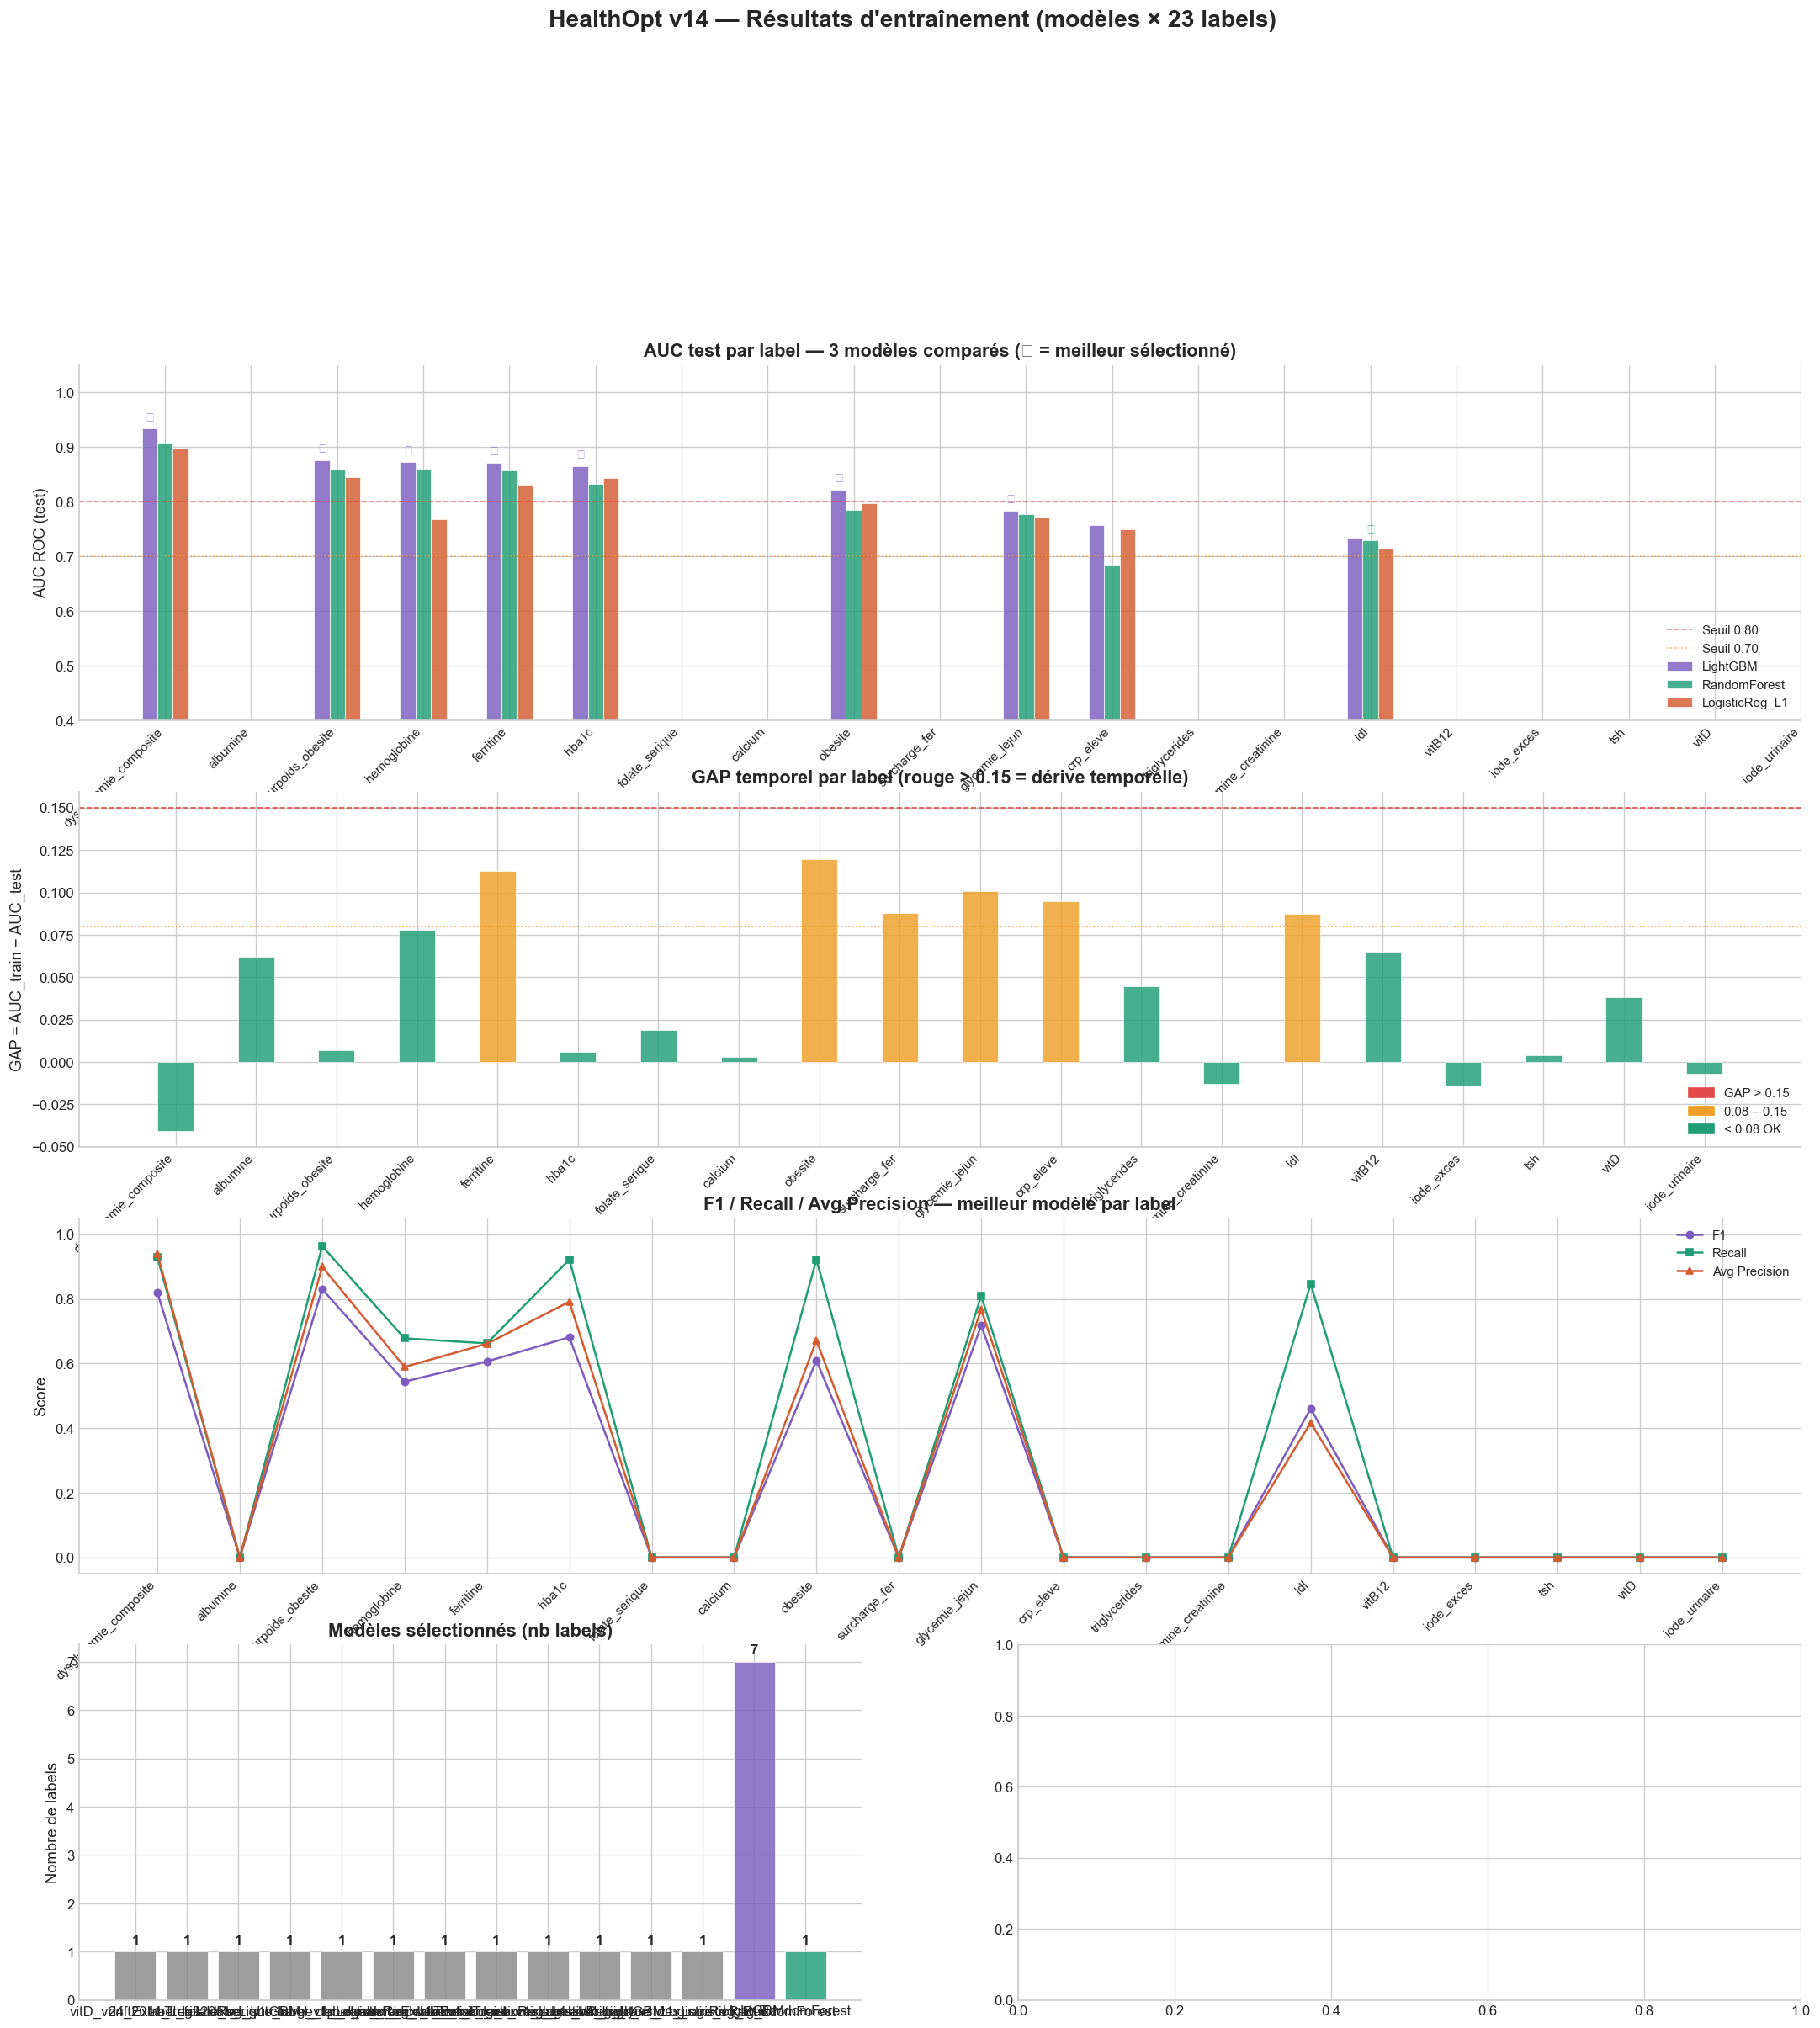

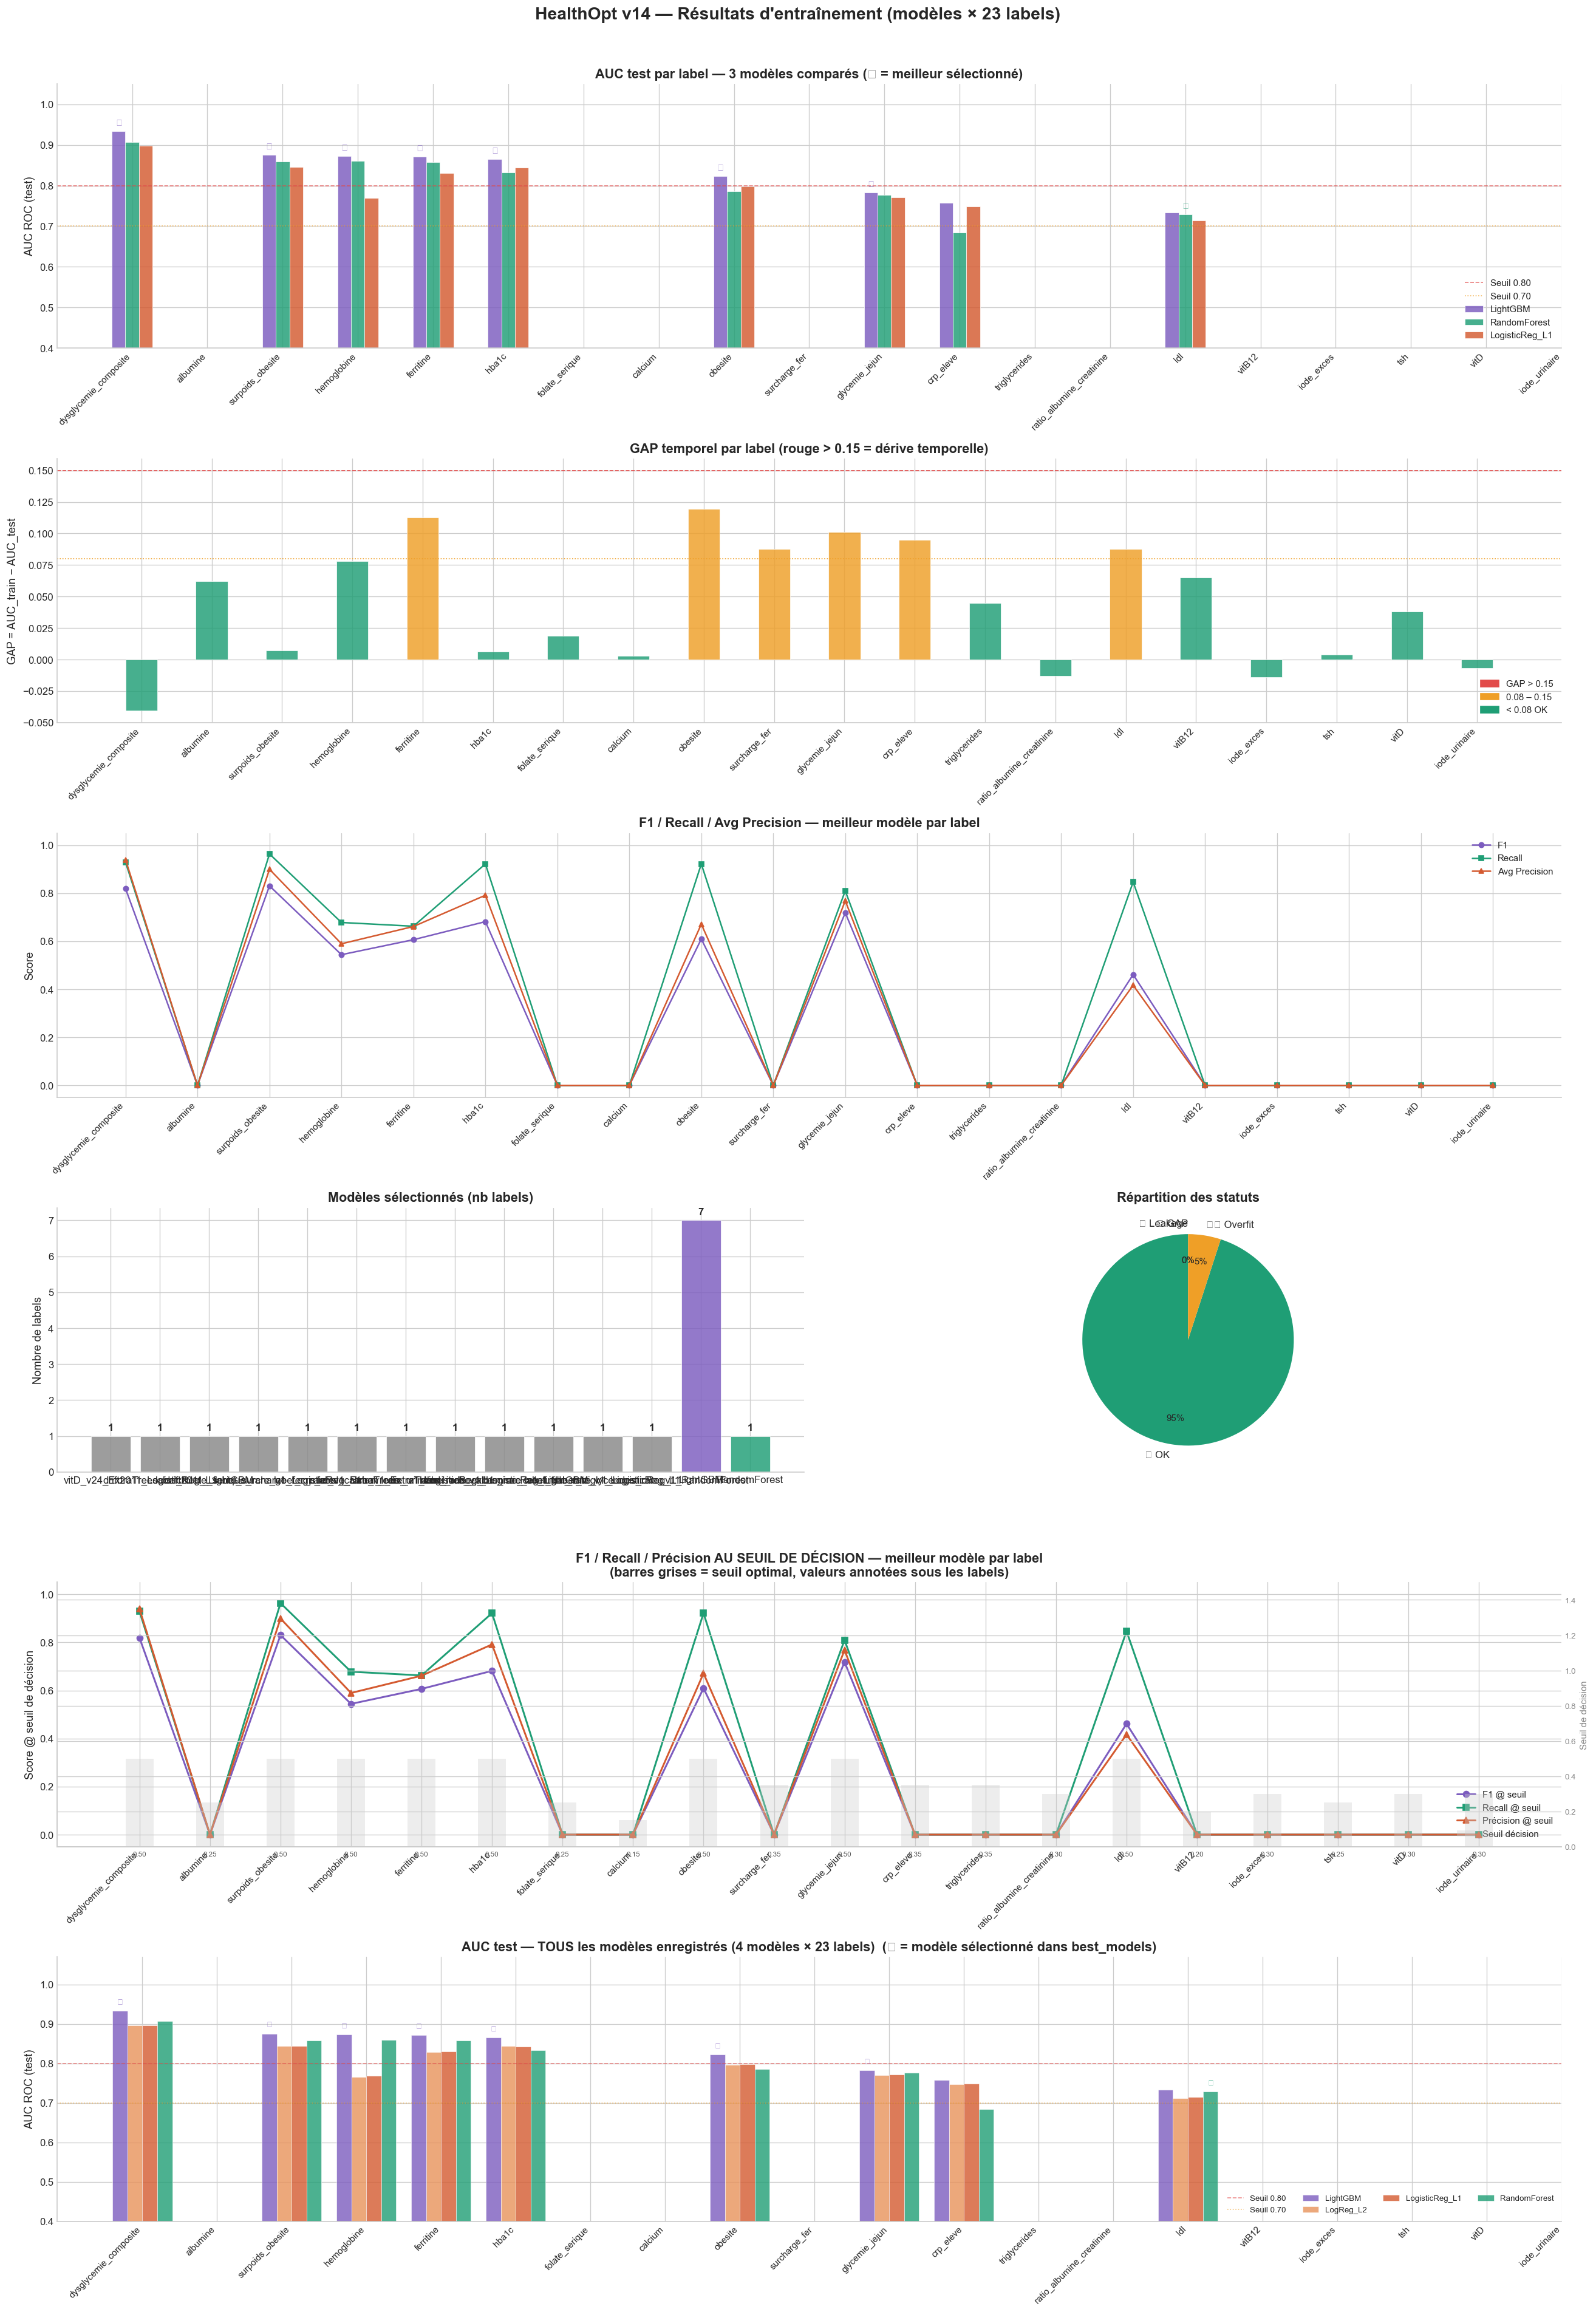

✅ Visualisation sauvegardée dans reports/


In [25]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — VISUALISATION COMPLÈTE DES RÉSULTATS (v14 — étendue)          ║
# ║  À exécuter après la cellule 1                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

PALETTE = {
    "LightGBM":       "#7C5CBF",
    "RandomForest":   "#1F9E75",
    "LogisticReg_L1": "#D45A30",
    "LogReg_L2":      "#E8925A",
    "ExtraTrees":     "#1A6B9E",
}

# ── Détection dynamique de tous les modèles présents dans all_results ─────────
all_model_names = sorted({
    mn
    for lcol in all_results.values()
    for mn in lcol.keys()
    if isinstance(lcol[mn], dict) and "te_auc" in lcol[mn]
})
model_names_ordered = ["LightGBM", "RandomForest", "LogisticReg_L1"]  # subplot 1

labels_sorted = sorted(best_metrics.keys(), key=lambda x: -best_metrics[x]["test_auc"])
x = np.arange(len(labels_sorted))
w = 0.18  # largeur barre réduite pour accueillir plus de modèles

# ── Figure principale : 6 subplots ────────────────────────────────────────────
fig = plt.figure(figsize=(22, 32))
fig.suptitle(
    "HealthOpt v14 — Résultats d'entraînement (modèles × 23 labels)",
    fontsize=17, fontweight="bold", y=0.99
)

# ── Subplot 1 : AUC test par label (3 modèles de référence) ───────────────────
ax1 = fig.add_subplot(6, 1, 1)

for i, mn in enumerate(model_names_ordered):
    aucs = [all_results.get(lc, {}).get(mn, {}).get("te_auc", np.nan)
            for lc in labels_sorted]
    ax1.bar(x + i * w, aucs, w, label=mn,
            color=PALETTE.get(mn, "#888"), alpha=0.82,
            edgecolor="white", linewidth=0.5)

for j, lcol in enumerate(labels_sorted):
    best_mn = best_metrics[lcol]["model"]
    best_te = best_metrics[lcol]["test_auc"]
    if best_mn in model_names_ordered:
        i = model_names_ordered.index(best_mn)
        ax1.text(j + i * w, best_te + 0.01, "★",
                 ha="center", va="bottom", fontsize=9, color=PALETTE.get(best_mn, "#333"))

ax1.axhline(0.8, color="#E24B4A", linestyle="--", linewidth=1, alpha=0.7, label="Seuil 0.80")
ax1.axhline(0.7, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7, label="Seuil 0.70")
ax1.set_xticks(x + w)
ax1.set_xticklabels([l.replace("label_", "") for l in labels_sorted],
                    rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("AUC ROC (test)")
ax1.set_title("AUC test par label — 3 modèles comparés (★ = meilleur sélectionné)",
              fontweight="bold")
ax1.legend(fontsize=9, loc="lower right")
ax1.set_ylim(0.4, 1.05)

# ── Subplot 2 : GAP train-test par label ──────────────────────────────────────
ax2 = fig.add_subplot(6, 1, 2)

gaps = [best_metrics[l].get("train_auc", 0) - best_metrics[l]["test_auc"]
        for l in labels_sorted]
colors_gap = ["#E24B4A" if g > 0.15 else "#EF9F27" if g > 0.08 else "#1F9E75"
              for g in gaps]

ax2.bar(x + w, gaps, 2.5 * w, color=colors_gap, alpha=0.82,
        edgecolor="white", linewidth=0.5)
ax2.axhline(0.15, color="#E24B4A", linestyle="--", linewidth=1)
ax2.axhline(0.08, color="#EF9F27", linestyle=":",  linewidth=1)
ax2.set_xticks(x + w)
ax2.set_xticklabels([l.replace("label_", "") for l in labels_sorted],
                    rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("GAP = AUC_train − AUC_test")
ax2.set_title("GAP temporel par label (rouge > 0.15 = dérive temporelle)",
              fontweight="bold")
patches_gap = [
    mpatches.Patch(color="#E24B4A", label="GAP > 0.15"),
    mpatches.Patch(color="#EF9F27", label="0.08 – 0.15"),
    mpatches.Patch(color="#1F9E75", label="< 0.08 OK"),
]
ax2.legend(handles=patches_gap, fontsize=9)

# ── Subplot 3 : F1 / Recall / Avg Precision (meilleur modèle) ─────────────────
ax3 = fig.add_subplot(6, 1, 3)

f1s   = [best_metrics[l].get("test_f1",     0) for l in labels_sorted]
recs  = [best_metrics[l].get("test_recall", 0) for l in labels_sorted]
precs = [best_metrics[l].get("test_ap",     0) for l in labels_sorted]

ax3.plot(x + w, f1s,   "o-", color="#7C5CBF", linewidth=1.5, markersize=5, label="F1")
ax3.plot(x + w, recs,  "s-", color="#1F9E75", linewidth=1.5, markersize=5, label="Recall")
ax3.plot(x + w, precs, "^-", color="#D45A30", linewidth=1.5, markersize=5, label="Avg Precision")
ax3.set_xticks(x + w)
ax3.set_xticklabels([l.replace("label_", "") for l in labels_sorted],
                    rotation=45, ha="right", fontsize=9)
ax3.set_ylabel("Score")
ax3.set_title("F1 / Recall / Avg Precision — meilleur modèle par label",
              fontweight="bold")
ax3.legend(fontsize=9)
ax3.set_ylim(-0.05, 1.05)

# ── Subplot 4 : Distribution modèles sélectionnés + statuts ───────────────────
ax4 = fig.add_subplot(6, 2, 7)

model_counts = {}
for bm in best_metrics.values():
    mn = bm["model"]
    model_counts[mn] = model_counts.get(mn, 0) + 1

bars4 = ax4.bar(model_counts.keys(), model_counts.values(),
                color=[PALETTE.get(m, "#888") for m in model_counts],
                alpha=0.82, edgecolor="white", linewidth=0.5)
for b, v in zip(bars4, model_counts.values()):
    ax4.text(b.get_x() + b.get_width() / 2, v + 0.1, str(v),
             ha="center", va="bottom", fontweight="bold")
ax4.set_title("Modèles sélectionnés (nb labels)", fontweight="bold")
ax4.set_ylabel("Nombre de labels")

ax5 = fig.add_subplot(6, 2, 8)

statut_counts = {"✅ OK": 0, "⚠️ Overfit": 0, "📉 GAP": 0, "🚨 Leakage": 0}
for bm in best_metrics.values():
    st = bm.get("statut", "OK")
    if   "LEAKAGE" in st: statut_counts["🚨 Leakage"] += 1
    elif "GAP"     in st: statut_counts["📉 GAP"]     += 1
    elif "OVERFIT" in st: statut_counts["⚠️ Overfit"] += 1
    else:                 statut_counts["✅ OK"]       += 1

colors5 = ["#1F9E75", "#EF9F27", "#E24B4A", "#D45A30"]
wedges, texts, autotexts = ax5.pie(
    statut_counts.values(),
    labels=statut_counts.keys(),
    autopct="%1.0f%%",
    colors=colors5,
    startangle=90,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax5.set_title("Répartition des statuts", fontweight="bold")

# ══════════════════════════════════════════════════════════════════════════════
# ── NOUVEAU Subplot 5 : F1 / Recall / Précision AU SEUIL DE DÉCISION ─────────
# ══════════════════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(6, 1, 5)

# Récupère les métriques calculées AU SEUIL optimal enregistré dans best_metrics
f1_seuil    = [best_metrics[l].get("test_f1_at_threshold",    best_metrics[l].get("test_f1",     0)) for l in labels_sorted]
rec_seuil   = [best_metrics[l].get("test_recall_at_threshold", best_metrics[l].get("test_recall", 0)) for l in labels_sorted]
prec_seuil  = [best_metrics[l].get("test_prec_at_threshold",  best_metrics[l].get("test_ap",     0)) for l in labels_sorted]
seuils      = [best_metrics[l].get("seuil_decision", 0.5) for l in labels_sorted]

ax6_twin = ax6.twinx()
ax6_twin.bar(x + w, seuils, 2.2 * w, color="#CCCCCC", alpha=0.35,
             label="Seuil décision", zorder=1)
ax6_twin.set_ylabel("Seuil de décision", fontsize=9, color="#888")
ax6_twin.set_ylim(0, 1.5)
ax6_twin.tick_params(axis="y", labelcolor="#888", labelsize=8)

ax6.plot(x + w, f1_seuil,   "o-", color="#7C5CBF", linewidth=1.8, markersize=6,
         label="F1 @ seuil", zorder=2)
ax6.plot(x + w, rec_seuil,  "s-", color="#1F9E75", linewidth=1.8, markersize=6,
         label="Recall @ seuil", zorder=2)
ax6.plot(x + w, prec_seuil, "^-", color="#D45A30", linewidth=1.8, markersize=6,
         label="Précision @ seuil", zorder=2)

# Annotations des seuils sur chaque label
for j, (lc, s) in enumerate(zip(labels_sorted, seuils)):
    ax6.annotate(f"{s:.2f}", (j + w, -0.07), ha="center", va="top",
                 fontsize=7, color="#555", annotation_clip=False)

ax6.set_xticks(x + w)
ax6.set_xticklabels([l.replace("label_", "") for l in labels_sorted],
                    rotation=45, ha="right", fontsize=9)
ax6.set_ylabel("Score @ seuil de décision")
ax6.set_title(
    "F1 / Recall / Précision AU SEUIL DE DÉCISION — meilleur modèle par label\n"
    "(barres grises = seuil optimal, valeurs annotées sous les labels)",
    fontweight="bold"
)
lines6,  labels6  = ax6.get_legend_handles_labels()
lines6t, labels6t = ax6_twin.get_legend_handles_labels()
ax6.legend(lines6 + lines6t, labels6 + labels6t, fontsize=9, loc="lower right")
ax6.set_ylim(-0.05, 1.05)

# ══════════════════════════════════════════════════════════════════════════════
# ── NOUVEAU Subplot 6 : Comparaison AUC TOUS les modèles enregistrés ──────────
# ══════════════════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(6, 1, 6)

n_models = len(all_model_names)
w_all    = min(0.8 / max(n_models, 1), 0.22)
offsets  = np.linspace(-(n_models - 1) * w_all / 2,
                        (n_models - 1) * w_all / 2,
                        n_models)

for k, mn in enumerate(all_model_names):
    aucs_all = [all_results.get(lc, {}).get(mn, {}).get("te_auc", np.nan)
                for lc in labels_sorted]
    color_mn = PALETTE.get(mn, f"#{hash(mn) & 0xFFFFFF:06X}")
    ax7.bar(x + offsets[k], aucs_all, w_all,
            label=mn, color=color_mn, alpha=0.80,
            edgecolor="white", linewidth=0.4)

# Marqueur du meilleur modèle sélectionné
for j, lcol in enumerate(labels_sorted):
    best_mn  = best_metrics[lcol]["model"]
    best_auc = best_metrics[lcol]["test_auc"]
    if best_mn in all_model_names:
        k = all_model_names.index(best_mn)
        ax7.text(j + offsets[k], best_auc + 0.012, "★",
                 ha="center", va="bottom", fontsize=8,
                 color=PALETTE.get(best_mn, "#333"))

ax7.axhline(0.8, color="#E24B4A", linestyle="--", linewidth=1, alpha=0.6, label="Seuil 0.80")
ax7.axhline(0.7, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.6, label="Seuil 0.70")
ax7.set_xticks(x)
ax7.set_xticklabels([l.replace("label_", "") for l in labels_sorted],
                    rotation=45, ha="right", fontsize=9)
ax7.set_ylabel("AUC ROC (test)")
ax7.set_title(
    f"AUC test — TOUS les modèles enregistrés ({n_models} modèles × 23 labels)  "
    "(★ = modèle sélectionné dans best_models)",
    fontweight="bold"
)
ax7.legend(fontsize=8, loc="lower right", ncol=min(n_models, 4))
ax7.set_ylim(0.4, 1.07)

# ── Sauvegarde ────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(REPORTS_DIR / "resultats_entrainement_v14.pdf"), bbox_inches="tight", dpi=150)
plt.savefig(str(REPORTS_DIR / "resultats_entrainement_v14.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅ Visualisation sauvegardée dans reports/")

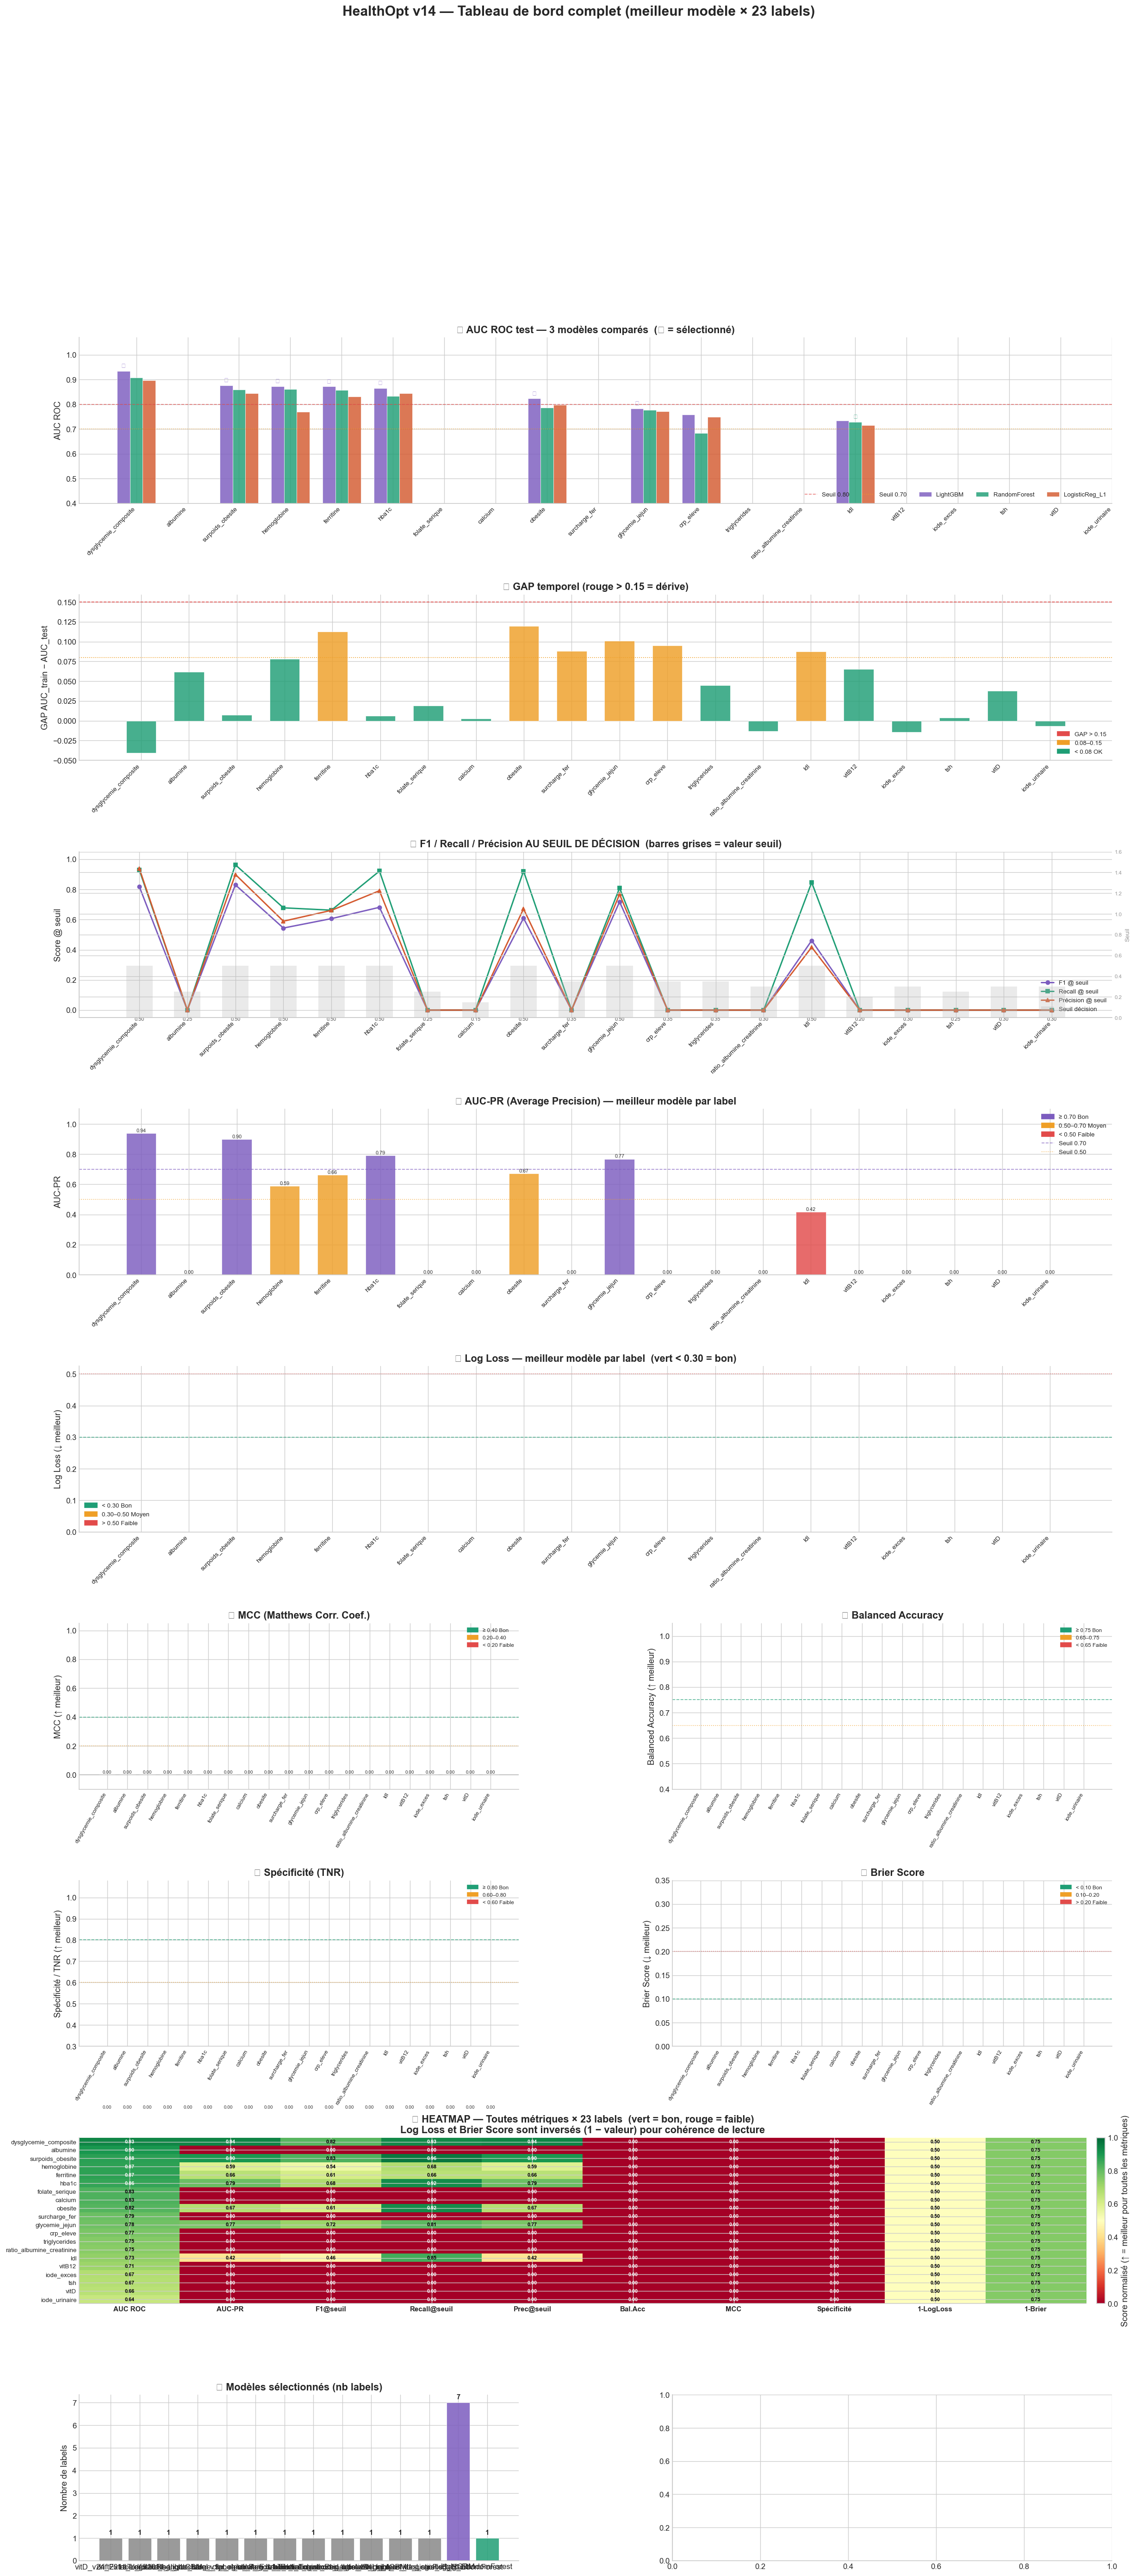

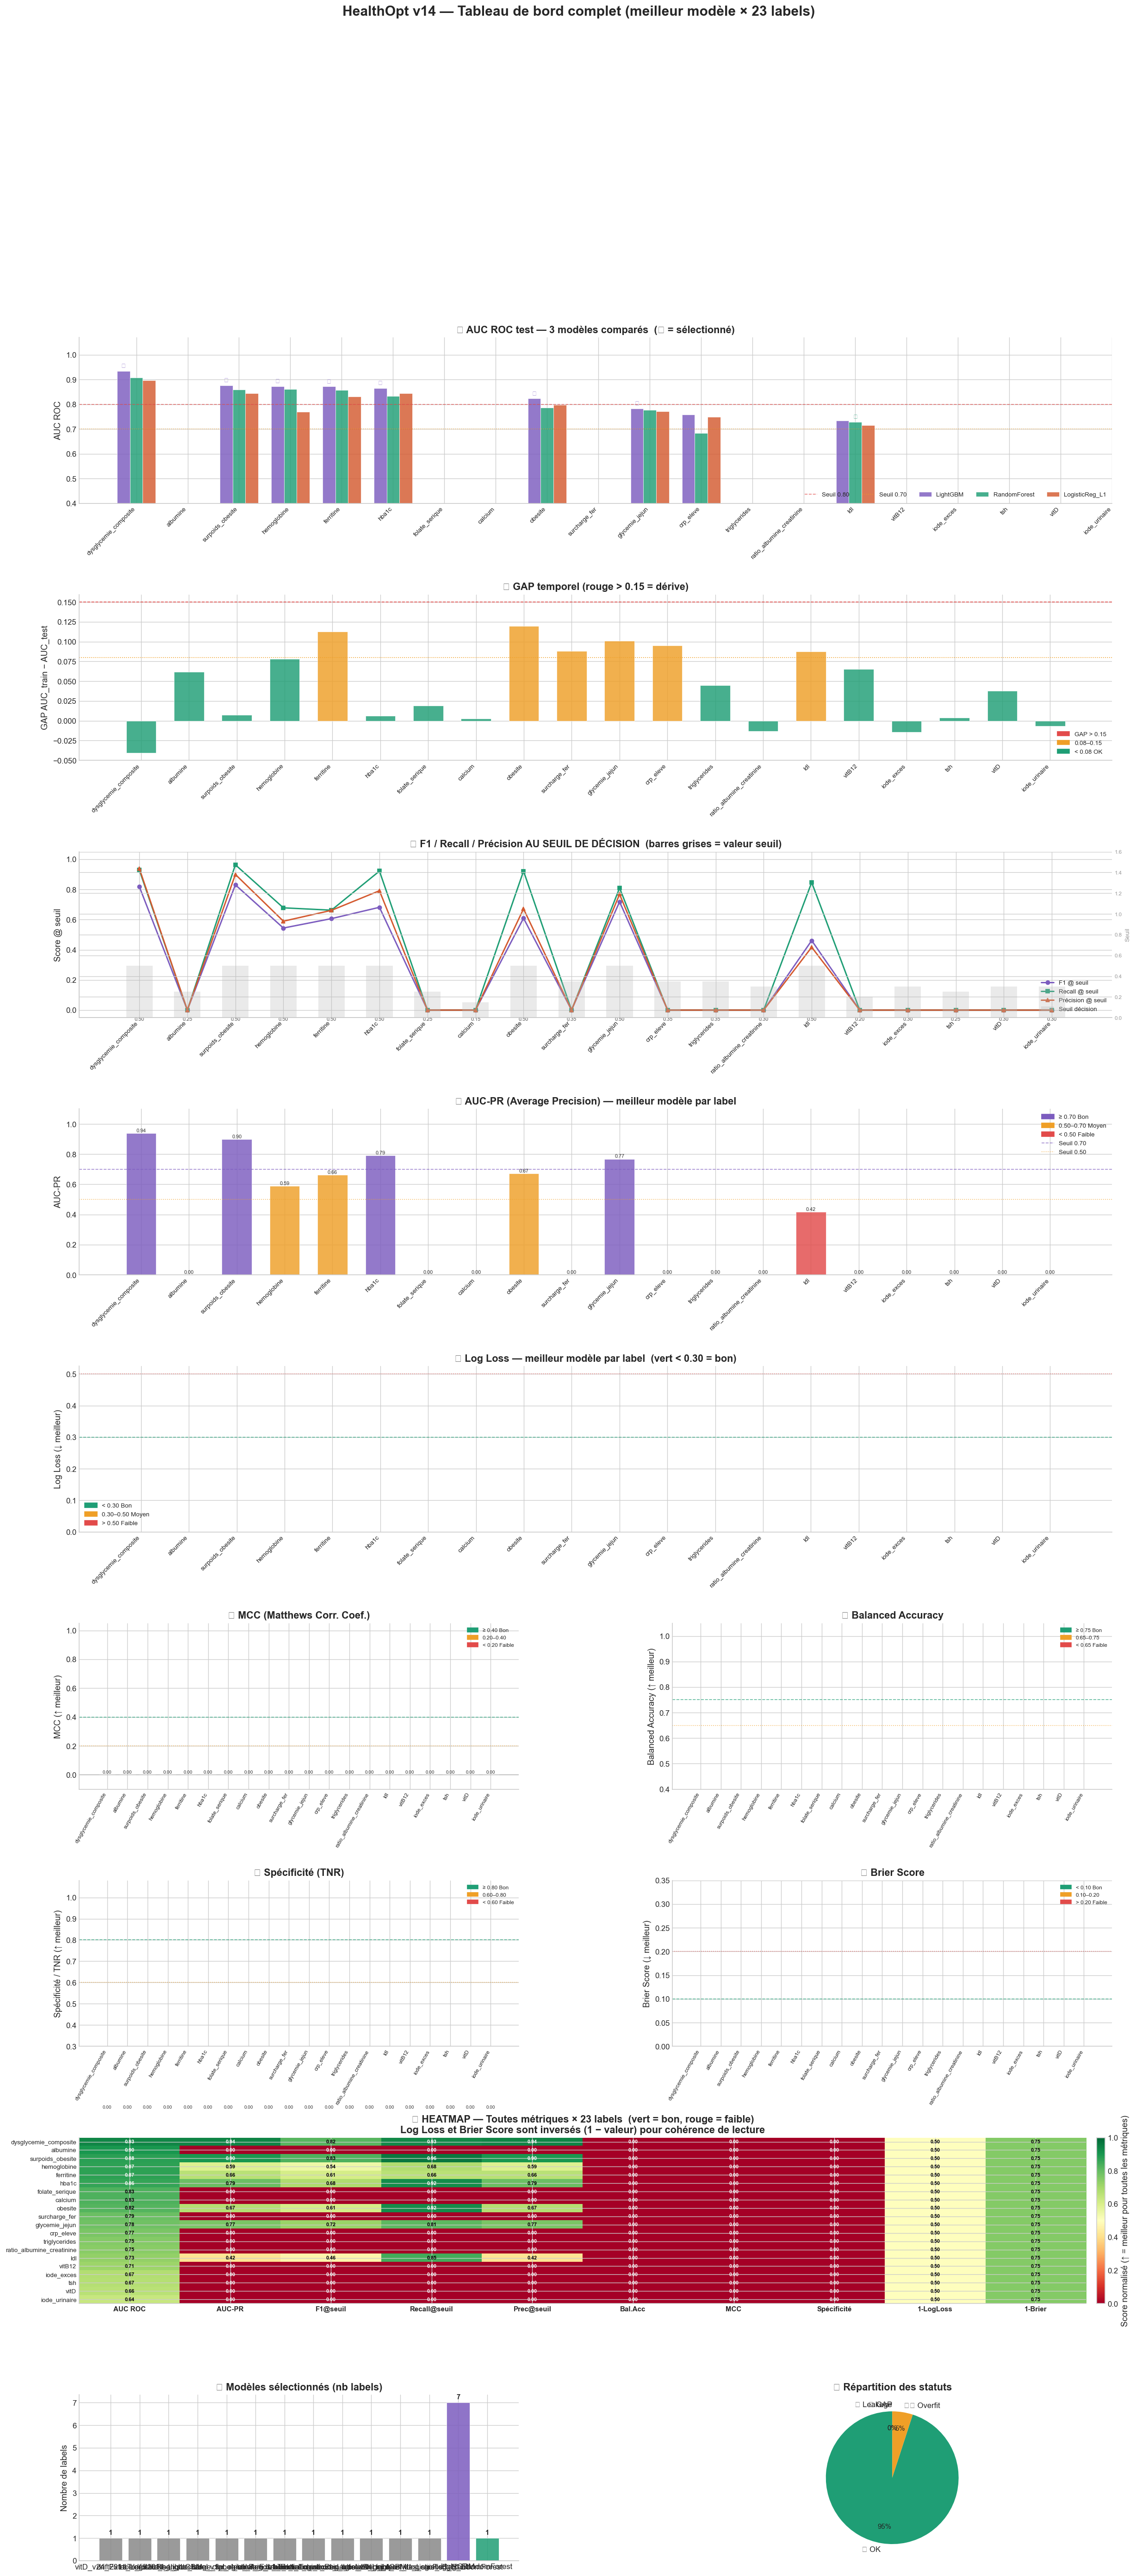

✅ Visualisation complète sauvegardée dans reports/


In [27]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — VISUALISATION COMPLÈTE DES RÉSULTATS (v14 — full metrics)     ║
# ║  À exécuter après la cellule 1                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

PALETTE = {
    "LightGBM":       "#7C5CBF",
    "RandomForest":   "#1F9E75",
    "LogisticReg_L1": "#D45A30",
    "LogReg_L2":      "#E8925A",
    "ExtraTrees":     "#1A6B9E",
}

model_names_ordered = ["LightGBM", "RandomForest", "LogisticReg_L1"]
labels_sorted = sorted(best_metrics.keys(), key=lambda x: -best_metrics[x]["test_auc"])
x = np.arange(len(labels_sorted))
w = 0.25

# ── Détection dynamique de tous les modèles ────────────────────────────────────
all_model_names = sorted({
    mn
    for lcol in all_results.values()
    for mn in lcol.keys()
    if isinstance(lcol[mn], dict) and "te_auc" in lcol[mn]
})

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS — extraction sécurisée des métriques depuis best_metrics
# ══════════════════════════════════════════════════════════════════════════════
def get_metric(label, *keys, default=0.0):
    """Essaie plusieurs noms de clé dans best_metrics[label], retourne default si absent."""
    bm = best_metrics.get(label, {})
    for k in keys:
        if k in bm:
            return bm[k]
    return default

def collect(metric_keys, default=0.0):
    return [get_metric(l, *metric_keys, default=default) for l in labels_sorted]

# ── Vecteurs métriques (meilleur modèle) ──────────────────────────────────────
auc_test   = collect(["test_auc"])
auc_train  = collect(["train_auc"])
auc_pr     = collect(["test_ap", "test_auc_pr", "auc_pr"])
log_loss   = collect(["test_log_loss", "log_loss"], default=np.nan)
mcc        = collect(["test_mcc", "mcc"])
bal_acc    = collect(["test_balanced_acc", "balanced_accuracy", "bal_acc"])
specificity= collect(["test_specificity", "specificity", "tnr"])
brier      = collect(["test_brier", "brier_score"], default=np.nan)
f1s        = collect(["test_f1_at_threshold", "test_f1"])
recs       = collect(["test_recall_at_threshold", "test_recall"])
precs      = collect(["test_prec_at_threshold", "test_ap"])
seuils     = collect(["seuil_decision"], default=0.5)
gaps       = [a_tr - a_te for a_tr, a_te in zip(auc_train, auc_test)]

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — GridSpec : 9 lignes
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 52))
fig.suptitle(
    "HealthOpt v14 — Tableau de bord complet (meilleur modèle × 23 labels)",
    fontsize=18, fontweight="bold", y=0.995
)
gs = GridSpec(9, 2, figure=fig, hspace=0.55, wspace=0.35)

lbl_short = [l.replace("label_", "") for l in labels_sorted]

# ─────────────────────────────────────────────────────────────────────────────
# BLOC A — AUC ROC (3 modèles + meilleur)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for i, mn in enumerate(model_names_ordered):
    aucs = [all_results.get(lc, {}).get(mn, {}).get("te_auc", np.nan) for lc in labels_sorted]
    ax1.bar(x + i * w, aucs, w, label=mn,
            color=PALETTE.get(mn, "#888"), alpha=0.82, edgecolor="white", linewidth=0.5)
for j, lcol in enumerate(labels_sorted):
    best_mn = best_metrics[lcol]["model"]
    best_te = best_metrics[lcol]["test_auc"]
    if best_mn in model_names_ordered:
        i = model_names_ordered.index(best_mn)
        ax1.text(j + i * w, best_te + 0.008, "★",
                 ha="center", va="bottom", fontsize=8, color=PALETTE.get(best_mn, "#333"))
ax1.axhline(0.8, color="#E24B4A", linestyle="--", linewidth=1, alpha=0.7, label="Seuil 0.80")
ax1.axhline(0.7, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7, label="Seuil 0.70")
ax1.set_xticks(x + w); ax1.set_xticklabels(lbl_short, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("AUC ROC"); ax1.set_ylim(0.4, 1.07)
ax1.set_title("① AUC ROC test — 3 modèles comparés  (★ = sélectionné)", fontweight="bold")
ax1.legend(fontsize=8, loc="lower right", ncol=5)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC B — GAP train-test
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
colors_gap = ["#E24B4A" if g > 0.15 else "#EF9F27" if g > 0.08 else "#1F9E75" for g in gaps]
ax2.bar(x + w, gaps, 2.5 * w, color=colors_gap, alpha=0.82, edgecolor="white", linewidth=0.5)
ax2.axhline(0.15, color="#E24B4A", linestyle="--", linewidth=1)
ax2.axhline(0.08, color="#EF9F27", linestyle=":",  linewidth=1)
ax2.set_xticks(x + w); ax2.set_xticklabels(lbl_short, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("GAP AUC_train − AUC_test")
ax2.set_title("② GAP temporel (rouge > 0.15 = dérive)", fontweight="bold")
ax2.legend(handles=[
    mpatches.Patch(color="#E24B4A", label="GAP > 0.15"),
    mpatches.Patch(color="#EF9F27", label="0.08–0.15"),
    mpatches.Patch(color="#1F9E75", label="< 0.08 OK"),
], fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC C — F1 / Recall / Précision AU SEUIL
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
ax3_twin = ax3.twinx()
ax3_twin.bar(x + w, seuils, 2.2 * w, color="#BBBBBB", alpha=0.30, label="Seuil décision", zorder=1)
ax3_twin.set_ylabel("Seuil", fontsize=8, color="#999"); ax3_twin.set_ylim(0, 1.6)
ax3_twin.tick_params(axis="y", labelcolor="#999", labelsize=7)
ax3.plot(x + w, f1s,   "o-", color="#7C5CBF", lw=1.8, ms=5, label="F1 @ seuil",        zorder=2)
ax3.plot(x + w, recs,  "s-", color="#1F9E75", lw=1.8, ms=5, label="Recall @ seuil",    zorder=2)
ax3.plot(x + w, precs, "^-", color="#D45A30", lw=1.8, ms=5, label="Précision @ seuil", zorder=2)
for j, s in enumerate(seuils):
    ax3.annotate(f"{s:.2f}", (j + w, -0.07), ha="center", fontsize=6.5,
                 color="#555", annotation_clip=False)
ax3.set_xticks(x + w); ax3.set_xticklabels(lbl_short, rotation=45, ha="right", fontsize=8)
ax3.set_ylabel("Score @ seuil"); ax3.set_ylim(-0.05, 1.05)
ax3.set_title("③ F1 / Recall / Précision AU SEUIL DE DÉCISION  (barres grises = valeur seuil)",
              fontweight="bold")
lines3, labs3 = ax3.get_legend_handles_labels()
lines3t, labs3t = ax3_twin.get_legend_handles_labels()
ax3.legend(lines3 + lines3t, labs3 + labs3t, fontsize=8, loc="lower right")

# ─────────────────────────────────────────────────────────────────────────────
# BLOC D — AUC PR (Average Precision)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
colors_pr = ["#7C5CBF" if v >= 0.7 else "#EF9F27" if v >= 0.5 else "#E24B4A" for v in auc_pr]
bars4 = ax4.bar(x + w, auc_pr, 2.5 * w, color=colors_pr, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax4.axhline(0.7, color="#7C5CBF", linestyle="--", linewidth=1, alpha=0.7, label="Seuil 0.70")
ax4.axhline(0.5, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7, label="Seuil 0.50")
for b, v in zip(bars4, auc_pr):
    ax4.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.2f}",
             ha="center", fontsize=6.5, color="#333")
ax4.set_xticks(x + w); ax4.set_xticklabels(lbl_short, rotation=45, ha="right", fontsize=8)
ax4.set_ylabel("AUC-PR"); ax4.set_ylim(0, 1.1)
ax4.set_title("④ AUC-PR (Average Precision) — meilleur modèle par label", fontweight="bold")
ax4.legend(handles=[
    mpatches.Patch(color="#7C5CBF", label="≥ 0.70 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.50–0.70 Moyen"),
    mpatches.Patch(color="#E24B4A", label="< 0.50 Faible"),
] + ax4.get_legend_handles_labels()[0], fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC E — Log Loss
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[4, :])
ll_clean = [v if not np.isnan(v) else 0 for v in log_loss]
colors_ll = ["#E24B4A" if v > 0.5 else "#EF9F27" if v > 0.3 else "#1F9E75" for v in ll_clean]
bars5 = ax5.bar(x + w, ll_clean, 2.5 * w, color=colors_ll, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax5.axhline(0.3, color="#1F9E75", linestyle="--", linewidth=1, alpha=0.7, label="Seuil 0.30 (bon)")
ax5.axhline(0.5, color="#E24B4A", linestyle=":",  linewidth=1, alpha=0.7, label="Seuil 0.50 (limite)")
for b, v in zip(bars5, ll_clean):
    if v > 0:
        ax5.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                 ha="center", fontsize=6.5, color="#333")
ax5.set_xticks(x + w); ax5.set_xticklabels(lbl_short, rotation=45, ha="right", fontsize=8)
ax5.set_ylabel("Log Loss (↓ meilleur)")
ax5.set_title("⑤ Log Loss — meilleur modèle par label  (vert < 0.30 = bon)", fontweight="bold")
ax5.legend(handles=[
    mpatches.Patch(color="#1F9E75", label="< 0.30 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.30–0.50 Moyen"),
    mpatches.Patch(color="#E24B4A", label="> 0.50 Faible"),
], fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC F (gauche) — MCC   |   BLOC F (droite) — Balanced Accuracy
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[5, 0])
colors_mcc = ["#1F9E75" if v >= 0.4 else "#EF9F27" if v >= 0.2 else "#E24B4A" for v in mcc]
bars6 = ax6.bar(range(len(labels_sorted)), mcc, color=colors_mcc, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax6.axhline(0.4, color="#1F9E75", linestyle="--", linewidth=1, alpha=0.7)
ax6.axhline(0.2, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7)
ax6.axhline(0.0, color="#888",    linestyle="-",  linewidth=0.8, alpha=0.5)
for b, v in zip(bars6, mcc):
    ax6.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
             ha="center", fontsize=6, color="#333")
ax6.set_xticks(range(len(labels_sorted)))
ax6.set_xticklabels(lbl_short, rotation=60, ha="right", fontsize=7)
ax6.set_ylabel("MCC (↑ meilleur)"); ax6.set_ylim(-0.1, 1.05)
ax6.set_title("⑥ MCC (Matthews Corr. Coef.)", fontweight="bold")
ax6.legend(handles=[
    mpatches.Patch(color="#1F9E75", label="≥ 0.40 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.20–0.40"),
    mpatches.Patch(color="#E24B4A", label="< 0.20 Faible"),
], fontsize=7)

ax7 = fig.add_subplot(gs[5, 1])
colors_ba = ["#1F9E75" if v >= 0.75 else "#EF9F27" if v >= 0.65 else "#E24B4A" for v in bal_acc]
bars7 = ax7.bar(range(len(labels_sorted)), bal_acc, color=colors_ba, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax7.axhline(0.75, color="#1F9E75", linestyle="--", linewidth=1, alpha=0.7)
ax7.axhline(0.65, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7)
for b, v in zip(bars7, bal_acc):
    ax7.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.2f}",
             ha="center", fontsize=6, color="#333")
ax7.set_xticks(range(len(labels_sorted)))
ax7.set_xticklabels(lbl_short, rotation=60, ha="right", fontsize=7)
ax7.set_ylabel("Balanced Accuracy (↑ meilleur)"); ax7.set_ylim(0.4, 1.05)
ax7.set_title("⑦ Balanced Accuracy", fontweight="bold")
ax7.legend(handles=[
    mpatches.Patch(color="#1F9E75", label="≥ 0.75 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.65–0.75"),
    mpatches.Patch(color="#E24B4A", label="< 0.65 Faible"),
], fontsize=7)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC G (gauche) — Spécificité/TNR   |   (droite) — Brier Score
# ─────────────────────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[6, 0])
colors_sp = ["#1F9E75" if v >= 0.8 else "#EF9F27" if v >= 0.6 else "#E24B4A" for v in specificity]
bars8 = ax8.bar(range(len(labels_sorted)), specificity, color=colors_sp, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax8.axhline(0.8, color="#1F9E75", linestyle="--", linewidth=1, alpha=0.7)
ax8.axhline(0.6, color="#EF9F27", linestyle=":",  linewidth=1, alpha=0.7)
for b, v in zip(bars8, specificity):
    ax8.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.2f}",
             ha="center", fontsize=6, color="#333")
ax8.set_xticks(range(len(labels_sorted)))
ax8.set_xticklabels(lbl_short, rotation=60, ha="right", fontsize=7)
ax8.set_ylabel("Spécificité / TNR (↑ meilleur)"); ax8.set_ylim(0.3, 1.08)
ax8.set_title("⑧ Spécificité (TNR)", fontweight="bold")
ax8.legend(handles=[
    mpatches.Patch(color="#1F9E75", label="≥ 0.80 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.60–0.80"),
    mpatches.Patch(color="#E24B4A", label="< 0.60 Faible"),
], fontsize=7)

ax9 = fig.add_subplot(gs[6, 1])
br_clean = [v if not np.isnan(v) else 0 for v in brier]
colors_br = ["#E24B4A" if v > 0.2 else "#EF9F27" if v > 0.1 else "#1F9E75" for v in br_clean]
bars9 = ax9.bar(range(len(labels_sorted)), br_clean, color=colors_br, alpha=0.82,
                edgecolor="white", linewidth=0.5)
ax9.axhline(0.1, color="#1F9E75", linestyle="--", linewidth=1, alpha=0.7)
ax9.axhline(0.2, color="#E24B4A", linestyle=":",  linewidth=1, alpha=0.7)
for b, v in zip(bars9, br_clean):
    if v > 0:
        ax9.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}",
                 ha="center", fontsize=6, color="#333")
ax9.set_xticks(range(len(labels_sorted)))
ax9.set_xticklabels(lbl_short, rotation=60, ha="right", fontsize=7)
ax9.set_ylabel("Brier Score (↓ meilleur)"); ax9.set_ylim(0, 0.35)
ax9.set_title("⑨ Brier Score", fontweight="bold")
ax9.legend(handles=[
    mpatches.Patch(color="#1F9E75", label="< 0.10 Bon"),
    mpatches.Patch(color="#EF9F27", label="0.10–0.20"),
    mpatches.Patch(color="#E24B4A", label="> 0.20 Faible"),
], fontsize=7)

# ─────────────────────────────────────────────────────────────────────────────
# BLOC H — HEATMAP récapitulative (labels × toutes métriques)
# ─────────────────────────────────────────────────────────────────────────────
ax_heat = fig.add_subplot(gs[7, :])

metric_matrix = np.array([
    auc_test, auc_pr, f1s, recs, precs,
    bal_acc, mcc, specificity,
    [1 - v for v in [v if not np.isnan(v) else 0.5 for v in log_loss]],   # inversé : ↑ = bon
    [1 - v for v in [v if not np.isnan(v) else 0.25 for v in brier]],     # inversé : ↑ = bon
]).T  # shape : (n_labels, n_metrics)

metric_labels_heat = [
    "AUC ROC", "AUC-PR", "F1@seuil", "Recall@seuil", "Prec@seuil",
    "Bal.Acc", "MCC", "Spécificité",
    "1-LogLoss", "1-Brier"
]

im = ax_heat.imshow(metric_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax_heat.set_xticks(range(len(metric_labels_heat)))
ax_heat.set_xticklabels(metric_labels_heat, fontsize=9, fontweight="bold")
ax_heat.set_yticks(range(len(labels_sorted)))
ax_heat.set_yticklabels(lbl_short, fontsize=8)
ax_heat.set_title(
    "⑩ HEATMAP — Toutes métriques × 23 labels  (vert = bon, rouge = faible)\n"
    "Log Loss et Brier Score sont inversés (1 − valeur) pour cohérence de lecture",
    fontweight="bold"
)
for i in range(len(labels_sorted)):
    for j in range(len(metric_labels_heat)):
        val = metric_matrix[i, j]
        txt_color = "white" if val < 0.35 or val > 0.85 else "black"
        ax_heat.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=6.5, color=txt_color, fontweight="bold")
plt.colorbar(im, ax=ax_heat, fraction=0.015, pad=0.01,
             label="Score normalisé (↑ = meilleur pour toutes les métriques)")

# ─────────────────────────────────────────────────────────────────────────────
# BLOC I — Répartition modèles + statuts (résumé)
# ─────────────────────────────────────────────────────────────────────────────
ax_pie1 = fig.add_subplot(gs[8, 0])
model_counts = {}
for bm in best_metrics.values():
    mn = bm["model"]
    model_counts[mn] = model_counts.get(mn, 0) + 1
bars_pie = ax_pie1.bar(model_counts.keys(), model_counts.values(),
                       color=[PALETTE.get(m, "#888") for m in model_counts],
                       alpha=0.85, edgecolor="white", linewidth=0.5)
for b, v in zip(bars_pie, model_counts.values()):
    ax_pie1.text(b.get_x() + b.get_width() / 2, v + 0.1, str(v),
                 ha="center", va="bottom", fontweight="bold", fontsize=9)
ax_pie1.set_title("⑪ Modèles sélectionnés (nb labels)", fontweight="bold")
ax_pie1.set_ylabel("Nombre de labels")

ax_pie2 = fig.add_subplot(gs[8, 1])
statut_counts = {"✅ OK": 0, "⚠️ Overfit": 0, "📉 GAP": 0, "🚨 Leakage": 0}
for bm in best_metrics.values():
    st = bm.get("statut","OK")
    if   "LEAKAGE" in st: statut_counts["🚨 Leakage"] += 1
    elif "GAP"     in st: statut_counts["📉 GAP"]     += 1
    elif "OVERFIT" in st: statut_counts["⚠️ Overfit"] += 1
    else:                 statut_counts["✅ OK"]       += 1
wedges, texts, autotexts = ax_pie2.pie(
    statut_counts.values(), labels=statut_counts.keys(),
    autopct="%1.0f%%", colors=["#1F9E75", "#EF9F27", "#E24B4A", "#D45A30"],
    startangle=90, pctdistance=0.75,
)
for t in autotexts: t.set_fontsize(9)
ax_pie2.set_title("⑫ Répartition des statuts", fontweight="bold")

# ── Sauvegarde ────────────────────────────────────────────────────────────────
plt.savefig(str(REPORTS_DIR / "resultats_entrainement_v14.pdf"), bbox_inches="tight", dpi=150)
plt.savefig(str(REPORTS_DIR / "resultats_entrainement_v14.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅ Visualisation complète sauvegardée dans reports/")

---
## S11 — Interface de test QR + Analyse patient


In [29]:
# ── EXEMPLE DE QR CODE VALIDE ──────────────────────────────────────────────
# Le QR doit encoder un JSON avec les noms exacts suivants :
# {
#   "age": 45, "sexe": 1, "imc": 27.5,
#   "hemoglobine": 11.2, "ferritine": 8, "vitD": 32,
#   "vitB12": 180, "folate_serique": 12, "calcium": 2.1,
#   "albumine": 38, "tsh": 3.2, "glycemie_jejun": 5.8,
#   "hba1c": 6.1, "triglycerides": 1.8, "ldl": 3.4
# }
# Générer un QR exemple :
#   import qrcode, json
#   qr = qrcode.make(json.dumps({"age":45,"sexe":1,"imc":27.5,"hemoglobine":11.2,...}))
#   qr.save("exemple_patient.png")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — INTERFACE DE TEST : SCAN QR + ANALYSE + DÉTECTION CARENCE     ║
# ║  À exécuter après la cellule 1 (best_models doit être disponible)           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Dépendances : qrcode[pil], opencv-python-headless, Pillow, ipywidgets
# pip install qrcode[pil] opencv-python-headless Pillow ipywidgets

import cv2
import json
import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from PIL import Image
import io
import base64
# Remplacement de cv2_imshow (Colab) par affichage Jupyter local
def cv2_imshow(img):
    """Affiche une image OpenCV dans Jupyter (remplace google.colab.patches)."""
    from IPython.display import display
    import PIL.Image
    import cv2 as _cv2
    rgb = _cv2.cvtColor(img, _cv2.COLOR_BGR2RGB)
    display(PIL.Image.fromarray(rgb))

# ── Interpréteur clinique des prédictions ─────────────────────────────────────
INTERPRETATIONS = {
    "label_hemoglobine":              ("Anémie", "Hémoglobine basse"),
    "label_ferritine":                ("Carence en fer", "Ferritine basse"),
    "label_vitD":                     ("Carence en vitamine D", "Taux de 25-OH-D insuffisant"),
    "label_vitB12":                   ("Carence en vitamine B12", "Taux de B12 insuffisant"),
    "label_folate_serique":           ("Carence en folate", "Folate sérique bas"),
    "label_calcium":                  ("Anomalie calcique", "Calcémie anormale"),
    "label_iode_urinaire":            ("Carence en iode", "Iodémie urinaire basse"),
    "label_albumine":                 ("Hypoalbuminémie", "Albumine basse"),
    "label_tsh":                      ("Dysthyroïdie", "TSH anormale"),
    "label_glycemie_jejun":           ("Anomalie glycémique", "Glycémie à jeun anormale"),
    "label_hba1c":                    ("Déséquilibre glycémique", "HbA1c élevée"),
    "label_triglycerides":            ("Hypertriglycéridémie", "Triglycérides élevés"),
    "label_ldl":                      ("Hypercholestérolémie", "LDL élevé"),
    "label_ratio_albumine_creatinine":("Atteinte rénale", "Ratio alb/créat élevé"),
    "label_surcharge_fer":            ("Surcharge en fer", "Ferritine très élevée"),
    "label_crp_eleve":                ("Inflammation", "CRP élevée"),
    "label_dysglycemie_composite":    ("Dysglycémie composite", "Signe prédiabète"),
    "label_surpoids_obesite":         ("Surpoids / Obésité", "IMC ≥ 25"),
    "label_obesite":                  ("Obésité", "IMC ≥ 30"),
    "label_iode_exces":               ("Excès d'iode", "Iodémie urinaire élevée"),
}

RECOMMANDATIONS = {
    "label_ferritine":      "Supplémenter en fer + aliments riches (viande rouge, légumineuses)",
    "label_vitD":           "Supplémenter en vitamine D3 + exposer au soleil 15 min/j",
    "label_vitB12":         "Supplémenter en B12 (méthylcobalamine) + œufs, produits laitiers",
    "label_calcium":        "Vérifier la prise de calcium, consultation endocrinologue",
    "label_hemoglobine":    "Bilan martial complet, consultation hématologue",
    "label_iode_urinaire":  "Augmenter les apports en iode (sel iodé, produits de mer)",
    "label_albumine":       "Évaluer l'état nutritionnel global, consultation diététicien",
    "label_tsh":            "Consultation endocrinologue pour bilan thyroïdien complet",
    "label_glycemie_jejun": "Contrôle glycémique, consultation diabétologue",
    "label_ldl":            "Régime pauvre en graisses saturées, bilan cardiovasculaire",
}


def decoder_qr_depuis_image(image_np: np.ndarray) -> dict | None:
    """
    Décode un QR code contenant un JSON d'analyse biologique.
    Retourne le dict JSON ou None si échec.

    Format QR attendu (exemple) :
    {
      "age": 45, "sexe": 1, "imc": 27.5, "hemoglobine": 11.2,
      "ferritine": 8, "vitD": 32, "vitB12": 180, ...
    }
    """
    detector = cv2.QRCodeDetector()
    data, bbox, _ = detector.detectAndDecode(image_np)
    if data:
        try:
            return json.loads(data)
        except json.JSONDecodeError:
            # Le QR peut contenir du texte plat clé:valeur
            result = {}
            for line in data.strip().split("\n"):
                if ":" in line:
                    k, v = line.split(":", 1)
                    try:    result[k.strip()] = float(v.strip())
                    except: result[k.strip()] = v.strip()
            return result if result else None
    return None


def preparer_features_patient(patient_data: dict, feature_cols: list,
                               imputer_medians: dict) -> pd.DataFrame:
    """
    Construit un DataFrame 1 ligne avec les features attendues par le modèle.
    Les valeurs manquantes sont remplies par la médiane du train.
    """
    row = {}
    for col in feature_cols:
        val = patient_data.get(col, np.nan)
        if pd.isna(val):
            val = imputer_medians.get(col, np.nan)
        row[col] = val
    return pd.DataFrame([row])


def analyser_patient(patient_data: dict, seuil_alarme: float = 0.5) -> dict:
    """
    Lance tous les modèles disponibles sur les données patient.

    Returns:
        dict avec les clés :
          - carences_detectees : liste des labels positifs
          - scores : {label: probabilité}
          - resume_clinique : texte humain
          - alertes : labels au-dessus du seuil d'alarme
    """
    if not best_models:
        return {"erreur": "best_models vide — exécuter la cellule 1 d'abord"}

    scores            = {}
    carences_detectees= []
    alertes           = []

    for label_col, model in best_models.items():
        # Récupérer les feature_cols sauvegardées en cellule 1
        feature_cols = best_metrics.get(label_col, {}).get("feature_cols", [])
        seuil_dec    = best_metrics.get(label_col, {}).get("seuil_decision", 0.5)

        if not feature_cols:
            continue

        # Médiane des features depuis df_train_fe (imputation)
        medians = {}
        if "df_train_fe" in dir() and df_train_fe is not None:
            for col in feature_cols:
                if col in df_train_fe.columns:
                    medians[col] = float(df_train_fe[col].median())

        try:
            X_patient = preparer_features_patient(patient_data, feature_cols, medians)
            proba     = float(model.predict_proba(X_patient)[0, 1])
            positif   = proba >= seuil_dec
            scores[label_col] = round(proba, 3)
            if positif:
                carences_detectees.append(label_col)
            if proba >= seuil_alarme:
                alertes.append((label_col, proba))
        except Exception as e:
            scores[label_col] = f"erreur: {e}"

    alertes.sort(key=lambda x: -x[1])

    # Résumé clinique en texte
    if not carences_detectees:
        resume = "✅ Aucune anomalie détectée dans les paramètres analysés."
    else:
        lignes = [f"⚠️  {len(carences_detectees)} anomalie(s) détectée(s) :"]
        for lbl in carences_detectees:
            nom, desc = INTERPRETATIONS.get(lbl, (lbl, ""))
            proba     = scores.get(lbl, "?")
            rec       = RECOMMANDATIONS.get(lbl, "Consulter un professionnel de santé")
            lignes.append(f"   • {nom} ({desc}) — prob: {proba:.0%}")
            lignes.append(f"     → {rec}")
        resume = "\n".join(lignes)

    return {
        "carences_detectees": carences_detectees,
        "scores":             scores,
        "alertes":            alertes,
        "resume_clinique":    resume,
    }


# ── INTERFACE IPYWIDGETS ───────────────────────────────────────────────────────

def creer_interface_test():
    """Lance l'interface interactive de test avec scan QR."""

    titre = widgets.HTML(
        "<h2 style='color:#1F3A5F;font-family:sans-serif;margin-bottom:4px'>"
        "🧬 HealthOpt — Analyse d'analyse biologique</h2>"
        "<p style='color:#666;font-family:sans-serif;margin:0'>"
        "Scannez un QR code ou entrez les valeurs manuellement</p>"
        "<hr style='border:0.5px solid #ddd'>"
    )

    # ── Onglet 1 : Scan QR ──────────────────────────────────────────────────
    upload_widget = widgets.FileUpload(
        accept="image/*", multiple=False,
        description="📷 Image QR",
        layout=widgets.Layout(width="250px"),
    )
    btn_scan = widgets.Button(
        description="Décoder le QR code",
        button_style="primary",
        icon="search",
        layout=widgets.Layout(width="200px", margin="8px 0"),
    )
    out_qr = widgets.Output()

    def on_scan(_):
        out_qr.clear_output()
        with out_qr:
            if not upload_widget.value:
                print("⚠️  Veuillez d'abord charger une image.")
                return
            # Décoder l'image
            content = upload_widget.value[0]["content"]

            img_pil = Image.open(io.BytesIO(content)).convert("RGB")
            img_np  = np.array(img_pil)
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            # Afficher l'image
            print("📷 Image chargée :")
            cv2_imshow(img_bgr)

            patient_data = decoder_qr_depuis_image(img_bgr)
            if patient_data is None:
                print("❌ QR code non détecté ou format invalide.")
                print("   → Assurez-vous que le QR contient un JSON valide.")
                return

            print(f"\n✅ QR décodé — {len(patient_data)} paramètres trouvés")
            print("   Données :", json.dumps(patient_data, ensure_ascii=False, indent=2)[:300])

            # Analyse
            print("\n🔬 Analyse en cours...")
            resultats = analyser_patient(patient_data)
            afficher_resultats(resultats)

    btn_scan.on_click(on_scan)

    onglet_qr = widgets.VBox([
        widgets.HTML("<b>Étape 1 :</b> Charger l'image contenant le QR code"),
        upload_widget,
        btn_scan,
        out_qr,
    ])

    # ── Onglet 2 : Saisie manuelle ──────────────────────────────────────────
    champs_manuels = {
        "age":             ("Âge (années)",           0, 120, 45, 1),
        "sexe":            ("Sexe (0=H, 1=F)",         0, 1,   0, 1),
        "imc":             ("IMC (kg/m²)",             10, 60, 25, 0.1),
        "hemoglobine":     ("Hémoglobine (g/dL)",       3, 25, 13, 0.1),
        "ferritine":       ("Ferritine (µg/L)",         1, 500, 60, 1),
        "vitD":            ("Vitamine D (nmol/L)",      5, 250, 55, 1),
        "vitB12":          ("Vitamine B12 (pmol/L)",   50,3000,300, 1),
        "folate_serique":  ("Folate sérique (nmol/L)", 0.5,100,20, 0.5),
        "calcium":         ("Calcium (mmol/L)",         1, 14, 2.3, 0.01),
        "albumine":        ("Albumine (g/L)",           10, 60, 42, 0.5),
        "tsh":             ("TSH (mU/L)",              0.01,50,2, 0.01),
        "glycemie_jejun":  ("Glycémie jeun (mmol/L)", 2, 30, 5.5, 0.1),
        "hba1c":           ("HbA1c (%)",               4, 15, 5.5, 0.1),
        "triglycerides":   ("Triglycérides (mmol/L)", 0.2, 25, 1.2, 0.1),
        "ldl":             ("LDL (mmol/L)",             1, 10, 2.8, 0.1),
    }

    sliders = {}
    for key, (label, vmin, vmax, vdef, step) in champs_manuels.items():
        sl = widgets.FloatSlider(
            value=vdef, min=vmin, max=vmax, step=step,
            description=label, continuous_update=False,
            style={"description_width": "220px"},
            layout=widgets.Layout(width="500px"),
        )
        sliders[key] = sl

    seuil_slider = widgets.FloatSlider(
        value=0.5, min=0.1, max=0.9, step=0.05,
        description="Seuil d'alarme :",
        style={"description_width": "150px"},
        layout=widgets.Layout(width="400px"),
    )

    btn_analyser = widgets.Button(
        description="Analyser le patient",
        button_style="success",
        icon="check",
        layout=widgets.Layout(width="220px", margin="12px 0"),
    )
    out_manuel = widgets.Output()

    def on_analyser(_):
        out_manuel.clear_output()
        with out_manuel:
            patient_data = {k: v.value for k, v in sliders.items()}
            print(f"🔬 Analyse en cours (seuil alarme = {seuil_slider.value:.2f})...")
            resultats = analyser_patient(patient_data, seuil_slider.value)
            afficher_resultats(resultats)

    btn_analyser.on_click(on_analyser)

    onglet_manuel = widgets.VBox([
        widgets.HTML("<b>Renseignez les valeurs biologiques du patient :</b>"),
        *sliders.values(),
        seuil_slider,
        btn_analyser,
        out_manuel,
    ])

    # ── Affichage résultats ─────────────────────────────────────────────────
    def afficher_resultats(resultats: dict):
        if "erreur" in resultats:
            print(f"❌ {resultats['erreur']}")
            return

        carences = resultats["carences_detectees"]
        scores   = resultats["scores"]
        alertes  = resultats["alertes"]
        resume   = resultats["resume_clinique"]

        print("\n" + "=" * 60)
        print("  📋 RÉSULTATS D'ANALYSE")
        print("=" * 60)
        print(resume)

        if alertes:
            print(f"\n  🔴 ALERTES PRIORITAIRES ({len(alertes)}) :")
            for lbl, proba in alertes[:5]:
                nom, _ = INTERPRETATIONS.get(lbl, (lbl, ""))
                print(f"     • {nom} — {proba:.1%}")

        print(f"\n  📊 Scores complets ({len(scores)} labels) :")
        print(f"  {'Label':<45} {'Probabilité':>12}  Statut")
        print(f"  {'─'*65}")
        for lbl, score in sorted(scores.items(), key=lambda x: -x[1] if isinstance(x[1], float) else 0):
            if isinstance(score, float):
                nom, _ = INTERPRETATIONS.get(lbl, (lbl, ""))
                seuil  = best_metrics.get(lbl, {}).get("seuil_decision", 0.5)
                icon   = "🔴" if score >= seuil else "🟢"
                print(f"  {nom:<45} {score:>11.1%}  {icon}")
            else:
                print(f"  {lbl:<45} {str(score):>12}")

        print("\n" + "=" * 60)
        print(f"  Modèles utilisés : {len(best_models)} labels")
        print("=" * 60)

    # ── Onglets finaux ──────────────────────────────────────────────────────
    tabs = widgets.Tab()
    tabs.children = [onglet_qr, onglet_manuel]
    tabs.set_title(0, "📷 Scan QR code")
    tabs.set_title(1, "✏️  Saisie manuelle")

    display(widgets.VBox([titre, tabs]))


# ── LANCER L'INTERFACE ─────────────────────────────────────────────────────────
creer_interface_test()